<a href="https://colab.research.google.com/github/Knerdy-got-moves/Many-body-dynamics-in-Floquet-driven-systems/blob/main/Optimised_Autocorrelation_in_large_system_sizes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kicked interaction-longitudinal and static transverse field Ising chain under open boundary conditions

**MODEL:**

Consider a one-dimensional longitudinal and transverse field  Ising chain as a Floquet-driven system of length $L$ with open boundary conditions that uses Pauli operators $\sigma_i^{x,y,z}$ and is subject to a weak static transverse perturbation, with both couplings following the same symmetric square-wave drive of period $T$:
$$
H(t)=H_0(t)+H_1, \quad
H_0(t)=-J(t)\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z\;-\;h(t)\sum_{i=1}^{L}\sigma_i^z, \quad
H_1=-g\sum_{i=1}^{L}\sigma_i^x,\;\;|g|\ll \{|J_0|,|h_0|\}.
$$

\begin{equation}
J(t)=\begin{cases} +J_0,& 0\le t\le T/2,\\ -J_0,& T/2<t\le T,\end{cases}
\qquad
h(t)=\begin{cases} +h_0,& 0\le t\le T/2,\\ -h_0,& T/2<t\le T.\end{cases}
\end{equation}  

The Floquet Hamiltonian, $H_F$ is defined in terms of the Floquet unitary (time evolution operator for the Hamiltonian, $H(t)$ over one complete period) as: $$U(T,0)=e^{-\,\frac{i}{\hbar}H_F T}$$
The Floquet Hamiltonian is like the effective Hamiltonian. Our first-order (in $g$) Floquet Hamiltonian which is calculated from Floquet perturbation theory is given by:
$$(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\left(\delta_{P_{nm},0}+(1-\delta_{P_{nm},0})
\operatorname{sinc}\!\Big(\frac{P_{nm}T}{4\hbar}\Big)e^{-\,\tfrac{i}{\hbar}P_{nm}\tfrac{T}{4}}\right)$$

where, the first-order Floquet Hamiltonian is in the eigenbasis of $\mathcal{O}=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z
+h_0\sum_{i=1}^{L}\sigma_i^z,$ where, $\mathcal{O}|m\rangle=P_m|m\rangle$ and $P_{nm}=P_n-P_m.$ At $T=2 \pi/J_0$, the effective first-order Floquet Hamiltonian becomes:
$$
H^{(1)}_{F} =-g\sum_{i=2}^{L-1}\pi_{i-1}\sigma_i^x\pi_{i+1}
, \qquad \pi_i = \frac{\mathbb{I} - \sigma_i^z}{2}.
$$
This shows we have a prethermal edge memory, as we don't have any terms in the first-order Floquet Hamiltonian corresponding to the edge flips.

**METHODOLOGY:**

We write a Python code to plot the infinite temperature autocorrelation function (in other words we start with random initial states, $| \psi_0 \rangle$ ) with respect to time, $$C_j(nT) = \langle \psi_0 | [\sigma^z_j(nT) ][\sigma^z_j(0) ] | \psi_0 \rangle $$ using exact diagonalization for $j\in\{1,2,3\cdots L\}$.

We then perform the fragmentation analysis on the Floquet Hamiltonian which we got using Floquet perturbation theory. We do this numerically, creating graphs and exploring the connected components. If we order the basis by grouping the connected components from the largest component to the smallest, we get a block diagonal Hamiltonian in this basis, starting with the largest block to smallest block.


We then explore the memory retention seen in the autocorrelation at the edges, 0 and L sites at particular driving time periods. We create a contour plot for the magnetization to see the constant magnetisation at the edges with respect to time/floquet steps.  

We then turned towards exploring symmetry protected topological phases (SPT), however there is no symmetry global or local that protects the  edge modes. The global symmetries are inversion symmetry:
the reflection $I$ is defined by:

$$
I\,\sigma_i^{x,y,z}\,I^{-1} = \sigma_{L+1-i}^{x,y,z}.
$$
Then each term in $H_{F}$ maps to the corresponding term on the reflected site, so
$$
I\,H_{F}\,I^{-1} = H_{F},
$$
and the Chiral symmetry:
define,
$$
\Gamma = \prod_{j=1}^L \sigma_j^z.
$$
we observe:
1. $\Gamma$ commutes with any function of $\sigma_i^z$, hence with every projector $\pi_i$.
2. On site $i$, $\sigma_i^z \sigma_i^x \sigma_i^z = -\sigma_i^x$, and $\sigma_j^z$ for $j \neq i$ commutes with $\sigma_i^x$. Hence $
   \Gamma \sigma_i^x \Gamma^{-1} = -\sigma_i^x.
   $

Therefore, each term flips sign:
$$
\Gamma (\pi_{i-1} \sigma_i^x \pi_{i+1}) \Gamma^{-1}
= \pi_{i-1} (\Gamma \sigma_i^x \Gamma^{-1}) \pi_{i+1}
= -\pi_{i-1} \sigma_i^x \pi_{i+1}.
$$
Summing over $i$,
$$
\Gamma H^{(1)}_{F} \Gamma^{-1} = -H^{(1)}_{F}
\quad \Leftrightarrow \quad
\{\Gamma, H^{(1)}_{F}\} = 0.
$$



If you look for a genuine on-site symmetry $G = \bigotimes_i g_i$ with $[G, H^{(1)}_{F}] = 0$, the constraint structure almost kills everything; each term contains projectors $\pi_{i \pm 1}$ (functions of $\sigma_{i\pm 1}^z$) and $\sigma_i^x$. To commute with all $\pi$'s, $g_i$ must commute with $\sigma_i^z$ implies,$ g_i$ must be diagonal in the $\sigma^z$ basis. But then to commute with $\sigma_i^x$, a diagonal $g_i$ must be proportional to identity. So there is no nontrivial on-site commuting symmetry group $G$ to protect a 1D bosonic SPT phase in the usual sense.  

If the edge was symmetry protected, we can not kill the edges with a small perturbation that preserves these symmetries. Here we can, take $ V \equiv \varepsilon (\sigma_1^x \pi_2 + \pi_{L-1} \sigma_L^x), \quad 0 < |\varepsilon| \ll |g|.  $

We plot the autocorrelation at the edges for different system sizes, L and their decay Floquet step, N (autocorrelation dies to zero at this step number) to find if there is any system size dependence on the edge memory conservation. We concluded there is  no relation.


**SECTIONS:**

This colab file is divided into four parts

1.   We use the SciPy and NumPy library for writing the Hamiltonian in the site fock state basis. For observing the first instance of violation of Eigenstate thermalization hypothesis (ETH), sample values of potentials are $J_0=10$, $h_0=20$,  $g=1$ and the driving time period is $T=2\pi/(J_0)$ for a given site in the bulk ([L/2]). We plot the Autocorrelation with different values of potential for $g=1$ at $T=2\pi/(J_0)$ and a bulk site; with different values of time periods at the edges and bulk with $J_0=10$, $h_0=2J_0=20$,  $g=1$; at different sites with $J_0=10$, $h_0=2J_0=20$,  $g=1$ and at $T=\pi/(J_0)$ and $T=2\pi/(J_0)$. We also see the edge memory preservation for different systems sizes, L.

2.  We plot autocorrelation for different chain lengths, and observe the dependence of lifetime of prethermal ergodicity with different chain lengths, $L$.

3.  The violation of Eigenstate thermalisation hypothesis is further classified as Hilbert space fragmentation by finding the connected components of the states.

4.   We explore additional memory retension at the edges at $T=2 \pi/(J_0)$ driving, and we establish that by plotting magnetisation with time.








# Autocorrelation and time period dependent memory preservation

Through finite saturation value of infinite temperature autocorrelation, we show that the system doesn't thermalise at "long" times~500 Floquet steps at driving $J_0\ge 4$ at certain driving frequencies.

Other publised references:

Somsubhra Ghosh, Indranil Paul, and K. Sengupta, "Prethermal Fragmentation in a Periodically Driven Fermionic Chain," Phys. Rev. Lett. 130, 120401 (2023). doi: [10.1103/PhysRevLett.130.120401](https://doi.org/10.1103/PhysRevLett.130.120401).

## Hamiltonian

We construct the Ising model Hamiltonian.

In [17]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator


# ============================================================
# STANDALONE HAMILTONIAN BUILDER
# ============================================================

def build_H_floquet(L, J0, h0, g, which):
    """
    Construct a Floquet half-period Hamiltonian for the open Ising chain.

    Parameters
    ----------
    L : int
        Chain length (number of sites).  Must be >= 2.
    J0 : float
        Ising nearest-neighbour coupling amplitude.
    h0 : float
        Longitudinal field amplitude.
    g : float
        Transverse field strength.
    which : {"plus", "minus"}
        Selects the half-period Hamiltonian.

    Returns
    -------
    H : scipy.sparse.csr_matrix, shape (N, N), dtype np.float64
        The Hamiltonian in CSR canonical form (sorted column indices,
        no duplicates).  Each row has exactly (L + 1) stored entries
        (1 diagonal + L off-diagonal sigma^x flips).
        Total nnz = N * (L + 1), where N = 2^L.

    Raises
    ------
    ValueError
        If L < 2 or ``which`` is invalid.

    Complexity
    ----------
    Time  :  O(N * L * log L)   [log L from per-row column sort]
    Memory:  O(N * L)           [CSR storage plus temporaries]

    Notes
    -----
    The ZZ product is evaluated as
        z_i(s) * z_{i+1}(s) = 1 - 2 * (c_i XOR c_{i+1}),
    which avoids separate extraction of c_i and c_{i+1}.

    The L+1 column indices per row are provably distinct, so no
    ``sum_duplicates`` call is needed.
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")
    if which not in ("plus", "minus"):
        raise ValueError(f"which must be 'plus' or 'minus', got '{which}'")

    N = 1 << L

    if which == "plus":
        signJ, signh = -1.0, -1.0
    else:
        signJ, signh = +1.0, +1.0

    states = np.arange(N, dtype=np.int64)

    # ---- Diagonal: ZZ + Z contributions ----
    diag = np.zeros(N, dtype=np.float64)

    coeff_zz = signJ * J0
    for i in range(L - 1):
        pi  = L - 1 - i
        pi1 = L - 2 - i
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += coeff_zz * (1.0 - 2.0 * xor_bit.astype(np.float64))

    coeff_z = signh * h0
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag += coeff_z * (1.0 - 2.0 * ci.astype(np.float64))

    # ---- Build (column, value) arrays, shape (N, L+1) ----
    all_cols = np.empty((N, L + 1), dtype=np.int64)
    all_vals = np.empty((N, L + 1), dtype=np.float64)

    all_cols[:, 0] = states
    all_vals[:, 0] = diag

    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        all_cols[:, 1 + i] = states ^ flip_mask
        all_vals[:, 1 + i] = -g

    # ---- Sort columns within each row (CSR canonical form) ----
    sort_idx = np.argsort(all_cols, axis=1, kind='stable')
    all_cols = np.take_along_axis(all_cols, sort_idx, axis=1)
    all_vals = np.take_along_axis(all_vals, sort_idx, axis=1)

    # ---- Assemble CSR matrix ----
    indptr  = np.arange(N + 1, dtype=np.int64) * (L + 1)
    indices = all_cols.ravel()
    data    = all_vals.ravel()

    H = csr_matrix((data, indices, indptr), shape=(N, N))
    H.has_sorted_indices = True

    return H


# ============================================================
# LIGHTWEIGHT BASIS DESCRIPTOR
# ============================================================

class _BasisInfo:
    """
    Provides the two attributes accessed by downstream code:
        .Ns     -- Hilbert space dimension  (int)
        .states -- basis state integers in ascending order  (ndarray int64)
    """
    __slots__ = ('L', 'Ns', 'states')

    def __init__(self, L):
        self.L = L
        self.Ns = 1 << L
        self.states = np.arange(1 << L, dtype=np.int64)

    def __repr__(self):
        return f"_BasisInfo(L={self.L}, Ns={self.Ns})"


# ============================================================
# OOP INTERFACE
# ============================================================

class FloquetIsingChain:
    """
    Floquet-driven Ising chain with open boundary conditions.

    Attributes (set in ``__init__``)
    --------------------------------
    L, J_0, h_0, g, hbar, T : model parameters
    Ns : int                  -- Hilbert space dimension 2^L
    basis : _BasisInfo         -- lightweight descriptor with .states, .Ns

    Properties (available after ``build_hamiltonians()``)
    -----------------------------------------------------
    H_plus_sparse  : csr_matrix  -- first half-period Hamiltonian
    H_minus_sparse : csr_matrix  -- second half-period Hamiltonian

    Methods
    -------
    build_hamiltonians()            -> (csr_matrix, csr_matrix)
    get_H_plus_linop()              -> LinearOperator
    get_H_minus_linop()             -> LinearOperator

    Usage
    -----
    >>> ising = FloquetIsingChain(L=8, J_0=4.0, h_0=8.0, g=1.0,
    ...                           TP=2*np.pi/4.0, hbar=1.0)
    >>> H_plus, H_minus = ising.build_hamiltonians()
    >>> ising.H_plus_sparse          # property (same csr_matrix object)
    >>> ising.H_plus_sparse.toarray() # dense conversion for small L
    """

    def __init__(self, L=8, J_0=4.0, h_0=8.0, g=1.0, TP=2*np.pi/4.0, hbar=1.0):
        """
        Initialize the Floquet-driven Ising chain.

        Parameters
        ----------
        L : int
            Chain length (number of spins).  Must be >= 2.
        J_0 : float
            Ising coupling strength amplitude.
        h_0 : float
            Longitudinal field strength amplitude.
        g : float
            Transverse field strength (perturbation).
        TP : float
            Driving period T.
        hbar : float
            Reduced Planck constant (default 1.0).
        """
        self.L = L
        self.J_0 = J_0
        self.h_0 = h_0
        self.g = g
        self.hbar = hbar
        self.T = TP

        # Hilbert space dimension
        self.Ns = 2**L

        # Lightweight basis descriptor — drop-in for downstream code
        # that accesses ising_chain.basis.states or ising_chain.basis.Ns
        self.basis = _BasisInfo(L)

        # Sparse Hamiltonians (built on demand via build_hamiltonians)
        self._H_plus_sparse = None
        self._H_minus_sparse = None

        print(f"System Parameters:")
        print(f"  Chain length L = {self.L}")
        print(f"  J_0 = {self.J_0}")
        print(f"  h_0 = {self.h_0}")
        print(f"  g = {self.g}")
        print(f"  Period T = {self.T:.6f}")
        print(f"  Hilbert space dimension = {self.Ns}")

    # --------------------------------------------------------
    # Hamiltonian construction
    # --------------------------------------------------------

    def build_hamiltonians(self):
        """
        Build H+ and H- for the two halves of the driving cycle.

        H+ (0 <= t <= T/2):
            H+ = -J_0 sum sigma^z_i sigma^z_{i+1} - h_0 sum sigma^z_i - g sum sigma^x_i

        H- (T/2 < t <= T):
            H- = +J_0 sum sigma^z_i sigma^z_{i+1} + h_0 sum sigma^z_i - g sum sigma^x_i

        Returns
        -------
        H_plus_sparse  : csr_matrix, shape (Ns, Ns), dtype float64
        H_minus_sparse : csr_matrix, shape (Ns, Ns), dtype float64
        """
        self._H_plus_sparse = build_H_floquet(
            self.L, self.J_0, self.h_0, self.g, "plus"
        )
        self._H_minus_sparse = build_H_floquet(
            self.L, self.J_0, self.h_0, self.g, "minus"
        )

        # ---- Validation ----
        assert self._H_plus_sparse.shape == (self.Ns, self.Ns), \
            f"H_plus shape {self._H_plus_sparse.shape} != ({self.Ns}, {self.Ns})"
        assert self._H_minus_sparse.shape == (self.Ns, self.Ns), \
            f"H_minus shape {self._H_minus_sparse.shape} != ({self.Ns}, {self.Ns})"

        nnz_plus = self._H_plus_sparse.nnz
        nnz_minus = self._H_minus_sparse.nnz
        density = nnz_plus / (self.Ns ** 2)

        print(f"\nHamiltonians constructed successfully!")
        print(f"  H+ shape: {self._H_plus_sparse.shape}, nnz = {nnz_plus}, "
              f"density = {density:.2e}")
        print(f"  H- shape: {self._H_minus_sparse.shape}, nnz = {nnz_minus}")
        print(f"  Format: CSR (optimal for matrix-vector products)")
        print(f"  Memory per matrix: "
              f"~{self._estimate_sparse_memory():.2f} MB")

        self._verify_hermiticity()

        return self._H_plus_sparse, self._H_minus_sparse

    # --------------------------------------------------------
    # Hermiticity verification
    # --------------------------------------------------------

    def _verify_hermiticity(self, n_samples=5):
        """
        Verify <v|H|w> = <w|H|v>* on random complex vectors.

        For a real symmetric matrix this is trivially satisfied, but
        the random-vector check generalises to complex H and matches
        the original codebase's verification pattern.
        """
        if self._H_plus_sparse is None:
            return

        rng = np.random.RandomState(42)
        max_diff = 0.0

        for _ in range(n_samples):
            v = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)
            w = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)

            vHw = np.vdot(v, self._H_plus_sparse @ w)
            wHv = np.vdot(w, self._H_plus_sparse @ v)
            max_diff = max(max_diff, abs(vHw - np.conj(wHv)))

        print(f"  Hermiticity check: max|<v|H|w> - <w|H|v>*| = {max_diff:.2e}")
        assert max_diff < 1e-9, f"Hermiticity violated: {max_diff}"

    # --------------------------------------------------------
    # Memory estimation
    # --------------------------------------------------------

    def _estimate_sparse_memory(self):
        """
        Estimate CSR memory for one Hamiltonian in MB.

        Each row has exactly (L+1) stored entries =>  nnz = Ns*(L+1).
        CSR storage: 8 bytes/data (float64) + 8 bytes/index (int64)
                   + 8 bytes/indptr entry (int64).
        """
        nnz = self.Ns * (self.L + 1)
        bytes_data    = nnz * 8          # float64 data
        bytes_indices = nnz * 8          # int64 column indices
        bytes_indptr  = (self.Ns + 1) * 8  # int64 row pointers
        return (bytes_data + bytes_indices + bytes_indptr) / (1024 ** 2)

    # --------------------------------------------------------
    # Properties  (safe access with pre-build check)
    # --------------------------------------------------------

    @property
    def H_plus_sparse(self):
        """CSR sparse matrix for H_plus (first half-period)."""
        if self._H_plus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_plus_sparse

    @property
    def H_minus_sparse(self):
        """CSR sparse matrix for H_minus (second half-period)."""
        if self._H_minus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_minus_sparse

    # --------------------------------------------------------
    # LinearOperator fallbacks
    # --------------------------------------------------------

    def get_H_plus_linop(self):
        """
        Return H_plus as a ``LinearOperator``.

        Useful as a matrix-free fallback for extreme memory constraints
        or when an operator interface is required by a solver.

        Returns
        -------
        LinearOperator, shape (Ns, Ns), dtype complex128
        """
        H = self.H_plus_sparse   # triggers RuntimeError if not built

        def matvec(v):
            return H @ v

        def rmatvec(v):
            return H @ v           # H is real symmetric

        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=matvec,
            rmatvec=rmatvec,
            dtype=np.complex128
        )

    def get_H_minus_linop(self):
        """
        Return H_minus as a ``LinearOperator``.

        Returns
        -------
        LinearOperator, shape (Ns, Ns), dtype complex128
        """
        H = self.H_minus_sparse

        def matvec(v):
            return H @ v

        def rmatvec(v):
            return H @ v

        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=matvec,
            rmatvec=rmatvec,
            dtype=np.complex128
        )


 # ==========================================================
    # TEST 0 — OOP interface match
    # ==========================================================
    print("\n" + "-" * 72)
    print("TEST 0: OOP interface — mirrors template usage pattern")
    print("-" * 72)

    L = 8
    ising = FloquetIsingChain(L=L, J_0=4.0, h_0=8.0, g=1.0,
                              TP=2 * np.pi / 4.0, hbar=1.0)
    H_plus, H_minus = ising.build_hamiltonians()

    # Accessing Hamiltonians
    print(f"\n  Accessing Hamiltonians:")
    print(f"    H+ type: {type(ising.H_plus_sparse)}")
    print(f"    H- type: {type(ising.H_minus_sparse)}")

    # Convert to numpy arrays if needed
    H_plus_array = ising.H_plus_sparse.toarray()
    H_minus_array = ising.H_minus_sparse.toarray()
    print(f"    H+ as numpy array shape: {H_plus_array.shape}")
    print(f"    H- as numpy array shape: {H_minus_array.shape}")
    print(ising.Ns)



------------------------------------------------------------------------
TEST 0: OOP interface — mirrors template usage pattern
------------------------------------------------------------------------
System Parameters:
  Chain length L = 8
  J_0 = 4.0
  h_0 = 8.0
  g = 1.0
  Period T = 1.570796
  Hilbert space dimension = 256

Hamiltonians constructed successfully!
  H+ shape: (256, 256), nnz = 2304, density = 3.52e-02
  H- shape: (256, 256), nnz = 2304
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.04 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 4.10e-13

  Accessing Hamiltonians:
    H+ type: <class 'scipy.sparse._csr.csr_matrix'>
    H- type: <class 'scipy.sparse._csr.csr_matrix'>
    H+ as numpy array shape: (256, 256)
    H- as numpy array shape: (256, 256)
256


## Time evolution operators over a period, T
The exact time evolution  operator can be written as $U^{s}(T, 0) = e^{-iH_{-}T/2\hbar}e^{-iH_{+}T/2\hbar}$ where $H_{+}$ is the Hamiltonian for the first half of the cycle and $H_{-}$ is the Hamiltonian for the $T/2<t\le T$.

The time period at which we see a violation of ETH is given by where $n\in \mathrm{Z}$:
$$T=\frac{n\pi}{J_0},$$


In [18]:
import numpy as np
from scipy.sparse.linalg import expm_multiply, LinearOperator
from scipy.sparse import issparse, csr_matrix
from scipy.linalg import expm  # ONLY for validation tests
import warnings

# ============================================
# KRYLOV TIME EVOLUTION CORE
# ============================================

def evolve_state(H, psi, dt, *, tol=1e-10):
    """
    Compute psi_out = exp(-i * H * dt) @ psi using Krylov subspace methods.

    Parameters
    ----------
    H : sparse matrix or LinearOperator
        Hamiltonian operator, shape (Ns, Ns). Must support H @ v.
    psi : ndarray
        Input state vector, shape (Ns,) for single state, or (Ns, B) for batch.
    dt : float
        Time step (can be positive or negative).
    tol : float, optional
        Error tolerance for Krylov approximation (default: 1e-10).

    Returns
    -------
    psi_out : ndarray
        Evolved state exp(-i * H * dt) @ psi, same shape as input.
    """
    Ns = H.shape[0]

    # Input validation and shape detection
    assert H.shape == (Ns, Ns), f"H has shape {H.shape}, expected ({Ns}, {Ns})"
    assert psi.ndim in (1, 2), f"psi must be 1D or 2D, got ndim={psi.ndim}"
    assert psi.shape[0] == Ns, f"psi has leading dim {psi.shape[0]}, expected {Ns}"

    input_was_1d = (psi.ndim == 1)

    # Ensure complex dtype
    if not np.iscomplexobj(psi):
        psi = psi.astype(np.complex128)
    elif psi.dtype != np.complex128:
        psi = psi.astype(np.complex128)

    # Krylov evolution: exp(-i * H * dt) @ psi
    A = -1j * dt * H
    psi_out = expm_multiply(A, psi)

    if psi_out.dtype != np.complex128:
        psi_out = psi_out.astype(np.complex128)

    # Output validation
    if input_was_1d:
        assert psi_out.shape == (Ns,), f"Output has shape {psi_out.shape}, expected ({Ns},)"
    else:
        assert psi_out.shape == psi.shape, f"Output has shape {psi_out.shape}, expected {psi.shape}"

    return psi_out


def evolve_many(H, psi0, t_list, *, tol=1e-10, store_states=False):
    """
    Evolve a state (or batch of states) through multiple time points.

    Parameters
    ----------
    H : sparse matrix or LinearOperator
        Hamiltonian operator, shape (Ns, Ns).
    psi0 : ndarray
        Initial state vector, shape (Ns,) or (Ns, B) for batch.
    t_list : array-like
        List of times at which to compute the state. Must be sorted.
    tol : float, optional
        Error tolerance for Krylov approximation.
    store_states : bool, optional
        If True, return all intermediate states. If False, only return final state.

    Returns
    -------
    If store_states is True:
        states : ndarray (len(t_list), Ns) or (len(t_list), Ns, B)
    If store_states is False:
        psi_final : ndarray, same shape as psi0
    """
    Ns = H.shape[0]
    t_list = np.asarray(t_list)

    assert psi0.ndim in (1, 2), f"psi0 must be 1D or 2D, got ndim={psi0.ndim}"
    assert psi0.shape[0] == Ns, f"psi0 has leading dim {psi0.shape[0]}, expected {Ns}"
    assert len(t_list) > 0, "t_list must not be empty"

    input_was_1d = (psi0.ndim == 1)

    if not np.iscomplexobj(psi0):
        psi0 = psi0.astype(np.complex128)
    elif psi0.dtype != np.complex128:
        psi0 = psi0.astype(np.complex128)

    if store_states:
        if input_was_1d:
            states = np.zeros((len(t_list), Ns), dtype=np.complex128)
        else:
            B = psi0.shape[1]
            states = np.zeros((len(t_list), Ns, B), dtype=np.complex128)

    psi_current = psi0.copy()
    t_current = 0.0

    for i, t_target in enumerate(t_list):
        dt = t_target - t_current

        if abs(dt) > 1e-14:
            psi_current = evolve_state(H, psi_current, dt, tol=tol)

        if store_states:
            states[i] = psi_current

        t_current = t_target

    if store_states:
        return states
    else:
        return psi_current


# ============================================
# FLOQUET EVOLUTION FUNCTIONS
# ============================================

def apply_half_step(H, psi, dt, *, tol=1e-10):
    """Apply a half-period evolution: psi_out = exp(-i * H * dt) @ psi."""
    return evolve_state(H, psi, dt, tol=tol)


def apply_floquet_period(psi, H_plus, H_minus, T, hbar=1.0, *, tol=1e-10):
    """
    Apply one complete Floquet period: U_F @ psi.

    U_F = exp(-i * H_minus * T/(2*hbar)) @ exp(-i * H_plus * T/(2*hbar))

    Parameters
    ----------
    psi : ndarray
        Input state vector, shape (Ns,) or (Ns, B) for batch.
    H_plus : sparse matrix
        Hamiltonian for first half-period.
    H_minus : sparse matrix
        Hamiltonian for second half-period.
    T : float
        Total period.
    hbar : float, optional
        Reduced Planck constant (default: 1.0).
    tol : float, optional
        Krylov tolerance.

    Returns
    -------
    psi_out : ndarray
        State after one Floquet period, same shape as input.
    """
    Ns = H_plus.shape[0]

    assert psi.ndim in (1, 2), f"psi must be 1D or 2D, got ndim={psi.ndim}"
    assert psi.shape[0] == Ns, f"psi has leading dim {psi.shape[0]}, expected {Ns}"
    assert H_plus.shape == (Ns, Ns), f"H_plus shape mismatch"
    assert H_minus.shape == (Ns, Ns), f"H_minus shape mismatch"

    dt_half = T / (2.0 * hbar)

    # First half-period: evolve under H_plus
    psi = apply_half_step(H_plus, psi, dt_half, tol=tol)

    # Second half-period: evolve under H_minus
    psi = apply_half_step(H_minus, psi, dt_half, tol=tol)

    return psi


def apply_floquet_n_periods(psi, H_plus, H_minus, T, n_periods, hbar=1.0, *,
                            tol=1e-10, callback=None):
    """
    Apply n complete Floquet periods: U_F^n @ psi.

    Parameters
    ----------
    psi : ndarray
        Input state vector, shape (Ns,) or (Ns, B) for batch.
    H_plus, H_minus : sparse matrices
        Hamiltonians for the two half-periods.
    T : float
        Period.
    n_periods : int
        Number of periods to evolve.
    hbar : float, optional
        Reduced Planck constant.
    tol : float, optional
        Krylov tolerance.
    callback : callable, optional
        Called as callback(n, psi) after each period.

    Returns
    -------
    psi_out : ndarray
        State after n periods, same shape as input.
    """
    if not np.iscomplexobj(psi):
        psi = psi.astype(np.complex128)
    elif psi.dtype != np.complex128:
        psi = psi.astype(np.complex128)

    for n in range(n_periods):
        psi = apply_floquet_period(psi, H_plus, H_minus, T, hbar, tol=tol)

        if callback is not None:
            callback(n + 1, psi)

    return psi


def make_floquet_propagator(ising_chain, *, tol=1e-10):
    """
    Create a callable that applies one Floquet period to a state.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialized chain with Hamiltonians already built.
    tol : float, optional
        Krylov tolerance for time evolution.

    Returns
    -------
    apply_U : callable
        Function that takes psi (Ns,) or (Ns, B) and returns U_F @ psi.
    """
    H_plus = ising_chain.H_plus_sparse
    H_minus = ising_chain.H_minus_sparse
    T = ising_chain.T
    hbar = ising_chain.hbar
    Ns = ising_chain.Ns

    def apply_U(psi):
        """Apply one Floquet period: U_F @ psi. Accepts (Ns,) or (Ns, B)."""
        assert psi.ndim in (1, 2), f"psi must be 1D or 2D, got ndim={psi.ndim}"
        assert psi.shape[0] == Ns, f"psi has leading dim {psi.shape[0]}, expected {Ns}"
        return apply_floquet_period(psi, H_plus, H_minus, T, hbar, tol=tol)

    apply_U.Ns = Ns
    apply_U.T = T
    apply_U.tol = tol

    return apply_U

## Spin operators ($i^{th}$ site)

Here, $1\le i \le L$ and the spin operator in it's Fock basis.


### $\sigma_z$ operators:

In [19]:
# ============================================
# σ^z DIAGONAL FUNCTION
# ============================================

def get_sigma_z_diagonal(ising_chain, site_i):
    """Compute the diagonal of σ^z_i matching our convention."""
    L = ising_chain.L
    Ns = ising_chain.Ns
    basis = ising_chain.basis

    assert 0 <= site_i < L, f"site_i={site_i} out of range [0, {L-1}]"

    basis_states = basis.states
    bit_position = L - 1 - site_i
    bit_at_site = (basis_states >> bit_position) & 1
    diag_z = 2.0 * bit_at_site.astype(np.float64) - 1.0

    return diag_z


# ============================================
# BATCHED σ^z MATVEC (MODIFIED)
# ============================================

def make_sigma_z_matvec(ising_chain, site_i):
    """
    Create a callable that applies σ^z_i to a state vector or batch of states.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet system.
    site_i : int
        Site index (0-indexed).

    Returns
    -------
    apply_sigma_z : callable
        Function: psi (Ns,) -> σ^z_i @ psi (Ns,)
              or: Psi (Ns, B) -> σ^z_i @ Psi (Ns, B)
    """
    Ns = ising_chain.Ns
    L = ising_chain.L

    assert 0 <= site_i < L, f"site_i={site_i} out of range [0, {L-1}]"

    diag_z = get_sigma_z_diagonal(ising_chain, site_i)

    def apply_sigma_z(psi):
        """Apply σ^z_i to state(s). Accepts (Ns,) or (Ns, B)."""
        assert psi.ndim in (1, 2), f"psi must be 1D or 2D, got ndim={psi.ndim}"
        assert psi.shape[0] == Ns, f"psi has leading dim {psi.shape[0]}, expected {Ns}"

        if psi.ndim == 1:
            # Single state: element-wise multiply
            return diag_z * psi
        else:
            # Batched: broadcast diag_z[:, None] * psi
            return diag_z[:, np.newaxis] * psi

    # Attach metadata
    apply_sigma_z.site_i = site_i
    apply_sigma_z.Ns = Ns
    apply_sigma_z.diag = diag_z

    return apply_sigma_z
# ============================================
# TEST BENCH
# ============================================

if __name__ == "__main__":
    print("=" * 70)
    print("BATCHED σ^z MATVEC - TEST BENCH")
    print("=" * 70)

    # ========== PARAMETERS ==========
    L = 8
    batch_size = 10

    # ========== BUILD SYSTEM ==========
    print(f"\n[1] Building system for L = {L}...")
    ising = FloquetIsingChain(L=L, J_0=1.0, h_0=2.0, g=0.5, TP=1.0)
    ising.build_hamiltonians()
    Ns = ising.Ns
    print(f"    Ns = {Ns}")

    # Pick a test site
    site_i = L // 2
    apply_sigma_z = make_sigma_z_matvec(ising, site_i)
    print(f"    Created σ^z operator for site {site_i}")

    # ========== TEST 1: Single state backward compatibility ==========
    print(f"\n" + "=" * 70)
    print("[2] TEST: Single state backward compatibility")
    print("=" * 70)

    np.random.seed(42)
    psi_single = np.random.randn(Ns) + 1j * np.random.randn(Ns)
    psi_single = psi_single.astype(np.complex128)

    print(f"    Input shape: {psi_single.shape}")
    result_single = apply_sigma_z(psi_single)
    print(f"    Output shape: {result_single.shape}")

    assert result_single.shape == (Ns,), "Output should be 1D for 1D input"
    print("    ✓ Shape preserved for single state")



BATCHED σ^z MATVEC - TEST BENCH

[1] Building system for L = 8...
System Parameters:
  Chain length L = 8
  J_0 = 1.0
  h_0 = 2.0
  g = 0.5
  Period T = 1.000000
  Hilbert space dimension = 256

Hamiltonians constructed successfully!
  H+ shape: (256, 256), nnz = 2304, density = 3.52e-02
  H- shape: (256, 256), nnz = 2304
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.04 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 1.46e-13
    Ns = 256
    Created σ^z operator for site 4

[2] TEST: Single state backward compatibility
    Input shape: (256,)
    Output shape: (256,)
    ✓ Shape preserved for single state


## Generating initial random states
We take many random states and sum over their autocorrelations at each step. We also ensure that it is in Fock basis and has norm =1.

In [20]:
import numpy as np

# ============================================
# RANDOM STATE GENERATION (BATCHED + GENERATOR)
# ============================================

def generate_random_states(Ns, num_states=20, seed=42, verbose=True, return_format='list'):
    """
    Generate random normalized quantum states.

    Parameters
    ----------
    Ns : int
        Hilbert space dimension.
    num_states : int
        Number of random states to generate.
    seed : int
        Random seed for reproducibility.
    verbose : bool
        Print diagnostic information.
    return_format : str
        'list'   : Return list of (Ns,) arrays (backward compatible)
        'matrix' : Return single (Ns, num_states) array (columns = states)

    Returns
    -------
    If return_format='list':
        states : list of ndarray
            List of normalized state vectors, each shape (Ns,), dtype complex128.
    If return_format='matrix':
        states : ndarray
            Matrix of shape (Ns, num_states), each column normalized, dtype complex128.

    Notes
    -----
    States are drawn from the Haar measure on the unit sphere in C^Ns.
    Seeding is deterministic: same seed produces identical states regardless of return_format.
    RNG consumption order: column-by-column (state-by-state) for consistency across all modes.
    """
    assert return_format in ('list', 'matrix'), f"return_format must be 'list' or 'matrix', got '{return_format}'"

    np.random.seed(seed)

    # Generate states column by column for consistent RNG order across all modes
    Psi = np.zeros((Ns, num_states), dtype=np.complex128)

    for i in range(num_states):
        real_part = np.random.randn(Ns)
        imag_part = np.random.randn(Ns)
        psi = real_part + 1j * imag_part
        Psi[:, i] = psi / np.linalg.norm(psi)

    if verbose:
        print(f"\nGenerated {num_states} random initial states:")
        print(f"  Hilbert space dimension: Ns = {Ns}")
        print(f"  Return format: {return_format}")
        print(f"  dtype: {Psi.dtype}")
        sample_norms = np.linalg.norm(Psi[:, :min(3, num_states)], axis=0)
        print(f"  Sample norm check: {sample_norms}")

    if return_format == 'matrix':
        return Psi
    else:
        # Convert to list of 1D arrays (backward compatible)
        return [Psi[:, i].copy() for i in range(num_states)]


def generate_random_states_batched(Ns, num_states=20, seed=42, verbose=True):
    """
    Generate random normalized quantum states as a batched matrix.

    Convenience wrapper for generate_random_states(..., return_format='matrix').

    Parameters
    ----------
    Ns : int
        Hilbert space dimension.
    num_states : int
        Number of random states to generate.
    seed : int
        Random seed for reproducibility.
    verbose : bool
        Print diagnostic information.

    Returns
    -------
    Psi : ndarray
        Matrix of shape (Ns, num_states), each column normalized, dtype complex128.
    """
    return generate_random_states(Ns, num_states, seed, verbose, return_format='matrix')


def generate_random_states_generator(Ns, num_states, block_size, seed=42, verbose=True):
    """
    Generator yielding random normalized states in memory-efficient blocks.

    Parameters
    ----------
    Ns : int
        Hilbert space dimension.
    num_states : int
        Total number of random states to generate.
    block_size : int
        Number of states per block (yielded chunk size).
    seed : int
        Random seed for reproducibility.
    verbose : bool
        Print diagnostic information on first block.

    Yields
    ------
    Psi_block : ndarray
        Matrix of shape (Ns, B) where B <= block_size, dtype complex128.
        Each column is a normalized state.
        Final block may have fewer than block_size columns.

    Notes
    -----
    Uses column-by-column generation to ensure consistency:
    concatenating all yielded blocks produces identical results to
    generate_random_states(..., return_format='matrix').

    Memory usage: O(Ns * block_size) instead of O(Ns * num_states).

    Example
    -------
    >>> for Psi_block in generate_random_states_generator(Ns, 1000, block_size=100, seed=42):
    ...     results = process_batch(Psi_block)  # (Ns, 100) or smaller for last block
    """
    np.random.seed(seed)

    n_full_blocks = num_states // block_size
    remainder = num_states % block_size
    n_blocks = n_full_blocks + (1 if remainder > 0 else 0)

    states_yielded = 0

    for block_idx in range(n_blocks):
        # Determine block size (last block may be smaller)
        if block_idx < n_full_blocks:
            B = block_size
        else:
            B = remainder

        if B == 0:
            break

        # Generate block column by column (same RNG order as matrix mode)
        Psi_block = np.zeros((Ns, B), dtype=np.complex128)
        for i in range(B):
            real_part = np.random.randn(Ns)
            imag_part = np.random.randn(Ns)
            psi = real_part + 1j * imag_part
            Psi_block[:, i] = psi / np.linalg.norm(psi)

        if verbose and block_idx == 0:
            print(f"\nGenerator: yielding {num_states} states in blocks of {block_size}")
            print(f"  Hilbert space dimension: Ns = {Ns}")
            print(f"  Number of blocks: {n_blocks}")
            print(f"  Memory per block: {Psi_block.nbytes / 1e6:.2f} MB")

        states_yielded += B
        yield Psi_block

    if verbose:
        print(f"  Generator complete: yielded {states_yielded} states total")


def generate_random_states_indexed(Ns, start_idx, end_idx, seed=42):
    """
    Generate a specific range of random states [start_idx, end_idx).

    Useful for parallel/distributed generation where different workers
    handle different index ranges.

    Parameters
    ----------
    Ns : int
        Hilbert space dimension.
    start_idx : int
        Starting state index (inclusive).
    end_idx : int
        Ending state index (exclusive).
    seed : int
        Base random seed.

    Returns
    -------
    Psi : ndarray
        Matrix of shape (Ns, end_idx - start_idx), dtype complex128.

    Notes
    -----
    Deterministic and consistent: generate_random_states_indexed(Ns, 10, 30, seed)
    produces the same states as generate_random_states(Ns, 30, seed, return_format='matrix')[:, 10:30].

    Implementation generates and discards states [0, start_idx) to maintain
    RNG state consistency. For very large start_idx, consider using the
    generator with appropriate block sizing instead.
    """
    assert end_idx > start_idx, f"end_idx ({end_idx}) must be > start_idx ({start_idx})"

    np.random.seed(seed)

    # Generate and discard states [0, start_idx) to advance RNG state
    # Must match column-by-column generation order
    for _ in range(start_idx):
        _ = np.random.randn(Ns)  # real part (discarded)
        _ = np.random.randn(Ns)  # imag part (discarded)

    # Now generate the states we actually want
    num_states = end_idx - start_idx
    Psi = np.zeros((Ns, num_states), dtype=np.complex128)

    for i in range(num_states):
        real_part = np.random.randn(Ns)
        imag_part = np.random.randn(Ns)
        psi = real_part + 1j * imag_part
        Psi[:, i] = psi / np.linalg.norm(psi)

    return Psi


# ============================================
# TEST BENCH
# ============================================

if __name__ == "__main__":
    print("=" * 70)
    print("RANDOM STATE GENERATION - TEST BENCH")
    print("=" * 70)

    # ========== PARAMETERS ==========
    Ns = 256  # 2^8, small for testing
    num_states = 50
    block_size = 15
    seed = 42

    # ========== TEST 1: Backward compatibility (list mode) ==========
    print(f"\n" + "=" * 70)
    print("[1] TEST: Backward compatibility (list mode)")
    print("=" * 70)

    states_list = generate_random_states(Ns, num_states=num_states, seed=seed,
                                          verbose=True, return_format='list')

    print(f"\n    Type: {type(states_list)}")
    print(f"    Length: {len(states_list)}")
    print(f"    Element shape: {states_list[0].shape}")
    print(f"    Element dtype: {states_list[0].dtype}")

    assert isinstance(states_list, list), "Should return a list"
    assert len(states_list) == num_states, f"Should have {num_states} states"
    assert states_list[0].shape == (Ns,), "Each state should be (Ns,)"

    norms_list = [np.linalg.norm(psi) for psi in states_list]
    assert np.allclose(norms_list, 1.0), "All states should be normalized"
    print("    ✓ Backward compatibility OK")

    # ========== TEST 2: Matrix mode ==========
    print(f"\n" + "=" * 70)
    print("[2] TEST: Matrix mode")
    print("=" * 70)

    Psi_matrix = generate_random_states(Ns, num_states=num_states, seed=seed,
                                         verbose=True, return_format='matrix')

    print(f"\n    Type: {type(Psi_matrix)}")
    print(f"    Shape: {Psi_matrix.shape}")
    print(f"    dtype: {Psi_matrix.dtype}")

    assert isinstance(Psi_matrix, np.ndarray), "Should return ndarray"
    assert Psi_matrix.shape == (Ns, num_states), f"Should be ({Ns}, {num_states})"

    norms_matrix = np.linalg.norm(Psi_matrix, axis=0)
    assert np.allclose(norms_matrix, 1.0), "All columns should be normalized"
    print("    ✓ Matrix mode OK")

    # ========== TEST 3: List vs Matrix equivalence ==========
    print(f"\n" + "=" * 70)
    print("[3] TEST: List vs Matrix equivalence (same seed)")
    print("=" * 70)

    max_diff = 0.0
    for i in range(num_states):
        diff = np.linalg.norm(states_list[i] - Psi_matrix[:, i])
        max_diff = max(max_diff, diff)

    print(f"    Max difference: {max_diff:.2e}")
    assert max_diff < 1e-14, "List and matrix should produce identical states"
    print("    ✓ List and matrix modes produce identical states")

    # ========== TEST 4: Generator mode ==========
    print(f"\n" + "=" * 70)
    print(f"[4] TEST: Generator mode (block_size={block_size})")
    print("=" * 70)

    collected_blocks = []
    block_count = 0

    for Psi_block in generate_random_states_generator(Ns, num_states, block_size,
                                                       seed=seed, verbose=True):
        print(f"    Block {block_count}: shape = {Psi_block.shape}")

        # Check normalization
        norms = np.linalg.norm(Psi_block, axis=0)
        assert np.allclose(norms, 1.0), f"Block {block_count} not normalized"

        collected_blocks.append(Psi_block)
        block_count += 1

    # Concatenate all blocks
    Psi_from_gen = np.hstack(collected_blocks)
    print(f"\n    Concatenated shape: {Psi_from_gen.shape}")
    assert Psi_from_gen.shape == (Ns, num_states), "Generator should yield all states"

    # Check consistency with matrix mode
    diff_gen_vs_matrix = np.linalg.norm(Psi_from_gen - Psi_matrix)
    print(f"    Difference from matrix mode: {diff_gen_vs_matrix:.2e}")
    assert diff_gen_vs_matrix < 1e-14, "Generator should match matrix mode"
    print("    ✓ Generator mode OK and matches matrix mode")

    # ========== TEST 5: Indexed generation ==========
    print(f"\n" + "=" * 70)
    print("[5] TEST: Indexed generation")
    print("=" * 70)

    # Generate states 10-30
    Psi_indexed = generate_random_states_indexed(Ns, start_idx=10, end_idx=30, seed=seed)
    print(f"    Shape: {Psi_indexed.shape}")

    # Compare with full generation
    Psi_full = generate_random_states(Ns, num_states=50, seed=seed,
                                       verbose=False, return_format='matrix')
    Psi_subset = Psi_full[:, 10:30]

    diff_indexed = np.linalg.norm(Psi_indexed - Psi_subset)
    print(f"    Difference from full[10:30]: {diff_indexed:.2e}")
    assert diff_indexed < 1e-14, "Indexed should match subset of full"
    print("    ✓ Indexed generation OK")

    # ========== TEST 6: Reproducibility across modes ==========
    print(f"\n" + "=" * 70)
    print("[6] TEST: Reproducibility across modes")
    print("=" * 70)

    # Different seed
    seed2 = 123

    list_s2 = generate_random_states(Ns, 10, seed=seed2, verbose=False, return_format='list')
    matrix_s2 = generate_random_states(Ns, 10, seed=seed2, verbose=False, return_format='matrix')

    match = all(np.allclose(list_s2[i], matrix_s2[:, i]) for i in range(10))
    print(f"    List vs Matrix (seed={seed2}): {'Match' if match else 'MISMATCH'}")
    assert match, "Should match with same seed"

    # Verify different seeds give different results
    matrix_s1 = generate_random_states(Ns, 10, seed=seed, verbose=False, return_format='matrix')
    diff_seeds = np.linalg.norm(matrix_s1 - matrix_s2)
    print(f"    Difference between seed={seed} and seed={seed2}: {diff_seeds:.2f}")
    assert diff_seeds > 1.0, "Different seeds should give different states"
    print("    ✓ Reproducibility OK")

    # ========== TEST 7: Memory efficiency of generator ==========
    print(f"\n" + "=" * 70)
    print("[7] TEST: Memory estimation")
    print("=" * 70)

    for L_test in [14, 16, 18, 20]:
        Ns_test = 2**L_test
        num_test = 100
        block_test = 10

        full_mem = 16 * Ns_test * num_test  # complex128
        block_mem = 16 * Ns_test * block_test

        print(f"    L={L_test}, Ns={Ns_test:,}, num_states={num_test}:")
        print(f"      Full matrix: {full_mem/1e9:.3f} GB")
        print(f"      Per block (B={block_test}): {block_mem/1e6:.1f} MB")
        print(f"      Memory savings: {full_mem/block_mem:.0f}x")

    # ========== TEST 8: Convenience wrapper ==========
    print(f"\n" + "=" * 70)
    print("[8] TEST: Convenience wrapper (generate_random_states_batched)")
    print("=" * 70)

    Psi_convenience = generate_random_states_batched(Ns, num_states=20, seed=seed, verbose=True)
    Psi_explicit = generate_random_states(Ns, num_states=20, seed=seed,
                                           verbose=False, return_format='matrix')

    diff_convenience = np.linalg.norm(Psi_convenience - Psi_explicit)
    print(f"\n    Difference from explicit matrix call: {diff_convenience:.2e}")
    assert diff_convenience < 1e-14, "Convenience wrapper should match explicit call"
    print("    ✓ Convenience wrapper OK")

    # ========== TEST 9: Indexed edge cases ==========
    print(f"\n" + "=" * 70)
    print("[9] TEST: Indexed generation edge cases")
    print("=" * 70)

    # First states
    Psi_first = generate_random_states_indexed(Ns, 0, 5, seed=seed)
    diff_first = np.linalg.norm(Psi_first - Psi_full[:, 0:5])
    print(f"    First 5 states: diff = {diff_first:.2e}")
    assert diff_first < 1e-14, "First states should match"

    # Last states
    Psi_last = generate_random_states_indexed(Ns, 45, 50, seed=seed)
    diff_last = np.linalg.norm(Psi_last - Psi_full[:, 45:50])
    print(f"    Last 5 states: diff = {diff_last:.2e}")
    assert diff_last < 1e-14, "Last states should match"

    # Single state
    Psi_single = generate_random_states_indexed(Ns, 25, 26, seed=seed)
    diff_single = np.linalg.norm(Psi_single[:, 0] - Psi_full[:, 25])
    print(f"    Single state [25]: diff = {diff_single:.2e}")
    assert diff_single < 1e-14, "Single indexed state should match"

    print("    ✓ All indexed edge cases OK")

    # ========== TEST 10: Generator with different block sizes ==========
    print(f"\n" + "=" * 70)
    print("[10] TEST: Generator consistency with various block sizes")
    print("=" * 70)

    for bs in [1, 7, 13, 25, 50, 100]:
        collected = []
        for block in generate_random_states_generator(Ns, num_states, bs, seed=seed, verbose=False):
            collected.append(block)
        Psi_test = np.hstack(collected)
        diff = np.linalg.norm(Psi_test - Psi_matrix)
        status = "✓" if diff < 1e-14 else "✗"
        print(f"    block_size={bs:3d}: diff = {diff:.2e} {status}")
        assert diff < 1e-14, f"Generator with block_size={bs} should match"

    print("    ✓ All block sizes produce consistent results")

    # ========== SUMMARY ==========
    print(f"\n" + "=" * 70)
    print("✓ ALL TESTS PASSED - Random state generation ready")
    print("=" * 70)
    print("\nAvailable functions:")
    print("  generate_random_states(Ns, num_states, seed, return_format='list'|'matrix')")
    print("  generate_random_states_batched(Ns, num_states, seed)  # returns (Ns, B)")
    print("  generate_random_states_generator(Ns, num_states, block_size, seed)  # yields chunks")
    print("  generate_random_states_indexed(Ns, start_idx, end_idx, seed)  # specific range")
    print("\nAll modes are fully consistent: same seed → same states")

RANDOM STATE GENERATION - TEST BENCH

[1] TEST: Backward compatibility (list mode)

Generated 50 random initial states:
  Hilbert space dimension: Ns = 256
  Return format: list
  dtype: complex128
  Sample norm check: [1. 1. 1.]

    Type: <class 'list'>
    Length: 50
    Element shape: (256,)
    Element dtype: complex128
    ✓ Backward compatibility OK

[2] TEST: Matrix mode

Generated 50 random initial states:
  Hilbert space dimension: Ns = 256
  Return format: matrix
  dtype: complex128
  Sample norm check: [1. 1. 1.]

    Type: <class 'numpy.ndarray'>
    Shape: (256, 50)
    dtype: complex128
    ✓ Matrix mode OK

[3] TEST: List vs Matrix equivalence (same seed)
    Max difference: 0.00e+00
    ✓ List and matrix modes produce identical states

[4] TEST: Generator mode (block_size=15)

Generator: yielding 50 states in blocks of 15
  Hilbert space dimension: Ns = 256
  Number of blocks: 4
  Memory per block: 0.06 MB
    Block 0: shape = (256, 15)
    Block 1: shape = (256, 15)
 

## Infinite temperature overlap between initial and final state with time

We check for the overlap between random states (infinite temperature). It saturates to 0.

SECTION E: EVOLUTION DIAGNOSTICS

PARAMETERS
  L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  T = π/J_0 = 0.314159
  n_steps = 500

BUILDING FLOQUET SYSTEM
System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully!
  H+ shape: (256, 256), nnz = 2304, density = 3.52e-02
  H- shape: (256, 256), nnz = 2304
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.04 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 9.37e-13

CREATING KRYLOV-BASED FLOQUET PROPAGATOR
  Created apply_U(psi) -> U_F @ psi
  Hilbert space dimension: Ns = 256
  Method: Krylov subspace (no dense matrices)

GENERATING RANDOM INITIAL STATES

Generated 5 random initial states:
  Hilbert space dimension: Ns = 256
  Return format: list
  dtype: complex128
  Sample norm check: [1. 1. 1.]

EVOLUTION DIAGNOSTICS

Testing evolution for 500 Floquet periods...


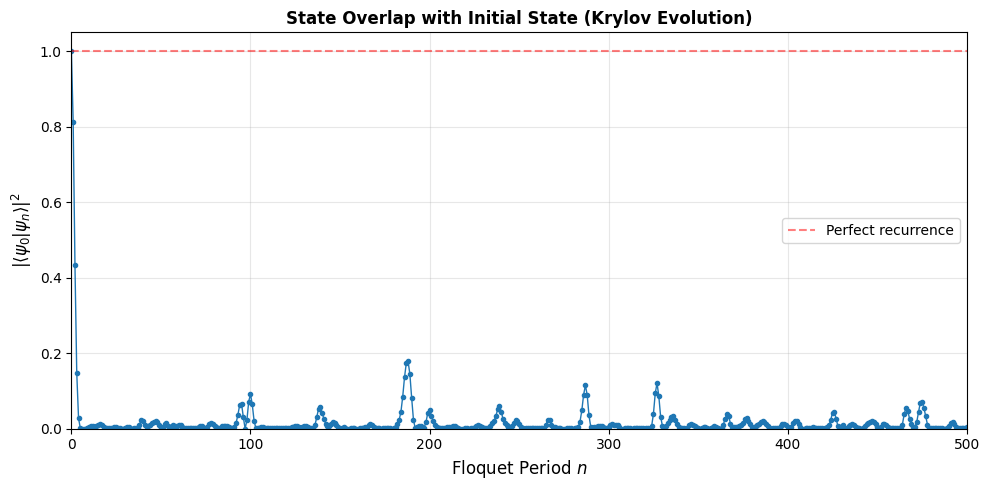


Overlap diagnostics:
  |⟨ψ₀|ψ₀⟩|² = 1.000000 (should be 1)
  |⟨ψ₀|ψ₁₀⟩|² = 0.003711
  |⟨ψ₀|ψ₅₀⟩|² = 0.003140
  |⟨ψ₀|ψ_500⟩|² = 0.003350
  No near-recurrences detected (threshold = 0.99)

UNITARITY CHECK

Norm preservation over 100 periods:
  ||ψ₀|| = 1.0000000000
  ||ψ₁₀₀|| = 1.0000000000
  Max |norm - 1|: 2.40e-14
  ✓ Unitarity preserved (Krylov evolution is accurate)

✓ SECTION E COMPLETE


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# EVOLUTION DIAGNOSTICS (KRYLOV VERSION)
# ============================================

def diagnose_evolution(psi0, apply_U, n_test=50, verbose=True):
    """
    Check if the Floquet evolution is actually changing states.
    Compute overlap |⟨ψ₀|ψₙ⟩|² to detect recurrences or periodicity.

    This version uses Krylov-based propagation (no dense matrices).

    Parameters
    ----------
    psi0 : ndarray, shape (Ns,)
        Initial state vector, dtype complex128.
    apply_U : callable
        Floquet propagator function: psi -> U_F @ psi.
        Created by make_floquet_propagator().
    n_test : int
        Number of Floquet periods to evolve.
    verbose : bool
        Print diagnostic information.

    Returns
    -------
    overlaps : ndarray, shape (n_test+1,)
        Array of |⟨ψ₀|ψₙ⟩|² for n = 0, 1, ..., n_test.
    """
    Ns = psi0.shape[0]

    # Validation
    assert psi0.shape == (Ns,), f"psi0 has shape {psi0.shape}"
    assert psi0.dtype == np.complex128, f"psi0 dtype is {psi0.dtype}, expected complex128"

    # Initialize
    psi_n = psi0.copy()
    overlaps = np.zeros(n_test + 1, dtype=np.float64)

    # Compute overlaps
    for n in range(n_test + 1):
        # |⟨ψ₀|ψₙ⟩|²
        overlaps[n] = np.abs(np.vdot(psi0, psi_n))**2

        # Evolve for next step (skip on last iteration)
        if n < n_test:
            psi_n = apply_U(psi_n)

    # ========================================
    # Plotting
    # ========================================
    plt.figure(figsize=(10, 5))
    plt.plot(range(n_test + 1), overlaps, 'o-', markersize=3, linewidth=1)
    plt.xlabel('Floquet Period $n$', fontsize=12)
    plt.ylabel(r'$|\langle\psi_0|\psi_n\rangle|^2$', fontsize=12)
    plt.title('State Overlap with Initial State (Krylov Evolution)', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Perfect recurrence')
    plt.xlim([0, n_test])
    plt.ylim([0, 1.05])
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # ========================================
    # Diagnostics
    # ========================================
    if verbose:
        print(f"\nOverlap diagnostics:")
        print(f"  |⟨ψ₀|ψ₀⟩|² = {overlaps[0]:.6f} (should be 1)")
        if n_test >= 10:
            print(f"  |⟨ψ₀|ψ₁₀⟩|² = {overlaps[10]:.6f}")
        if n_test >= 50:
            print(f"  |⟨ψ₀|ψ₅₀⟩|² = {overlaps[50]:.6f}")
        print(f"  |⟨ψ₀|ψ_{n_test}⟩|² = {overlaps[-1]:.6f}")

        # Check for approximate recurrences
        recurrence_threshold = 0.99
        recurrences = np.where(overlaps[1:] > recurrence_threshold)[0] + 1
        if len(recurrences) > 0:
            print(f"  Near-recurrences (|overlap|² > {recurrence_threshold}): n = {recurrences[:5].tolist()}")
        else:
            print(f"  No near-recurrences detected (threshold = {recurrence_threshold})")

    return overlaps



# ============================================
# MAIN EXECUTION
# ============================================

print("=" * 70)
print("SECTION E: EVOLUTION DIAGNOSTICS")
print("=" * 70)

# ========== TUNABLE PARAMETERS ==========
# Modify these values as needed

L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi / J_0     # Time period: np.pi/J_0 or 2*np.pi/J_0
n_steps = 500        # Number of Floquet periods to test
num_states = 5       # Number of random states to generate
seed = 42            # Random seed

# =========================================

print(f"\n{'='*70}")
print("PARAMETERS")
print(f"{'='*70}")
print(f"  L = {L}")
print(f"  J_0 = {J_0}")
print(f"  h_0 = {h_0}")
print(f"  g = {g}")
print(f"  T = {'π' if TP == np.pi/J_0 else '2π'}/J_0 = {TP:.6f}")
print(f"  n_steps = {n_steps}")

# ========== BUILD SYSTEM ==========
print(f"\n{'='*70}")
print("BUILDING FLOQUET SYSTEM")
print(f"{'='*70}")

ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
ising.build_hamiltonians()

# ========== CREATE KRYLOV PROPAGATOR ==========
print(f"\n{'='*70}")
print("CREATING KRYLOV-BASED FLOQUET PROPAGATOR")
print(f"{'='*70}")

apply_U = make_floquet_propagator(ising, tol=1e-10)
print(f"  Created apply_U(psi) -> U_F @ psi")
print(f"  Hilbert space dimension: Ns = {ising.Ns}")
print(f"  Method: Krylov subspace (no dense matrices)")

# ========== GENERATE RANDOM STATES ==========
print(f"\n{'='*70}")
print("GENERATING RANDOM INITIAL STATES")
print(f"{'='*70}")

random_states = generate_random_states(ising.Ns, num_states=num_states, seed=seed)

# ========== RUN DIAGNOSTICS ==========
print(f"\n{'='*70}")
print("EVOLUTION DIAGNOSTICS")
print(f"{'='*70}")

print(f"\nTesting evolution for {n_steps} Floquet periods...")
overlaps = diagnose_evolution(random_states[0], apply_U, n_test=n_steps, verbose=True)

# ========== VERIFY UNITARITY ==========
print(f"\n{'='*70}")
print("UNITARITY CHECK")
print(f"{'='*70}")

# Evolve a state and check norm preservation
psi_test = random_states[0].copy()
norms = [np.linalg.norm(psi_test)]

for n in range(100):
    psi_test = apply_U(psi_test)
    norms.append(np.linalg.norm(psi_test))

norms = np.array(norms)
max_norm_deviation = np.max(np.abs(norms - 1.0))

print(f"\nNorm preservation over 100 periods:")
print(f"  ||ψ₀|| = {norms[0]:.10f}")
print(f"  ||ψ₁₀₀|| = {norms[-1]:.10f}")
print(f"  Max |norm - 1|: {max_norm_deviation:.2e}")

if max_norm_deviation < 1e-9:
    print("  ✓ Unitarity preserved (Krylov evolution is accurate)")
else:
    print("  ⚠ Warning: Possible unitarity violation")

print(f"\n{'='*70}")
print("✓ SECTION E COMPLETE")
print(f"{'='*70}")

## Analysing the eigenvalue spectrum

SECTION F: FLOQUET SPECTRUM ANALYSIS

PARAMETERS
  L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  T = π/J_0 = 0.314159
  Analysis method = auto

BUILDING FLOQUET SYSTEM
System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully!
  H+ shape: (256, 256), nnz = 2304, density = 3.52e-02
  H- shape: (256, 256), nnz = 2304
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.04 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 9.37e-13

SPECTRUM ANALYSIS

--- Dense Method (Full Spectrum) ---

Building dense Floquet operator for L=8 (Ns=256)...
  Memory required: 1.0 MB
  Computing eigenvalues...


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


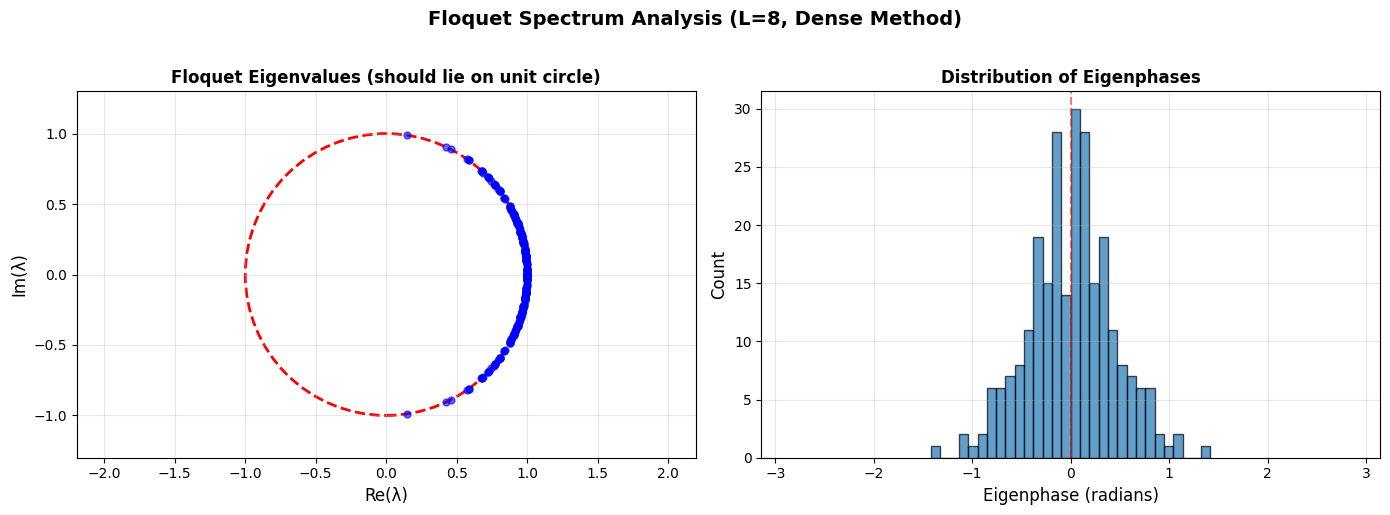


Floquet spectrum diagnostics:
  Number of eigenvalues: 256
  |λ| range: [1.000000, 1.000000] (should be ≈1)
  Max deviation from unit circle: 2.02e-14
  Eigenphases near 0 (|φ| < 0.1): 48 / 256
  Eigenphases near π (|φ-π| < 0.1): 0 / 256

--- Sampled Method (For Comparison) ---

Sampled spectral analysis for L=8 (Ns=256)...
  Method: Random state sampling (Krylov evolution)
  No dense matrices used


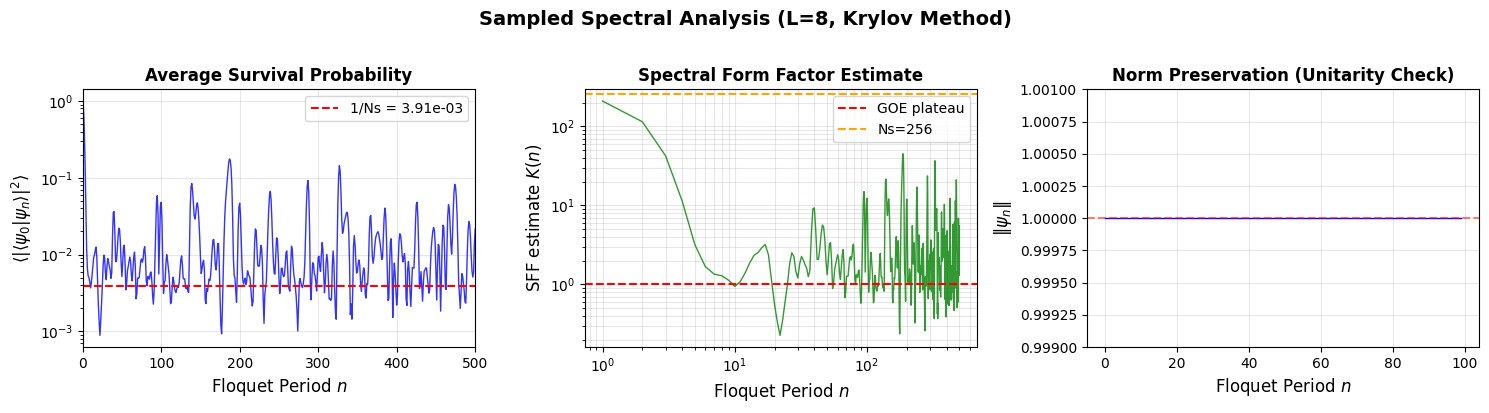


Sampled spectral diagnostics:
  Initial survival P(0) = 1.000000 (should be 1)
  Long-time survival P(500) = 2.151290e-02
  Expected for ergodic system: ~1/Ns = 3.906250e-03
  Norm preservation: max|norm-1| = 5.60e-14
  Estimated thermalization time: ~6 periods

SCALABILITY NOTE

Dense spectrum analysis:
  - L ≤ 10:  Feasible (1024×1024 = 1M elements, ~16 MB)
  - L = 12:  Borderline (4096×4096 = 16M elements, ~256 MB)
  - L = 14:  Difficult (16384×16384 = 256M elements, ~4 GB)
  - L ≥ 16:  Impossible (65536×65536 = 4B elements, ~64 GB)
  - L = 20:  Way impossible (1048576×1048576 elements, ~16 TB)

Sampled analysis:
  - Works for any L (memory: O(Ns) = O(2^L))
  - Provides statistical spectral information
  - Cannot give individual eigenvalues


✓ SECTION F COMPLETE


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm  # Only for small L validation
from scipy.sparse.linalg import eigs, eigsh, LinearOperator
import warnings

# ============================================
# FLOQUET SPECTRUM ANALYSIS
# ============================================

def analyze_floquet_spectrum_dense(ising_chain, verbose=True):
    """
    Full eigenspectrum analysis of the Floquet operator (DENSE METHOD).

    WARNING: This requires O(Ns²) memory and O(Ns³) computation.
    Only usable for L ≤ 12 (Ns ≤ 4096).

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet system with Hamiltonians built.
    verbose : bool
        Print diagnostic information.

    Returns
    -------
    eigenvalues : ndarray, shape (Ns,)
        Complex eigenvalues of U_F (should lie on unit circle).
    eigenphases : ndarray, shape (Ns,)
        Phases of eigenvalues (quasi-energies × T/ℏ).
    """
    L = ising_chain.L
    Ns = ising_chain.Ns

    if L > 12:
        raise MemoryError(
            f"Full spectrum analysis not possible for L={L} (Ns={Ns}).\n"
            f"Dense U_F requires {Ns*Ns*16/1e9:.1f} GB memory.\n"
            f"Use analyze_floquet_spectrum_sampled() for large systems."
        )

    if verbose:
        print(f"\nBuilding dense Floquet operator for L={L} (Ns={Ns})...")
        print(f"  Memory required: {Ns*Ns*16/1e6:.1f} MB")

    # ========================================
    # Build dense Floquet unitary
    # ========================================
    T = ising_chain.T
    hbar = ising_chain.hbar
    dt_half = T / (2.0 * hbar)

    H_plus_dense = ising_chain.H_plus_sparse.toarray()
    H_minus_dense = ising_chain.H_minus_sparse.toarray()

    U_plus = expm(-1j * H_plus_dense * dt_half)
    U_minus = expm(-1j * H_minus_dense * dt_half)
    U_floquet = U_minus @ U_plus

    # ========================================
    # Compute eigenvalues
    # ========================================
    if verbose:
        print(f"  Computing eigenvalues...")

    eigenvalues = np.linalg.eigvals(U_floquet)
    eigenphases = np.angle(eigenvalues)

    # ========================================
    # Plotting
    # ========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot eigenvalues on complex plane
    axes[0].plot(np.real(eigenvalues), np.imag(eigenvalues), 'bo',
                 markersize=5, alpha=0.6)
    circle = plt.Circle((0, 0), 1, fill=False, color='r',
                         linestyle='--', linewidth=2)
    axes[0].add_patch(circle)
    axes[0].set_xlabel('Re(λ)', fontsize=12)
    axes[0].set_ylabel('Im(λ)', fontsize=12)
    axes[0].set_title('Floquet Eigenvalues (should lie on unit circle)',
                      fontweight='bold')
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([-1.3, 1.3])
    axes[0].set_ylim([-1.3, 1.3])

    # Histogram of eigenphases
    axes[1].hist(eigenphases, bins=30, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Eigenphase (radians)', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Distribution of Eigenphases', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
    axes[1].set_xlim([-np.pi, np.pi])

    plt.suptitle(f'Floquet Spectrum Analysis (L={L}, Dense Method)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ========================================
    # Diagnostics
    # ========================================
    mags = np.abs(eigenvalues)

    if verbose:
        print(f"\nFloquet spectrum diagnostics:")
        print(f"  Number of eigenvalues: {len(eigenvalues)}")
        print(f"  |λ| range: [{np.min(mags):.6f}, {np.max(mags):.6f}] (should be ≈1)")
        print(f"  Max deviation from unit circle: {np.max(np.abs(mags - 1)):.2e}")
        print(f"  Eigenphases near 0 (|φ| < 0.1): {np.sum(np.abs(eigenphases) < 0.1)} / {len(eigenphases)}")
        print(f"  Eigenphases near π (|φ-π| < 0.1): {np.sum(np.abs(np.abs(eigenphases) - np.pi) < 0.1)} / {len(eigenphases)}")

    return eigenvalues, eigenphases


def analyze_floquet_spectrum_sampled(ising_chain, n_samples=1000, n_moments=4,
                                      seed=42, verbose=True):
    """
    Sample-based spectral analysis for large systems (Krylov-compatible).

    Since full diagonalization is impossible for large L, this function
    estimates spectral properties using random state sampling:

    1. Survival probability: P(t) = |⟨ψ₀|U^n|ψ₀⟩|² averaged over random ψ₀
    2. Spectral form factor (SFF): K(n) = |Tr(U^n)|²/Ns² ≈ ⟨|⟨ψ|U^n|ψ⟩|²⟩
    3. Inverse participation ratio of time-evolved states

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet system.
    n_samples : int
        Number of time steps to sample.
    n_moments : int
        Number of random states for averaging.
    seed : int
        Random seed.
    verbose : bool
        Print information.

    Returns
    -------
    results : dict
        Dictionary containing sampled spectral diagnostics.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns

    if verbose:
        print(f"\nSampled spectral analysis for L={L} (Ns={Ns})...")
        print(f"  Method: Random state sampling (Krylov evolution)")
        print(f"  No dense matrices used")

    # Create Krylov propagator
    apply_U = make_floquet_propagator(ising_chain, tol=1e-10)

    np.random.seed(seed)

    # ========================================
    # 1. Survival probability P(n) = |⟨ψ₀|ψₙ⟩|²
    # ========================================
    survival_probs = np.zeros((n_moments, n_samples + 1))

    for m in range(n_moments):
        psi0 = np.random.randn(Ns) + 1j * np.random.randn(Ns)
        psi0 = (psi0 / np.linalg.norm(psi0)).astype(np.complex128)

        psi_n = psi0.copy()
        for n in range(n_samples + 1):
            survival_probs[m, n] = np.abs(np.vdot(psi0, psi_n))**2
            if n < n_samples:
                psi_n = apply_U(psi_n)

    avg_survival = np.mean(survival_probs, axis=0)

    # ========================================
    # 2. Estimate spectral form factor via random states
    # ========================================
    # K(n) ≈ Ns × ⟨|⟨ψ|U^n|ψ⟩|²⟩ for Haar-random ψ
    sff_estimate = Ns * avg_survival

    # ========================================
    # 3. Norm check (should stay 1)
    # ========================================
    psi_test = np.random.randn(Ns) + 1j * np.random.randn(Ns)
    psi_test = (psi_test / np.linalg.norm(psi_test)).astype(np.complex128)

    norms = []
    for n in range(min(100, n_samples)):
        norms.append(np.linalg.norm(psi_test))
        psi_test = apply_U(psi_test)
    norms = np.array(norms)

    # ========================================
    # Plotting
    # ========================================
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Survival probability
    times = np.arange(n_samples + 1)
    axes[0].semilogy(times, avg_survival, 'b-', linewidth=1, alpha=0.8)
    axes[0].axhline(y=1/Ns, color='r', linestyle='--',
                    label=f'1/Ns = {1/Ns:.2e}')
    axes[0].set_xlabel('Floquet Period $n$', fontsize=12)
    axes[0].set_ylabel(r'$\langle|\langle\psi_0|\psi_n\rangle|^2\rangle$', fontsize=12)
    axes[0].set_title('Average Survival Probability', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, n_samples])

    # Plot 2: Spectral form factor estimate
    axes[1].loglog(times[1:], sff_estimate[1:], 'g-', linewidth=1, alpha=0.8)
    axes[1].axhline(y=1, color='r', linestyle='--', label='GOE plateau')
    axes[1].axhline(y=Ns, color='orange', linestyle='--', label=f'Ns={Ns}')
    axes[1].set_xlabel('Floquet Period $n$', fontsize=12)
    axes[1].set_ylabel('SFF estimate $K(n)$', fontsize=12)
    axes[1].set_title('Spectral Form Factor Estimate', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, which='both')

    # Plot 3: Norm preservation
    axes[2].plot(range(len(norms)), norms, 'b-', linewidth=1)
    axes[2].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Floquet Period $n$', fontsize=12)
    axes[2].set_ylabel(r'$\|\psi_n\|$', fontsize=12)
    axes[2].set_title('Norm Preservation (Unitarity Check)', fontweight='bold')
    axes[2].set_ylim([0.999, 1.001])
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Sampled Spectral Analysis (L={L}, Krylov Method)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ========================================
    # Diagnostics
    # ========================================
    if verbose:
        print(f"\nSampled spectral diagnostics:")
        print(f"  Initial survival P(0) = {avg_survival[0]:.6f} (should be 1)")
        print(f"  Long-time survival P({n_samples}) = {avg_survival[-1]:.6e}")
        print(f"  Expected for ergodic system: ~1/Ns = {1/Ns:.6e}")
        print(f"  Norm preservation: max|norm-1| = {np.max(np.abs(norms-1)):.2e}")

        # Estimate thermalization time
        idx_thermal = np.argmax(avg_survival < 2/Ns) if np.any(avg_survival < 2/Ns) else n_samples
        print(f"  Estimated thermalization time: ~{idx_thermal} periods")

    results = {
        'survival_prob': avg_survival,
        'sff_estimate': sff_estimate,
        'norms': norms,
        'n_samples': n_samples,
        'n_moments': n_moments
    }

    return results


def analyze_floquet_spectrum(ising_chain, method='auto', **kwargs):
    """
    Unified interface for Floquet spectrum analysis.

    Automatically selects appropriate method based on system size.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet system.
    method : str
        'auto': Choose based on L (dense for L≤10, sampled for L>10)
        'dense': Force dense diagonalization (will fail for large L)
        'sampled': Use sampling-based analysis
    **kwargs : dict
        Additional arguments passed to the specific method.

    Returns
    -------
    Result depends on method used.
    """
    L = ising_chain.L

    if method == 'auto':
        if L <= 10:
            method = 'dense'
        else:
            method = 'sampled'
            print(f"Note: L={L} is large. Using sampled analysis (no full spectrum).")

    if method == 'dense':
        return analyze_floquet_spectrum_dense(ising_chain, **kwargs)
    elif method == 'sampled':
        return analyze_floquet_spectrum_sampled(ising_chain, **kwargs)
    else:
        raise ValueError(f"Unknown method: {method}")


# ============================================
# MAIN EXECUTION
# ============================================

print("=" * 70)
print("SECTION F: FLOQUET SPECTRUM ANALYSIS")
print("=" * 70)

# ========== TUNABLE PARAMETERS ==========
# Modify these values as needed

L = 8                # Chain length (use L ≤ 10 for full spectrum)
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = np.pi / J_0     # Time period: np.pi/J_0 or 2*np.pi/J_0
n_samples = 500      # For sampled analysis: number of time steps

# Analysis method: 'auto', 'dense', or 'sampled'
analysis_method = 'auto'

# =========================================

print(f"\n{'='*70}")
print("PARAMETERS")
print(f"{'='*70}")
print(f"  L = {L}")
print(f"  J_0 = {J_0}")
print(f"  h_0 = {h_0}")
print(f"  g = {g}")
print(f"  T = {'π' if TP == np.pi/J_0 else '2π'}/J_0 = {TP:.6f}")
print(f"  Analysis method = {analysis_method}")

# ========== BUILD SYSTEM ==========
print(f"\n{'='*70}")
print("BUILDING FLOQUET SYSTEM")
print(f"{'='*70}")

ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
ising.build_hamiltonians()

# ========== SPECTRUM ANALYSIS ==========
print(f"\n{'='*70}")
print("SPECTRUM ANALYSIS")
print(f"{'='*70}")

if analysis_method == 'auto' and L <= 10:
    # For small L, show both methods for comparison
    print("\n--- Dense Method (Full Spectrum) ---")
    eigenvalues, eigenphases = analyze_floquet_spectrum(ising, method='dense')

    print("\n--- Sampled Method (For Comparison) ---")
    results_sampled = analyze_floquet_spectrum(ising, method='sampled',
                                                n_samples=n_samples)
else:
    # Use the specified or auto-selected method
    result = analyze_floquet_spectrum(ising, method=analysis_method,
                                       n_samples=n_samples)

# ========== SCALABILITY NOTE ==========
print(f"\n{'='*70}")
print("SCALABILITY NOTE")
print(f"{'='*70}")
print(f"""
Dense spectrum analysis:
  - L ≤ 10:  Feasible ({2**10}x{2**10} = 1M elements, ~16 MB)
  - L = 12:  Borderline ({2**12}x{2**12} = 16M elements, ~256 MB)
  - L = 14:  Difficult ({2**14}x{2**14} = 256M elements, ~4 GB)
  - L ≥ 16:  Impossible ({2**16}x{2**16} = 4B elements, ~64 GB)
  - L = 20:  Way impossible ({2**20}x{2**20} elements, ~16 TB)

Sampled analysis:
  - Works for any L (memory: O(Ns) = O(2^L))
  - Provides statistical spectral information
  - Cannot give individual eigenvalues
""")

print(f"\n{'='*70}")
print("✓ SECTION F COMPLETE")
print(f"{'='*70}")

## Computing the ensemble infinite temperature autocorrelation function

$$C_i(nT) = \langle \psi_0 | [\sigma^z_i(nT) ][\sigma^z_i(0) ] | \psi_0 \rangle $$

AUTOCORRELATION DIAGNOSTIC TEST

Parameters: L=6, J_0=10.0, h_0=20.0, T=2π/J_0
            site=3, n_periods=200, num_states=1

[1] Building Floquet system...
System Parameters:
  Chain length L = 6
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 64

Hamiltonians constructed successfully!
  H+ shape: (64, 64), nnz = 448, density = 1.09e-01
  H- shape: (64, 64), nnz = 448
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.01 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 2.27e-13

[2] Creating operators...

[3] Running single-state diagnostic...

  Single-state diagnostic:
    C(0) = 1.000000 (expect 1.0)
    C(1) = 0.726085
    C(20) = 0.702178
    ✓ C(0) = 1 verified

[4] Generating random states...

Generated 1 random initial states:
  Hilbert space dimension: Ns = 64
  Return format: matrix
  dtype: complex128
  Sample norm check: [1.]

[5] Computing ensemble autocorrelation...

  Ensemble autocorrelation (batched two-

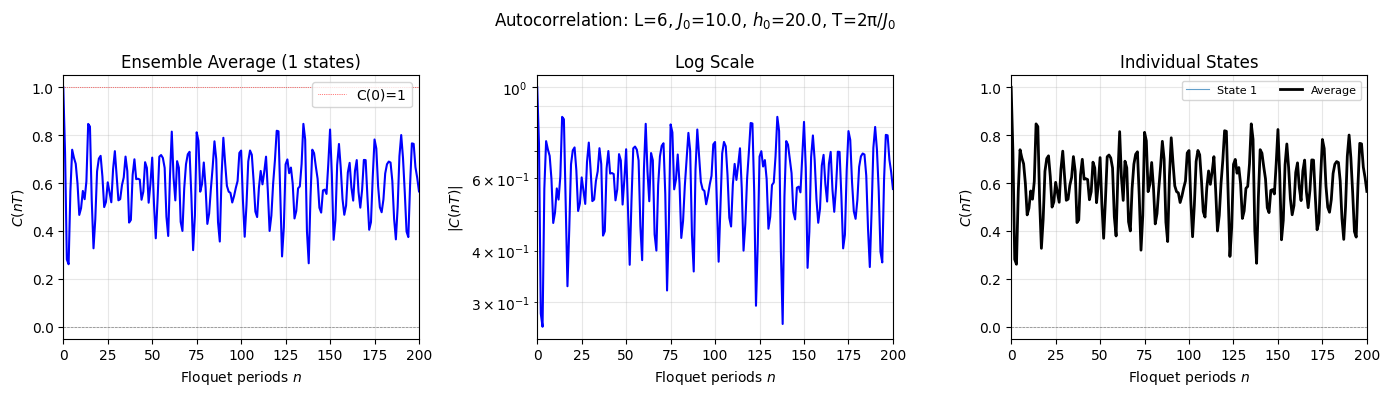


SUMMARY
C(0) = 1.000000  (should be 1.0)
C(10T) = 0.495184
C(100T) = 0.735800
C(200T) = 0.565268

Saved: times, C_avg, C_all, ising


In [22]:
import numpy as np
import time

# ============================================================================
# BATCHED ENSEMBLE AUTOCORRELATION
# ============================================================================

def compute_ensemble_average_batched(
    random_states,
    apply_U,
    apply_O,
    n_periods,
    *,
    batch_size=None,
    store_all=True,
    return_real=True,
    verbose=True,
    progress_interval=2.0
):
    """
    Compute ensemble-averaged autocorrelation C(nT) = ⟨O(nT) O(0)⟩_β=0.

    Uses the two-ket method with batched evolution for efficiency.
    """
    # ========================================
    # Input handling
    # ========================================
    if isinstance(random_states, np.ndarray) and random_states.ndim == 2:
        Psi_all = random_states.astype(np.complex128)
        Ns, num_states = Psi_all.shape
    elif isinstance(random_states, list):
        num_states = len(random_states)
        Ns = random_states[0].shape[0]
        Psi_all = np.column_stack(random_states).astype(np.complex128)
    else:
        raise TypeError("random_states must be list or 2D array")

    # Auto batch size
    if batch_size is None:
        batch_size = min(50, num_states)
    batch_size = min(batch_size, num_states)

    # Block structure
    n_full_blocks = num_states // batch_size
    remainder = num_states % batch_size
    n_blocks = n_full_blocks + (1 if remainder > 0 else 0)

    # Storage
    times = np.arange(n_periods + 1, dtype=np.float64)
    if store_all:
        C_all = np.zeros((num_states, n_periods + 1), dtype=np.complex128)
    C_sum = np.zeros(n_periods + 1, dtype=np.complex128)

    # ========================================
    # Progress setup
    # ========================================
    total_work = num_states * (n_periods + 1)  # Total period-state pairs
    work_done = 0

    if verbose:
        print(f"\n  Ensemble autocorrelation (batched two-ket):")
        print(f"    States: {num_states}, Periods: {n_periods}, Batches: {n_blocks}")
        print(f"    Batch size: {batch_size}")
        print()

    total_start = time.time()
    last_print = total_start

    # ========================================
    # Main loop over blocks
    # ========================================
    for block_idx in range(n_blocks):
        # Block range
        start_state = block_idx * batch_size
        end_state = start_state + (batch_size if block_idx < n_full_blocks else remainder)
        B_block = end_state - start_state

        # Initialize two kets for this block
        Psi0_block = Psi_all[:, start_state:end_state]
        Psi = Psi0_block.copy()              # |Ψₙ⟩ = Uⁿ|Ψ₀⟩
        Phi = apply_O(Psi0_block.copy())     # |Φₙ⟩ = Uⁿ O|Ψ₀⟩

        # Storage for this block
        C_block = np.zeros((B_block, n_periods + 1), dtype=np.complex128)

        # ========================================
        # Loop over Floquet periods
        # ========================================
        for n in range(n_periods + 1):
            # C(nT) = ⟨Ψₙ|O|Φₙ⟩
            O_Phi = apply_O(Phi)
            C_block[:, n] = np.sum(np.conj(Psi) * O_Phi, axis=0)

            # Evolve for next step
            if n < n_periods:
                Psi = apply_U(Psi)
                Phi = apply_U(Phi)

            # Progress (within period loop)
            work_done += B_block
            now = time.time()
            if verbose and (now - last_print >= progress_interval):
                pct = 100 * work_done / total_work
                elapsed = now - total_start
                rate = work_done / elapsed
                eta = (total_work - work_done) / rate if rate > 0 else 0
                print(f"    Progress: {pct:5.1f}% | Block {block_idx+1}/{n_blocks}, "
                      f"Period {n+1}/{n_periods+1} | ETA: {eta:.0f}s")
                last_print = now

        # Accumulate
        if store_all:
            C_all[start_state:end_state, :] = C_block
        C_sum += np.sum(C_block, axis=0)

    # ========================================
    # Finalize
    # ========================================
    C_avg = C_sum / num_states
    total_time = time.time() - total_start

    if verbose:
        print(f"\n  ✓ Complete in {total_time:.1f}s")
        print(f"    C(0) = {np.real(C_avg[0]):.6f} (should be 1.0 for σ²=I)")
        print(f"    C({n_periods}T) = {np.real(C_avg[-1]):.6f}")

    # Return
    if return_real:
        C_avg = np.real(C_avg)
        if store_all:
            C_all = np.real(C_all)

    if store_all:
        return times, C_avg, C_all
    else:
        return times, C_avg


# ============================================================================
# DIAGNOSTIC: SINGLE STATE TEST
# ============================================================================

def test_single_state_autocorrelation(apply_U, apply_O, Ns, n_periods=20, seed=42):
    """
    Test autocorrelation for a single state to verify formula correctness.

    C(nT) = ⟨ψ₀|O(nT) O(0)|ψ₀⟩ = ⟨Ψₙ|O|Φₙ⟩

    For O = σ^z: C(0) = ⟨ψ|σ^z σ^z|ψ⟩ = ⟨ψ|I|ψ⟩ = 1
    """
    print("\n  Single-state diagnostic:")

    np.random.seed(seed)
    psi0 = np.random.randn(Ns) + 1j * np.random.randn(Ns)
    psi0 = psi0 / np.linalg.norm(psi0)
    psi0 = psi0.astype(np.complex128)

    # Two-ket method
    Psi = psi0.copy()
    Phi = apply_O(psi0.copy())

    C = np.zeros(n_periods + 1, dtype=np.complex128)

    for n in range(n_periods + 1):
        O_Phi = apply_O(Phi)
        C[n] = np.vdot(Psi, O_Phi)

        if n < n_periods:
            Psi = apply_U(Psi)
            Phi = apply_U(Phi)

    print(f"    C(0) = {np.real(C[0]):.6f} (expect 1.0)")
    print(f"    C(1) = {np.real(C[1]):.6f}")
    print(f"    C({n_periods}) = {np.real(C[-1]):.6f}")

    if abs(np.real(C[0]) - 1.0) > 0.01:
        print("    ⚠ WARNING: C(0) ≠ 1, check σ^z implementation!")
    else:
        print("    ✓ C(0) = 1 verified")

    return C


# ============================================================================
# TEST BENCH WITH PLOTTING
# ============================================================================

print("=" * 60)
print("AUTOCORRELATION DIAGNOSTIC TEST")
print("=" * 60)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║                        TUNABLE PARAMETERS                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

L = 6
J_0 = 10.0
h_0 = 20.0
g = 1.0
bc = 'open'
TP = 2 * np.pi / J_0
site_i = L // 2
n_periods = 200
num_states = 1
batch_size = 1
seed = 42

# ============================================================================

print(f"\nParameters: L={L}, J_0={J_0}, h_0={h_0}, T=2π/J_0")
print(f"            site={site_i}, n_periods={n_periods}, num_states={num_states}")

# Build system
print("\n[1] Building Floquet system...")
ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
ising.build_hamiltonians()

# Create operators
print("\n[2] Creating operators...")
apply_U = make_floquet_propagator(ising, tol=1e-10)
apply_sigma_z = make_sigma_z_matvec(ising, site_i)

# Diagnostic: single state test
print("\n[3] Running single-state diagnostic...")
C_single = test_single_state_autocorrelation(apply_U, apply_sigma_z, ising.Ns, n_periods=20)

# Generate random states
print("\n[4] Generating random states...")
random_states = generate_random_states(ising.Ns, num_states=num_states, seed=seed,
                                        return_format='matrix')

# Compute ensemble average
print("\n[5] Computing ensemble autocorrelation...")
times, C_avg, C_all = compute_ensemble_average_batched(
    random_states, apply_U, apply_sigma_z, n_periods,
    batch_size=batch_size, store_all=True, verbose=True
)

# ============================================================================
# PLOTTING
# ============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Ensemble average (linear)
ax1 = axes[0]
ax1.plot(times, C_avg, 'b-', lw=1.5)
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.axhline(1, color='red', ls=':', lw=0.5, label='C(0)=1')
ax1.set_xlabel('Floquet periods $n$')
ax1.set_ylabel(r'$C(nT)$')
ax1.set_title(f'Ensemble Average ({num_states} states)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, n_periods)

# Plot 2: Log scale
ax2 = axes[1]
ax2.semilogy(times, np.abs(C_avg), 'b-', lw=1.5)
ax2.set_xlabel('Floquet periods $n$')
ax2.set_ylabel(r'$|C(nT)|$')
ax2.set_title('Log Scale')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(0, n_periods)

# Plot 3: Individual states
ax3 = axes[2]
colors = plt.cm.tab10(np.arange(num_states))
for i in range(num_states):
    ax3.plot(times, C_all[i, :], color=colors[i], lw=0.8, alpha=0.7, label=f'State {i+1}')
ax3.plot(times, C_avg, 'k-', lw=2, label='Average')
ax3.axhline(0, color='gray', ls='--', lw=0.5)
ax3.set_xlabel('Floquet periods $n$')
ax3.set_ylabel(r'$C(nT)$')
ax3.set_title('Individual States')
ax3.legend(fontsize=8, ncol=2)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, n_periods)

fig.suptitle(f'Autocorrelation: L={L}, $J_0$={J_0}, $h_0$={h_0}, T=2π/$J_0$', fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"C(0) = {C_avg[0]:.6f}  (should be 1.0)")
print(f"C(10T) = {C_avg[10]:.6f}")
print(f"C(100T) = {C_avg[100]:.6f}")
print(f"C({n_periods}T) = {C_avg[-1]:.6f}")
print("\nSaved: times, C_avg, C_all, ising")

## $C_i(t) $ w.r.t different potentials

### Results code

In [23]:
import numpy as np
import time

# ============================================================================
# COMPUTATION FUNCTION WITH BATCH SIZE CONTROL
# ============================================================================

def run_autocorr_coupling_comparison(
    L=8,
    site_i=3,
    g=1.0,
    J_0_values=[4, 20, 40, 60],
    h_0_relation='2*J_0',
    NTP=1,
    n_steps=500,
    num_states=20,
    batch_size=None,
    seed=42,
    tol=1e-10,
    store_all=True,
    verbose=True
):
    """
    Compute autocorrelation for different coupling strengths.
    Period T = NTP * π/J_0 varies with J_0.

    Uses Krylov-based two-ket method (no dense matrices).

    Parameters
    ----------
    L : int
        System size (chain length).
    site_i : int
        Site index for σ^z measurement.
    g : float
        Transverse field strength (static perturbation).
    J_0_values : list
        List of J_0 values to scan.
    h_0_relation : str or list
        If string: '2*J_0' means h_0 = 2*J_0 for all cases
                   'J_0' means h_0 = J_0 for all cases
        If list: custom h_0 values for each J_0.
    NTP : float
        Time period factor N in TP = N*π/J_0.
    n_steps : int
        Number of Floquet periods to evolve.
    num_states : int
        Number of random initial states for ensemble averaging.
    batch_size : int or None
        Number of states to process in parallel per block.
        If None, auto-selects min(50, num_states).
        Larger batch_size = faster but more memory.
    seed : int
        Random seed for reproducibility.
    tol : float
        Tolerance for Krylov time evolution.
    store_all : bool
        If True, store individual C(t) for each state.
        If False, only store ensemble average (saves memory).
    verbose : bool
        Print progress updates.

    Returns
    -------
    results_dict : dict
        Dictionary with J_0 values as keys, each containing:
        {'times': array, 'C_avg': array, 'C_all': array (if store_all),
         'J_0': float, 'h_0': float, 'T': float, 'ratio': float}
    base_params : dict
        System parameters.
    """

    # ========================================
    # Determine h_0 values
    # ========================================
    if isinstance(h_0_relation, str):
        if h_0_relation == '2*J_0':
            h_0_values = [2 * J_0 for J_0 in J_0_values]
        elif h_0_relation == 'J_0':
            h_0_values = [J_0 for J_0 in J_0_values]
        else:
            raise ValueError(f"Unknown relation: {h_0_relation}")
    else:
        h_0_values = list(h_0_relation)
        if len(h_0_values) != len(J_0_values):
            raise ValueError("h_0_values must have same length as J_0_values")

    # Auto batch size
    if batch_size is None:
        batch_size = min(50, num_states)

    if verbose:
        print("=" * 70)
        print("AUTOCORRELATION VS COUPLING STRENGTH COMPUTATION")
        print("=" * 70)
        print(f"System Parameters:")
        print(f"  L = {L}, site i = {site_i}, g = {g}")
        print(f"  Period: T = {NTP}π/J_0 (varies with J_0)")
        print(f"  J_0 values: {J_0_values}")
        print(f"  h_0 values: {h_0_values}")
        print(f"  n_steps = {n_steps}")
        print(f"  num_states = {num_states}, batch_size = {batch_size}")
        print(f"  store_all = {store_all}")
        print(f"  Method: Krylov two-ket (batched)")
        print("=" * 70)

    # Storage
    results_dict = {}
    total_start = time.time()

    # ========================================
    # Compute for each coupling strength
    # ========================================
    for idx, (J_0, h_0) in enumerate(zip(J_0_values, h_0_values)):
        TP = NTP * np.pi / J_0  # Period depends on J_0

        if verbose:
            print(f"\n{'─'*70}")
            print(f"[{idx+1}/{len(J_0_values)}] Computing J_0 = {J_0}, h_0 = {h_0}")
            print(f"                Period T = {NTP}π/{J_0} = {TP:.6f}")
            print(f"{'─'*70}")

        step_start = time.time()

        # ----------------------------------------
        # Initialize system
        # ----------------------------------------
        ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
        ising.build_hamiltonians()

        # ----------------------------------------
        # Create Krylov-based operators
        # ----------------------------------------
        apply_U = make_floquet_propagator(ising, tol=tol)
        apply_sigma_z = make_sigma_z_matvec(ising, site_i=site_i)

        # ----------------------------------------
        # Generate random states
        # ----------------------------------------
        random_states = generate_random_states(
            ising.Ns,
            num_states=num_states,
            seed=seed,
            verbose=False,
            return_format='matrix'  # Returns (Ns, num_states) array
        )

        # ----------------------------------------
        # Compute ensemble average using batched two-ket method
        # ----------------------------------------
        result = compute_ensemble_average_batched(
            random_states,
            apply_U,
            apply_sigma_z,
            n_periods=n_steps,
            batch_size=batch_size,
            store_all=store_all,
            return_real=True,
            verbose=verbose
        )

        # Unpack result based on store_all
        if store_all:
            times, C_avg, C_all = result
        else:
            times, C_avg = result
            C_all = None

        step_time = time.time() - step_start

        # ----------------------------------------
        # Store results
        # ----------------------------------------
        results_dict[J_0] = {
            'times': times,
            'C_avg': C_avg,
            'J_0': J_0,
            'h_0': h_0,
            'T': TP,
            'ratio': h_0 / J_0
        }

        if store_all and C_all is not None:
            results_dict[J_0]['C_all'] = C_all

        if verbose:
            print(f"  ✓ Complete in {step_time:.1f}s: C(0) = {C_avg[0]:.6f}, "
                  f"C(final) = {C_avg[-1]:.6f}")

    total_time = time.time() - total_start

    # ========================================
    # Store base parameters
    # ========================================
    base_params = {
        'L': L,
        'site_i': site_i,
        'g': g,
        'num_states': num_states,
        'batch_size': batch_size,
        'h_0_relation': h_0_relation,
        'NTP': NTP,
        'n_steps': n_steps,
        'store_all': store_all,
        'method': 'krylov_two_ket_batched'
    }

    if verbose:
        print(f"\n{'='*70}")
        print(f"COMPUTATION COMPLETE")
        print(f"  Total time: {total_time:.1f}s")
        print(f"  Average per J_0: {total_time/len(J_0_values):.1f}s")
        print(f"{'='*70}")

    return results_dict, base_params


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 70)
print("SECTION I: COUPLING STRENGTH COMPARISON")
print("=" * 70)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║                        TUNABLE PARAMETERS                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

L = 12                         # Chain length
J_0_list = [1, 10, 20, 40]     # Coupling strengths to scan
h_0_list = [2, 20, 80, 40]             # h_0 = 2*J_0 for all (or provide list)
g = 1.0                        # Transverse field strength
NTP = 1                        # Time period factor: T = NTP * π/J_0
site_i = L // 2                # Bulk site for measurement
n_steps = 200                  # Number of Floquet periods
num_states = 20                # Number of states in ensemble
batch_size = 10                # States processed in parallel (None=auto)
seed = 42                      # Random seed
store_all = True               # Store individual traces

# ============================================================================

print(f"\n{'='*70}")
print("PARAMETERS")
print(f"{'='*70}")
print(f"  L = {L}")
print(f"  J_0_list = {J_0_list}")
print(f"  h_0_relation = {h_0_list}")
print(f"  g = {g}")
print(f"  T = {NTP}π/J_0")
print(f"  site_i = {site_i}")
print(f"  n_steps = {n_steps}")
print(f"  num_states = {num_states}")
print(f"  batch_size = {batch_size}")
print(f"  store_all = {store_all}")

# ========== RUN COMPUTATION ==========
results, params = run_autocorr_coupling_comparison(
    L=L,
    site_i=site_i,
    g=g,
    J_0_values=J_0_list,
    h_0_relation=h_0_list,
    NTP=NTP,
    n_steps=n_steps,
    num_states=num_states,
    batch_size=batch_size,
    seed=seed,
    store_all=store_all,
    verbose=True
)

# ========== VERIFY OUTPUT FORMAT ==========
print(f"\n{'='*70}")
print("OUTPUT VERIFICATION")
print(f"{'='*70}")

print(f"\nresults keys: {list(results.keys())}")
print(f"base_params: {params}")

# Check format of one entry
sample_J0 = J_0_list[0]
sample_result = results[sample_J0]
print(f"\nSample result for J_0={sample_J0}:")
print(f"  times: shape {sample_result['times'].shape}")
print(f"  C_avg: shape {sample_result['C_avg'].shape}")
print(f"  C_avg(0) = {sample_result['C_avg'][0]:.6f} (should be ~1.0)")
print(f"  C_avg(end) = {sample_result['C_avg'][-1]:.6f}")
if 'C_all' in sample_result:
    print(f"  C_all: shape {sample_result['C_all'].shape}")
print(f"  T = {sample_result['T']:.6f}")
print(f"  ratio h_0/J_0 = {sample_result['ratio']}")

print(f"\n{'='*70}")
print("✓ COMPUTATION COMPLETE - Ready for plotting")
print(f"{'='*70}")

SECTION I: COUPLING STRENGTH COMPARISON

PARAMETERS
  L = 12
  J_0_list = [1, 10, 20, 40]
  h_0_relation = [2, 20, 80, 40]
  g = 1.0
  T = 1π/J_0
  site_i = 6
  n_steps = 200
  num_states = 20
  batch_size = 10
  store_all = True
AUTOCORRELATION VS COUPLING STRENGTH COMPUTATION
System Parameters:
  L = 12, site i = 6, g = 1.0
  Period: T = 1π/J_0 (varies with J_0)
  J_0 values: [1, 10, 20, 40]
  h_0 values: [2, 20, 80, 40]
  n_steps = 200
  num_states = 20, batch_size = 10
  store_all = True
  Method: Krylov two-ket (batched)

──────────────────────────────────────────────────────────────────────
[1/4] Computing J_0 = 1, h_0 = 2
                Period T = 1π/1 = 3.141593
──────────────────────────────────────────────────────────────────────
System Parameters:
  Chain length L = 12
  J_0 = 1
  h_0 = 2
  g = 1.0
  Period T = 3.141593
  Hilbert space dimension = 4096

Hamiltonians constructed successfully!
  H+ shape: (4096, 4096), nnz = 53248, density = 3.17e-03
  H- shape: (4096, 4096),

### Saving the file

It takes ~2 hrs to run for 12 sites 200 Floquet steps at $\pi/J_0$.

In [32]:
import numpy as np
import pickle
import json
import os
from datetime import datetime

# ============================================================================
# SAVE/LOAD FUNCTIONS FOR AUTOCORRELATION RESULTS
# ============================================================================

def save_autocorr_results(results_dict, base_params, filename=None, save_dir='.',
                          format='npz', verbose=True):
    """
    Save autocorrelation results to a file for later plotting.

    Parameters
    ----------
    results_dict : dict
        Results dictionary from run_autocorr_* functions.
    base_params : dict
        Base parameters dictionary.
    filename : str or None
        Output filename (without extension). If None, auto-generates from params.
    save_dir : str
        Directory to save files.
    format : str
        'npz' (recommended) or 'pkl'
    verbose : bool
        Print save information.

    Returns
    -------
    filepath : str
        Full path to saved file.
    """

    # Auto-generate filename if not provided
    if filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        L = base_params.get('L', 'X')
        method = base_params.get('method', 'autocorr')
        filename = f"autocorr_L{L}_{method}_{timestamp}"

    os.makedirs(save_dir, exist_ok=True)

    if format == 'npz':
        # ========================================
        # NPZ FORMAT (recommended for numpy arrays)
        # ========================================
        filepath = os.path.join(save_dir, f"{filename}.npz")

        # Flatten results_dict for npz storage
        save_dict = {}

        # Save base_params as JSON string
        save_dict['__base_params__'] = json.dumps(base_params)
        save_dict['__keys__'] = json.dumps(list(results_dict.keys()))

        # Save each result
        for key, data in results_dict.items():
            prefix = f"result_{key}"
            for data_key, data_value in data.items():
                if isinstance(data_value, np.ndarray):
                    save_dict[f"{prefix}__{data_key}"] = data_value
                else:
                    # Store non-array values as JSON
                    save_dict[f"{prefix}__{data_key}__json"] = json.dumps(data_value)

        np.savez_compressed(filepath, **save_dict)

    elif format == 'pkl':
        # ========================================
        # PICKLE FORMAT (preserves exact structure)
        # ========================================
        filepath = os.path.join(save_dir, f"{filename}.pkl")

        save_data = {
            'results_dict': results_dict,
            'base_params': base_params,
            'saved_at': datetime.now().isoformat()
        }

        with open(filepath, 'wb') as f:
            pickle.dump(save_data, f, protocol=pickle.HIGHEST_PROTOCOL)

    else:
        raise ValueError(f"Unknown format: {format}. Use 'npz' or 'pkl'.")

    if verbose:
        filesize = os.path.getsize(filepath) / 1024  # KB
        print(f"\n{'='*60}")
        print(f"RESULTS SAVED")
        print(f"{'='*60}")
        print(f"  File: {filepath}")
        print(f"  Size: {filesize:.1f} KB")
        print(f"  Format: {format}")
        print(f"  Keys: {list(results_dict.keys())}")
        print(f"{'='*60}")

    return filepath


def load_autocorr_results(filepath, verbose=True):
    """
    Load autocorrelation results from a saved file.

    Parameters
    ----------
    filepath : str
        Path to saved file (.npz or .pkl).
    verbose : bool
        Print load information.

    Returns
    -------
    results_dict : dict
        Results dictionary.
    base_params : dict
        Base parameters dictionary.
    """

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    if filepath.endswith('.npz'):
        # ========================================
        # LOAD NPZ FORMAT
        # ========================================
        data = np.load(filepath, allow_pickle=True)

        # Reconstruct base_params
        base_params = json.loads(str(data['__base_params__']))
        keys = json.loads(str(data['__keys__']))

        # Reconstruct results_dict
        results_dict = {}
        for key in keys:
            # Handle both numeric and string keys
            prefix = f"result_{key}"
            results_dict[key] = {}

            for npz_key in data.files:
                if npz_key.startswith(prefix + "__"):
                    # Extract the data key
                    suffix = npz_key[len(prefix) + 2:]  # Remove "prefix__"

                    if suffix.endswith("__json"):
                        # Non-array value
                        data_key = suffix[:-6]  # Remove "__json"
                        results_dict[key][data_key] = json.loads(str(data[npz_key]))
                    else:
                        # Array value
                        results_dict[key][suffix] = data[npz_key]

    elif filepath.endswith('.pkl'):
        # ========================================
        # LOAD PICKLE FORMAT
        # ========================================
        with open(filepath, 'rb') as f:
            save_data = pickle.load(f)

        results_dict = save_data['results_dict']
        base_params = save_data['base_params']

    else:
        raise ValueError(f"Unknown file extension. Use .npz or .pkl")

    if verbose:
        print(f"\n{'='*60}")
        print(f"RESULTS LOADED")
        print(f"{'='*60}")
        print(f"  File: {filepath}")
        print(f"  Keys: {list(results_dict.keys())}")
        print(f"  Parameters: L={base_params.get('L')}, method={base_params.get('method')}")
        print(f"{'='*60}")

    return results_dict, base_params


def download_file_colab(filepath):
    """
    Download a file in Google Colab.

    Parameters
    ----------
    filepath : str
        Path to the file to download.
    """
    try:
        from google.colab import files
        files.download(filepath)
        print(f"✓ Download initiated for: {filepath}")
    except ImportError:
        print(f"Not running in Colab. File saved at: {filepath}")
    except Exception as e:
        print(f"Download error: {e}")
        print(f"File saved at: {filepath}")
# ============================================================================
# HELPER: Generate descriptive filename for coupling comparison
# ============================================================================

def make_coupling_scan_filename(base_params):
    """
    Generate a descriptive filename for coupling comparison results.

    Encodes: scan_type, L, NTP, site_i, n_steps, num_states.

    Parameters
    ----------
    base_params : dict
        From run_autocorr_coupling_comparison. Must contain:
        'L', 'NTP', 'site_i', 'n_steps', 'num_states'.

    Returns
    -------
    filename : str
        Descriptive filename (without extension).

    Examples
    --------
    >>> params = {'L': 12, 'NTP': 1, 'site_i': 6, 'n_steps': 200, 'num_states': 20}
    >>> make_coupling_scan_filename(params)
    'coupling_scan_L12_NTP1_i6_n200_Ns20'
    """
    L = base_params['L']
    NTP = base_params.get('NTP', 1)
    site_i = base_params['site_i']
    n_st = base_params.get('n_steps', base_params.get('n_periods', 0))
    n_states = base_params['num_states']

    NTP_str = f"{NTP:.0f}" if NTP == int(NTP) else f"{NTP:.1f}"

    filename = f"coupling_scan_L{L}_NTP{NTP_str}_i{site_i}_n{n_st}_Ns{n_states}"
    return filename


# ============================================================================
# EXAMPLE USAGE: SAVE RESULTS
# ============================================================================

print("=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║                        SAVE PARAMETERS                                     ║
# ╚════════════════════════════════════════════════════════════════════════════╝

save_format = 'pkl'           # 'npz' (recommended) or 'pkl'
save_dir = '.'                # Directory to save (current directory)
custom_filename = 'Autocorrelation_potential'    # None for auto-generated, or provide custom name

# Example custom filename:
# custom_filename = f"coupling_scan_L{L}_NTP{NTP}"

# ============================================================================

# Save the results
filepath = save_autocorr_results(
    results_dict=results,       # From your computation
    base_params=params,         # From your computation
    filename=custom_filename,
    save_dir=save_dir,
    format=save_format,
    verbose=True
)

# Download the file (works in Colab)
download_file_colab(filepath)

print(f"\n{'='*70}")
print("✓ SAVE COMPLETE")
print(f"{'='*70}")

SAVING RESULTS

RESULTS SAVED
  File: .\Autocorrelation_potential.pkl
  Size: 139.1 KB
  Format: pkl
  Keys: [1, 10, 20, 40]
Not running in Colab. File saved at: .\Autocorrelation_potential.pkl

✓ SAVE COMPLETE


### Plots code for presentation


CREATING PUBLICATION-QUALITY PLOT


C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\3956173979.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_coupling.pdf
  - floquet_autocorr_coupling.png


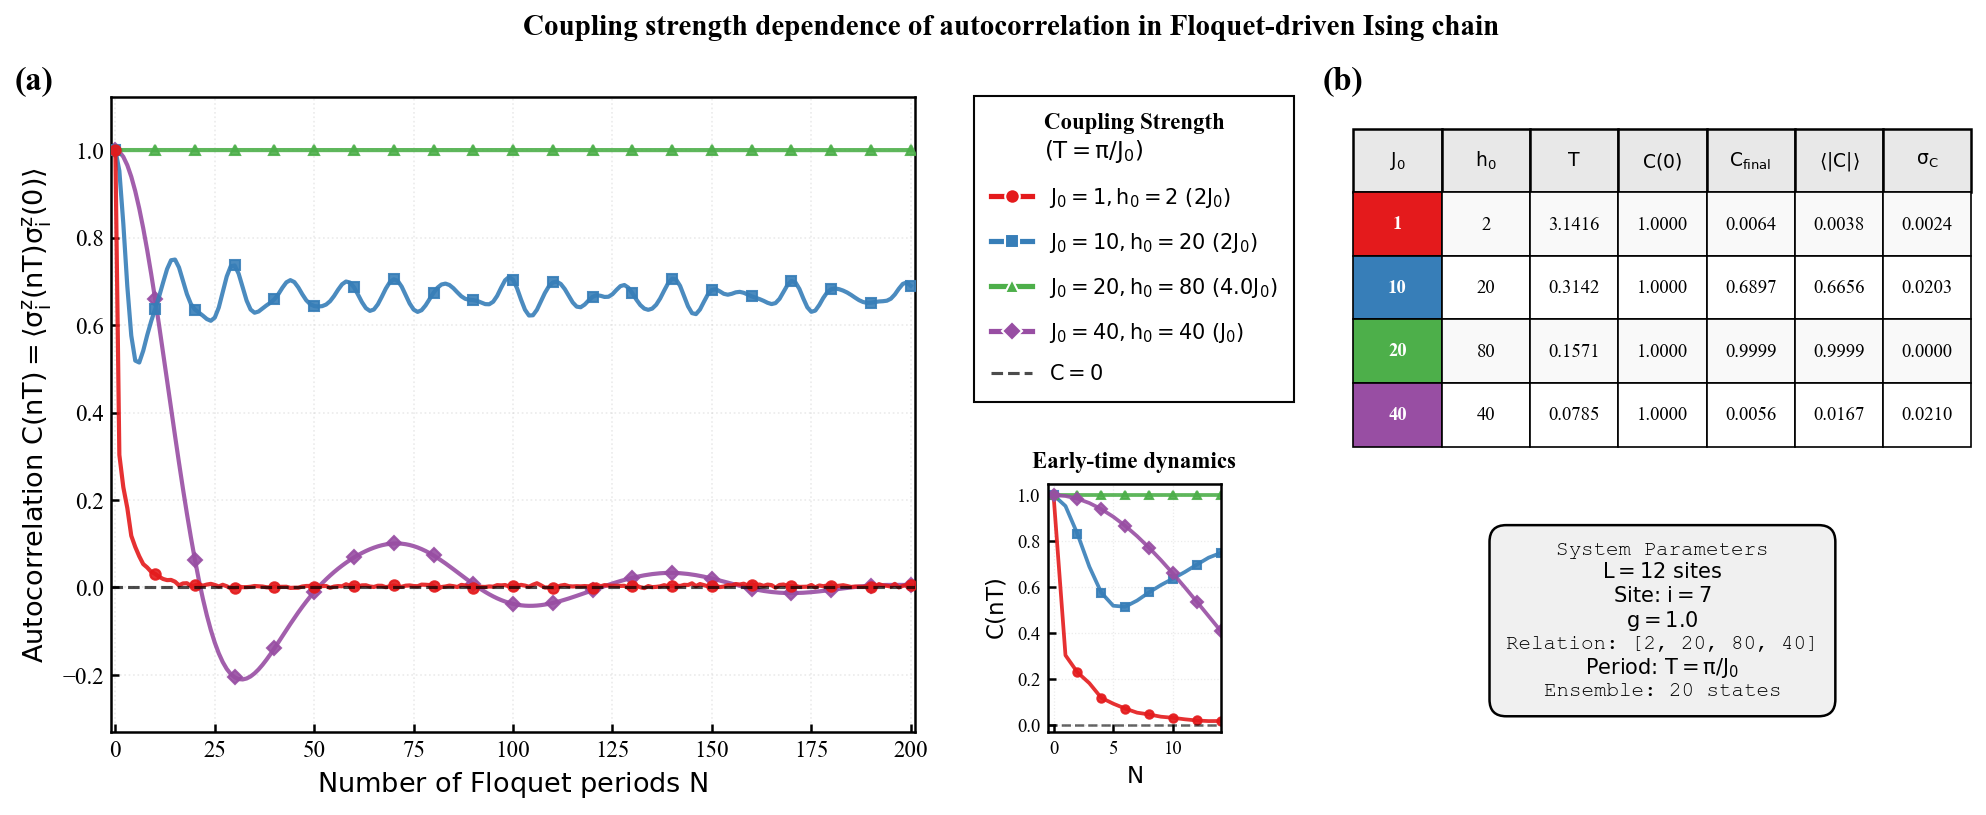


COUPLING STRENGTH DEPENDENCE STATISTICS

--------------------------------------------------------------------------------
J_0 = 1, h_0 = 2, T = 3.141593
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.006366
  Range: [-0.004129, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.003844
    Std(C) = 0.002362

--------------------------------------------------------------------------------
J_0 = 10, h_0 = 20, T = 0.314159
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.689691
  Range: [0.514314, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.665647
    Std(C) = 0.020325

--------------------------------------------------------------------------------
J_0 = 20, h_0 = 80, T = 0.157080
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.999857
  Range: [0.999857, 1.000000]
  Steady-state (n>100)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec




# ============================================
# PLOTTING FUNCTION
# ============================================

def plot_autocorr_coupling_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for different coupling strengths.
    Format matches the period and site comparison plots.

    Parameters:
    -----------
    results_dict : dict
        Dictionary with J_0 values as keys
    base_params : dict
        Base system parameters
    """

    J_0_values = sorted(results_dict.keys())

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
        'legend.borderpad': 0.5,
        'legend.columnspacing': 1.0,
    })

    # Professional color palette
    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#A65628']
    markers = ['o', 's', '^', 'D', 'v', 'P']
    linestyles = ['-', '-', '-', '-', '-', '-']

    # Create figure with custom layout
    fig = plt.figure(figsize=(16, 5.5), dpi=150)

    # Create nested GridSpec
    gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.3, 0.28, 1], wspace=0.25)

    # Main plot
    ax1 = plt.subplot(gs_main[0])

    # Middle panel subdivided
    gs_middle = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1],
                                                  height_ratios=[0.55, 0.45], hspace=0.3)
    ax_legend = plt.subplot(gs_middle[0])
    ax_legend.axis('off')

    ax_early = plt.subplot(gs_middle[1])

    # Statistics panel
    ax2 = plt.subplot(gs_main[2])

    # ============================================
    # PANEL A: Autocorrelation vs Periods
    # ============================================

    max_periods = max([len(results_dict[J_0]['C_avg']) for J_0 in J_0_values])

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        h_0 = data['h_0']
        ratio = data['ratio']

        # Create label
        if ratio == 2.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(2J_0)$'
        elif ratio == 1.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(J_0)$'
        else:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $({ratio:.1f}J_0)$'

        ax1.plot(periods, C_avg,
                marker=markers[idx],
                color=colors[idx],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[idx],
                zorder=5-idx)

    # Add zero line
    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.5, alpha=0.7, zorder=10)

    # Formatting
    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel(r"Autocorrelation $C(nT) = \langle \sigma^z_i(nT) \sigma^z_i(0) \rangle$",
                   fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    # Set y-limits
    all_data = np.concatenate([np.real(results_dict[J_0]['C_avg']) for J_0 in J_0_values])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax1.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

    # Grid
    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    # Panel label
    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # LEGEND PANEL
    # ============================================

    from matplotlib.lines import Line2D
    legend_elements = []
    legend_labels = []

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        h_0 = data['h_0']
        ratio = data['ratio']

        if ratio == 2.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(2J_0)$'
        elif ratio == 1.0:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $(J_0)$'
        else:
            label = f'$J_0={J_0:.0f}, h_0={h_0:.0f}$ $({ratio:.1f}J_0)$'

        legend_elements.append(Line2D([0], [0], color=colors[idx],
                                     linewidth=2.5, marker=markers[idx],
                                     markersize=7, markeredgecolor='white', markeredgewidth=1))
        legend_labels.append(label)

    # Add zero line
    legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5,
                                  linestyle='--', alpha=0.7))
    legend_labels.append('$C=0$')

    # Place legend
    legend = ax_legend.legend(legend_elements, legend_labels,
                             loc='center',
                             fontsize=10,
                             frameon=True,
                             framealpha=0.98,
                             edgecolor='black',
                             fancybox=False,
                             title='Coupling Strength\n$(T=\\pi/J_0)$',
                             title_fontsize=11,
                             labelspacing=1.0,
                             borderpad=0.8)
    legend.get_title().set_weight('bold')

    # ============================================
    # EARLY DYNAMICS PANEL
    # ============================================

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        ax_early.plot(periods[:15], C_avg[:15],
                     marker=markers[idx], color=colors[idx],
                     linewidth=1.8, markersize=4,
                     markevery=2, alpha=0.9)

    ax_early.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax_early.set_xlabel("$N$", fontsize=11, fontweight='normal')
    ax_early.set_ylabel("$C(nT)$", fontsize=11, fontweight='normal')
    ax_early.set_title("Early-time dynamics", fontsize=11, fontweight='bold', pad=8)
    ax_early.tick_params(labelsize=9, direction='in')
    ax_early.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
    ax_early.set_xlim(-0.5, 14)

    for spine in ax_early.spines.values():
        spine.set_linewidth(1.2)

    # ============================================
    # PANEL B: Statistics Table
    # ============================================

    ax2.axis('off')

    # Create table
    table_data = []
    headers = ['$J_0$', '$h_0$', '$T$', '$C(0)$', '$C_{final}$',
               '$\\langle|C|\\rangle$', '$\\sigma_C$']

    n_start = 100

    for idx, J_0 in enumerate(J_0_values):
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])
        C_initial = C_avg[0]
        C_final = C_avg[-1]

        # Statistics
        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        table_data.append([
            f'{J_0:.0f}',
            f'{h_0:.0f}',
            f'{T:.4f}',
            f'{C_initial:.4f}',
            f'{C_final:.4f}',
            f'{mean_abs:.4f}',
            f'{std_C:.4f}'
        ])

    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.45, 1.0, 0.50])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)

    # Header styling
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=9)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    # Data cells styling
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            # Color code by J_0
            if j == 0:  # J_0 column
                cell.set_facecolor(colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    # System parameters box
    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"Site: $i = {base_params['site_i']+1}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"Relation: {base_params['h_0_relation']}\n"
    param_text += f"Period: $T = \\pi/J_0$\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax2.text(0.5, 0.30, param_text, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    # Panel label
    ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle("Coupling strength dependence of autocorrelation in Floquet-driven Ising chain",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save
    plt.savefig('floquet_autocorr_coupling.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('floquet_autocorr_coupling.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved publication-quality figures:")
    print("  - floquet_autocorr_coupling.pdf")
    print("  - floquet_autocorr_coupling.png")

    plt.show()

    # Detailed statistics
    print("\n" + "="*80)
    print("COUPLING STRENGTH DEPENDENCE STATISTICS")
    print("="*80)

    for J_0 in J_0_values:
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])

        print(f"\n{'-'*80}")
        print(f"J_0 = {J_0}, h_0 = {h_0}, T = {T:.6f}")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  Range: [{np.min(C_avg):.6f}, {np.max(C_avg):.6f}]")

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            print(f"  Steady-state (n>{n_start}):")
            print(f"    Mean |C| = {np.mean(np.abs(C_steady)):.6f}")
            print(f"    Std(C) = {np.std(C_steady):.6f}")

    print("\n" + "="*80)
    print("COMPARATIVE ANALYSIS")
    print("="*80)
    print(f"{'J_0':<10} {'h_0':<10} {'Period T':<15} {'Mean |C|':<15} {'Std(C)':<15}")
    print("-"*65)

    for J_0 in J_0_values:
        data = results_dict[J_0]
        h_0 = data['h_0']
        T = data['T']
        C_avg = np.real(data['C_avg'])

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        print(f"{J_0:<10.0f} {h_0:<10.0f} {T:<15.6f} {mean_abs:<15.6f} {std_C:<15.6f}")

    print("="*80)

    plt.rcParams.update(plt.rcParamsDefault)



# Create publication plot
print("\n" + "="*80)
print("CREATING PUBLICATION-QUALITY PLOT")
print("="*80)
plot_autocorr_coupling_comparison(results, params)

### Plots code for publication

Figure saved to: autocorr_coupling_comparison.pdf


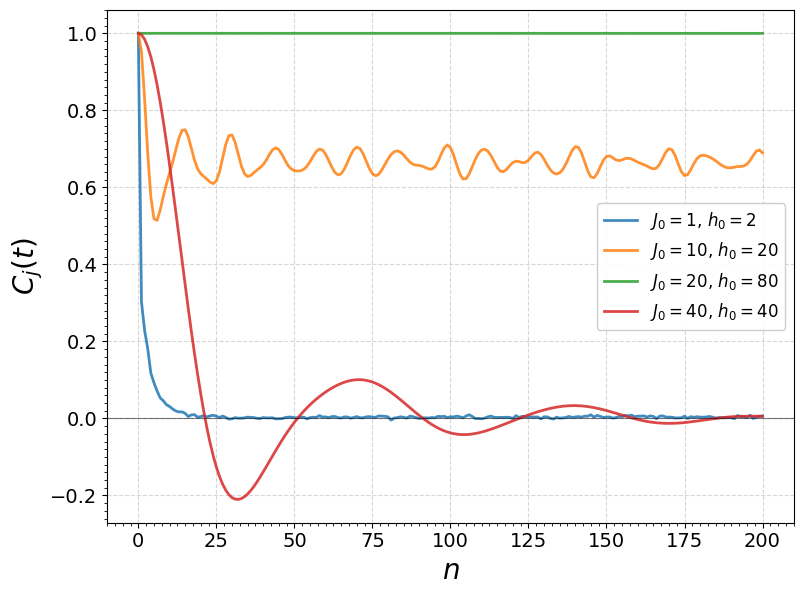

In [80]:
from matplotlib.ticker import StrMethodFormatter
from matplotlib import style
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as tck
from matplotlib import rc, rcParams
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import pickle
import matplotlib
import glob
import matplotlib.pyplot as plt
import glob



def plot_autocorr_coupling_pub(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation vs coupling strength.

    Parameters:
    -----------
    results : dict
        Results dictionary containing times, C_avg, J_0, h_0, T, ratio for each J_0
    params : dict
        Parameter dictionary containing L, site_i, g, num_states, h_0_relation
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for different J_0 values
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    # Line properties
    linewidth = 2.0
    alpha = 0.85

    # Grid properties
    show_grid = True
    grid_alpha = 0.5
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # J_0 values in order
    J_0_values = sorted(results.keys())

    # Plot each J_0 value
    for idx, J_0 in enumerate(J_0_values):
        times = results[J_0]['times']
        C_avg = np.real(results[J_0]['C_avg'])
        h_0 = results[J_0]['h_0']
        periods = np.arange(len(C_avg))

        # Plot period number vs autocorrelation
        ax.plot(periods, C_avg,
                label=f'$J_0 = {J_0}$, $h_0 = {h_0}$',
                color=colors[idx % len(colors)],
                linewidth=linewidth,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(10))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate plot
fig_coupling, ax_coupling = plot_autocorr_coupling_pub(
    results,
    params,
    save_path='autocorr_coupling_comparison.pdf'
)

## $C_i(t)$ w.r.t different time periods

### Results code

In [24]:
import numpy as np
import time

# ============================================================================
# PERIOD COMPARISON WITH BATCH SIZE CONTROL
# ============================================================================

def run_autocorr_period_comparison(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    site_i=3,
    period_factors=[0.25, 0.5, 1, 2, 3, 4],
    n_periods=500,
    num_states=20,
    batch_size=None,
    seed=42,
    tol=1e-10,
    store_all=True,
    verbose=True
):
    """
    Run autocorrelation analysis for multiple periods.

    Uses Krylov-based batched two-ket method (no dense matrices).

    Parameters
    ----------
    L : int
        Chain length.
    J_0, h_0, g : float
        Hamiltonian parameters.
    site_i : int
        Site index for σ^z measurement.
    period_factors : list
        List of n values where T = n*π/J_0.
    n_periods : int
        Number of Floquet periods to evolve.
    num_states : int
        Number of random initial states for ensemble averaging.
    batch_size : int or None
        Number of states to process in parallel per block.
        If None, auto-selects min(50, num_states).
        Larger batch_size = faster but more memory.
    seed : int
        Random seed for reproducibility.
    tol : float
        Tolerance for Krylov time evolution.
    store_all : bool
        If True, store individual C(t) for each state.
        If False, only store ensemble average (saves memory).
    verbose : bool
        Print progress updates.

    Returns
    -------
    results_dict : dict
        Dictionary with period factors as keys, each containing:
        {'times': array, 'C_avg': array, 'C_all': array (if store_all), 'T': float}
    base_params : dict
        System parameters.
    """

    # Auto batch size
    if batch_size is None:
        batch_size = min(50, num_states)

    results_dict = {}
    total_start = time.time()

    # Estimate total work
    n_blocks_per_factor = (num_states + batch_size - 1) // batch_size
    total_block_periods = len(period_factors) * n_blocks_per_factor * (n_periods + 1)

    if verbose:
        print("=" * 70)
        print("AUTOCORRELATION PERIOD COMPARISON (BATCHED)")
        print("=" * 70)
        print(f"System Parameters:")
        print(f"  L = {L}, Ns = {2**L:,}")
        print(f"  J_0 = {J_0}, h_0 = {h_0}, g = {g}")
        print(f"  site_i = {site_i}")
        print(f"  Period factors: {period_factors}")
        print(f"  n_periods = {n_periods:,}")
        print(f"  num_states = {num_states}, batch_size = {batch_size}")
        print(f"  store_all = {store_all}")
        print(f"  Method: Krylov two-ket (batched)")
        print("=" * 70)

    for idx, n in enumerate(period_factors):
        TP = n * np.pi / J_0

        if verbose:
            print(f"\n{'─'*70}")
            print(f"[{idx+1}/{len(period_factors)}] Computing T = {n}π/J₀ = {TP:.6f}")
            print(f"{'─'*70}")

        step_start = time.time()

        # Initialize system
        ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
        ising.build_hamiltonians()

        # Create Krylov-based operators
        apply_U = make_floquet_propagator(ising, tol=tol)
        apply_sigma_z = make_sigma_z_matvec(ising, site_i=site_i)

        # Generate random states as matrix
        random_states = generate_random_states(
            ising.Ns,
            num_states=num_states,
            seed=seed,
            verbose=False,
            return_format='matrix'
        )

        # Compute ensemble average using batched two-ket method
        result = compute_ensemble_average_batched(
            random_states,
            apply_U,
            apply_sigma_z,
            n_periods=n_periods,
            batch_size=batch_size,
            store_all=store_all,
            return_real=True,
            verbose=verbose
        )

        # Unpack result based on store_all
        if store_all:
            times, C_avg, C_all = result
        else:
            times, C_avg = result
            C_all = None

        step_time = time.time() - step_start

        # Store results
        results_dict[n] = {
            'times': times,
            'C_avg': C_avg,
            'T': TP
        }

        if store_all and C_all is not None:
            results_dict[n]['C_all'] = C_all

        # Progress summary
        if verbose:
            elapsed_total = time.time() - total_start
            completed = idx + 1
            remaining = len(period_factors) - completed
            eta = (elapsed_total / completed) * remaining if completed > 0 else 0

            print(f"\n  ✓ Period factor {n} complete in {step_time:.1f}s")
            print(f"    C(0) = {C_avg[0]:.6f}, C({n_periods}) = {C_avg[-1]:.6f}")
            print(f"    Overall: {completed}/{len(period_factors)} | ETA: {eta:.0f}s")

    total_time = time.time() - total_start

    base_params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'site_i': site_i,
        'num_states': num_states,
        'batch_size': batch_size,
        'n_periods': n_periods,
        'store_all': store_all,
        'method': 'krylov_two_ket_batched'
    }

    if verbose:
        print("\n" + "=" * 70)
        print("COMPUTATION COMPLETE")
        print(f"  Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
        print(f"  Average per period factor: {total_time/len(period_factors):.1f}s")
        print("=" * 70)

    return results_dict, base_params


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 70)
print("SECTION J: PERIOD COMPARISON (BATCHED)")
print("=" * 70)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║                        TUNABLE PARAMETERS                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

L = 12                                     # Chain length
J_0 = 10.0                                 # Ising coupling strength
h_0 = 20.0                                 # Longitudinal field strength
g = 1.0                                    # Transverse field strength
period_factors = [0.5, 1.0, 1.5, 2.0]      # Period factors: T = n*π/J_0
site_i = L // 2                            # Bulk site
n_periods = 200                            # Number of Floquet periods
num_states = 20                            # Ensemble size
batch_size = 1                            # States processed in parallel (None=auto)
seed = 42                                  # Random seed
store_all = True                           # Store individual traces

# ============================================================================

print(f"\n{'='*70}")
print("PARAMETERS")
print(f"{'='*70}")
print(f"  L = {L} (Ns = {2**L:,})")
print(f"  J_0 = {J_0}, h_0 = {h_0}, g = {g}")
print(f"  period_factors = {period_factors}")
print(f"  site_i = {site_i} (bulk)")
print(f"  n_periods = {n_periods}")
print(f"  num_states = {num_states}, batch_size = {batch_size}")
print(f"  store_all = {store_all}")

# Estimate memory
Ns = 2**L
state_mem = 2 * Ns * batch_size * 16 / 1e6  # Two kets per batch
print(f"\nEstimated memory per batch:")
print(f"  State vectors (2 kets × batch): {state_mem:.1f} MB")

# ========== BULK SITE ==========
print(f"\n{'#'*70}")
print(f"# BULK SITE: i = {site_i}")
print(f"{'#'*70}")

results_bulk, params_bulk = run_autocorr_period_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    site_i=site_i,
    period_factors=period_factors,
    n_periods=n_periods,
    num_states=num_states,
    batch_size=batch_size,
    seed=seed,
    store_all=store_all,
    verbose=True
)

# ========== EDGE SITE ==========

site_edge = L - 1

print(f"\n{'#'*70}")
print(f"# EDGE SITE: i = {site_edge}")
print(f"{'#'*70}")

results_edge, params_edge = run_autocorr_period_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    site_i=site_edge,
    period_factors=period_factors,
    n_periods=n_periods,
    num_states=num_states,
    batch_size=batch_size,
    seed=seed,
    store_all=store_all,
    verbose=True
)


# ========== VERIFY OUTPUT FORMAT ==========
print(f"\n{'='*70}")
print("OUTPUT VERIFICATION")
print(f"{'='*70}")

print(f"\nBulk results keys: {list(results_bulk.keys())}")
print(f"base_params: {params_bulk}")

sample_n = period_factors[0]
sample = results_bulk[sample_n]
print(f"\nSample result for T = {sample_n}π/J₀:")
print(f"  times: shape {sample['times'].shape}")
print(f"  C_avg: shape {sample['C_avg'].shape}")
print(f"  C_avg(0) = {sample['C_avg'][0]:.6f} (should be ~1.0)")
print(f"  C_avg(end) = {sample['C_avg'][-1]:.6f}")
if 'C_all' in sample:
    print(f"  C_all: shape {sample['C_all'].shape}")
print(f"  T = {sample['T']:.6f}")

print(f"\n{'='*70}")
print("✓ SECTION J COMPLETE - Ready for plotting")
print(f"{'='*70}")

Streaming output truncated to the last 5000 lines.
    Progress:  35.7% | Block 8/20, Period 27/201 | ETA: 581s
    Progress:  35.9% | Block 8/20, Period 36/201 | ETA: 579s
    Progress:  36.1% | Block 8/20, Period 46/201 | ETA: 576s
    Progress:  36.4% | Block 8/20, Period 56/201 | ETA: 574s
    Progress:  36.6% | Block 8/20, Period 65/201 | ETA: 572s
    Progress:  36.8% | Block 8/20, Period 74/201 | ETA: 570s
    Progress:  37.1% | Block 8/20, Period 84/201 | ETA: 568s
    Progress:  37.3% | Block 8/20, Period 93/201 | ETA: 566s
    Progress:  37.5% | Block 8/20, Period 102/201 | ETA: 564s
    Progress:  37.8% | Block 8/20, Period 111/201 | ETA: 563s
    Progress:  38.0% | Block 8/20, Period 120/201 | ETA: 561s
    Progress:  38.2% | Block 8/20, Period 129/201 | ETA: 559s
    Progress:  38.4% | Block 8/20, Period 138/201 | ETA: 557s
    Progress:  38.7% | Block 8/20, Period 147/201 | ETA: 555s
    Progress:  38.9% | Block 8/20, Period 156/201 | ETA: 553s
    Progress:  39.1% | Bloc

### Saving results

In [33]:

# ============================================================================
# HELPER: Generate descriptive filename for period comparison
# ============================================================================

def make_period_scan_filename(base_params, site_type='bulk'):
    """
    Generate a descriptive filename for period comparison results.

    Encodes: scan_type, L, J_0, h_0, site_type, site_i, n_periods, num_states.

    Parameters
    ----------
    base_params : dict
        From run_autocorr_period_comparison. Must contain:
        'L', 'J_0', 'h_0', 'site_i', 'n_periods', 'num_states'.
    site_type : str
        'bulk' or 'edge' — appears in the filename.

    Returns
    -------
    filename : str
        Descriptive filename (without extension).

    Examples
    --------
    >>> params = {'L': 12, 'J_0': 10.0, 'h_0': 20.0, 'site_i': 6,
    ...           'n_periods': 200, 'num_states': 20}
    >>> make_period_scan_filename(params, 'bulk')
    'period_scan_L12_J10_h20_bulk_i6_n200_Ns20'
    """
    L = base_params['L']
    J_0 = base_params['J_0']
    h_0 = base_params['h_0']
    site_i = base_params['site_i']
    n_per = base_params['n_periods']
    n_st = base_params['num_states']

    # Format J_0 and h_0: use integer if whole number, else 1 decimal
    J_str = f"{J_0:.0f}" if J_0 == int(J_0) else f"{J_0:.1f}"
    h_str = f"{h_0:.0f}" if h_0 == int(h_0) else f"{h_0:.1f}"

    filename = f"period_scan_L{L}_J{J_str}_h{h_str}_{site_type}_i{site_i}_n{n_per}_Ns{n_st}"
    return filename




# ============================================================================
# HELPER: Generate descriptive filename for site comparison
# ============================================================================

def make_site_scan_filename(base_params, period_factor):
    """
    Generate a descriptive filename for site comparison results.

    Parameters
    ----------
    base_params : dict
        From run_autocorr_site_comparison.
    period_factor : float
        The period factor n where T = n*π/J_0.

    Returns
    -------
    filename : str
        Descriptive filename (without extension).
    """
    L = base_params.get('L', 0)
    J_0 = base_params.get('J_0', 0)
    h_0 = base_params.get('h_0', 0)
    n_per = base_params.get('n_periods', 0)
    n_st = base_params.get('num_states', 0)

    J_str = f"{J_0:.0f}" if J_0 == int(J_0) else f"{J_0:.1f}"
    h_str = f"{h_0:.0f}" if h_0 == int(h_0) else f"{h_0:.1f}"
    pf_str = f"{period_factor:.0f}" if period_factor == int(period_factor) else f"{period_factor}"

    filename = f"site_scan_L{L}_J{J_str}_h{h_str}_pf{pf_str}_n{n_per}_Ns{n_st}"
    return filename


# ============================================================================
# ============================================================================
#
#      SECTION 1: SAVE BLOCK FOR PERIOD COMPARISON RESULTS
#
#      PASTE THIS INTO A COLAB CELL after run_autocorr_period_comparison
#      produces: results_bulk, params_bulk, results_edge, params_edge.
#
# ============================================================================
# ============================================================================

print("=" * 70)
print("SAVING PERIOD COMPARISON RESULTS")
print("=" * 70)
#
# # ╔═══════════════════════════════════════════════════════════════════════════╗
# # ║                        SAVE PARAMETERS                                   ║
# # ╚═══════════════════════════════════════════════════════════════════════════╝
#
save_format = 'pkl'           # 'npz' or 'pkl' (pkl recommended for exact structure)
save_dir = '.'                # Directory to save (current directory)
#
# # ============================================================================
# # NOTE: The filename is auto-generated from physics parameters.
# #       Override by setting filename_bulk / filename_edge to a string.
# #       Set to None for auto-generated descriptive filenames.
# # ============================================================================
filename_bulk = None          # None = auto-generate from params
filename_edge = None          # None = auto-generate from params
#
# # ============================================================================
#
# # ---------- Augment base_params with scan metadata ----------
# # run_autocorr_period_comparison doesn't store period_factors or scan_type
# # in base_params. We add them here before saving so the file is self-describing.
#
params_bulk['scan_type'] = 'period_comparison'
params_bulk['period_factors'] = period_factors
params_bulk['site_type'] = 'bulk'

params_edge['scan_type'] = 'period_comparison'
params_edge['period_factors'] = period_factors
params_edge['site_type'] = 'edge'
#
# # ---------- Generate descriptive filenames ----------
if filename_bulk is None:
     filename_bulk = make_period_scan_filename(params_bulk, site_type='bulk')
#
if filename_edge is None:
     filename_edge = make_period_scan_filename(params_edge, site_type='edge')
#
# # ---------- Verify filenames are distinct ----------
assert filename_bulk != filename_edge, (
     f"Bulk and edge filenames are identical: '{filename_bulk}'. "
     f"This would cause the second save to overwrite the first."
 )
#
print(f"\nFilenames:")
print(f"  Bulk: {filename_bulk}.{save_format}")
print(f"  Edge: {filename_edge}.{save_format}")
#
# # ---------- Save bulk results ----------
filepath_bulk = save_autocorr_results(
     results_dict=results_bulk,
     base_params=params_bulk,
     filename=filename_bulk,
     save_dir=save_dir,
     format=save_format,
     verbose=True
 )
#
# # ---------- Save edge results ----------
filepath_edge = save_autocorr_results(
     results_dict=results_edge,
     base_params=params_edge,
     filename=filename_edge,
     save_dir=save_dir,
     format=save_format,
     verbose=True
 )
#
# # ---------- Download for Colab ----------
download_file_colab(filepath_bulk)
download_file_colab(filepath_edge)
#
print(f"\n{'='*70}")
print("✓ PERIOD COMPARISON SAVE COMPLETE")
print(f"  Bulk: {filepath_bulk}")
print(f"  Edge: {filepath_edge}")
print(f"{'='*70}")



SAVING PERIOD COMPARISON RESULTS

Filenames:
  Bulk: period_scan_L12_J10_h20_bulk_i6_n200_Ns20.pkl
  Edge: period_scan_L12_J10_h20_edge_i11_n200_Ns20.pkl

RESULTS SAVED
  File: .\period_scan_L12_J10_h20_bulk_i6_n200_Ns20.pkl
  Size: 139.2 KB
  Format: pkl
  Keys: [0.5, 1.0, 1.5, 2.0]

RESULTS SAVED
  File: .\period_scan_L12_J10_h20_edge_i11_n200_Ns20.pkl
  Size: 139.2 KB
  Format: pkl
  Keys: [0.5, 1.0, 1.5, 2.0]
Not running in Colab. File saved at: .\period_scan_L12_J10_h20_bulk_i6_n200_Ns20.pkl
Not running in Colab. File saved at: .\period_scan_L12_J10_h20_edge_i11_n200_Ns20.pkl

✓ PERIOD COMPARISON SAVE COMPLETE
  Bulk: .\period_scan_L12_J10_h20_bulk_i6_n200_Ns20.pkl
  Edge: .\period_scan_L12_J10_h20_edge_i11_n200_Ns20.pkl


### Plots code for presentations

FLOQUET AUTOCORRELATION: PERIOD COMPARISON

CREATING BULK SITE FIGURES


C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\4274211156.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_periods_site6.pdf
  - floquet_autocorr_periods_site6.png


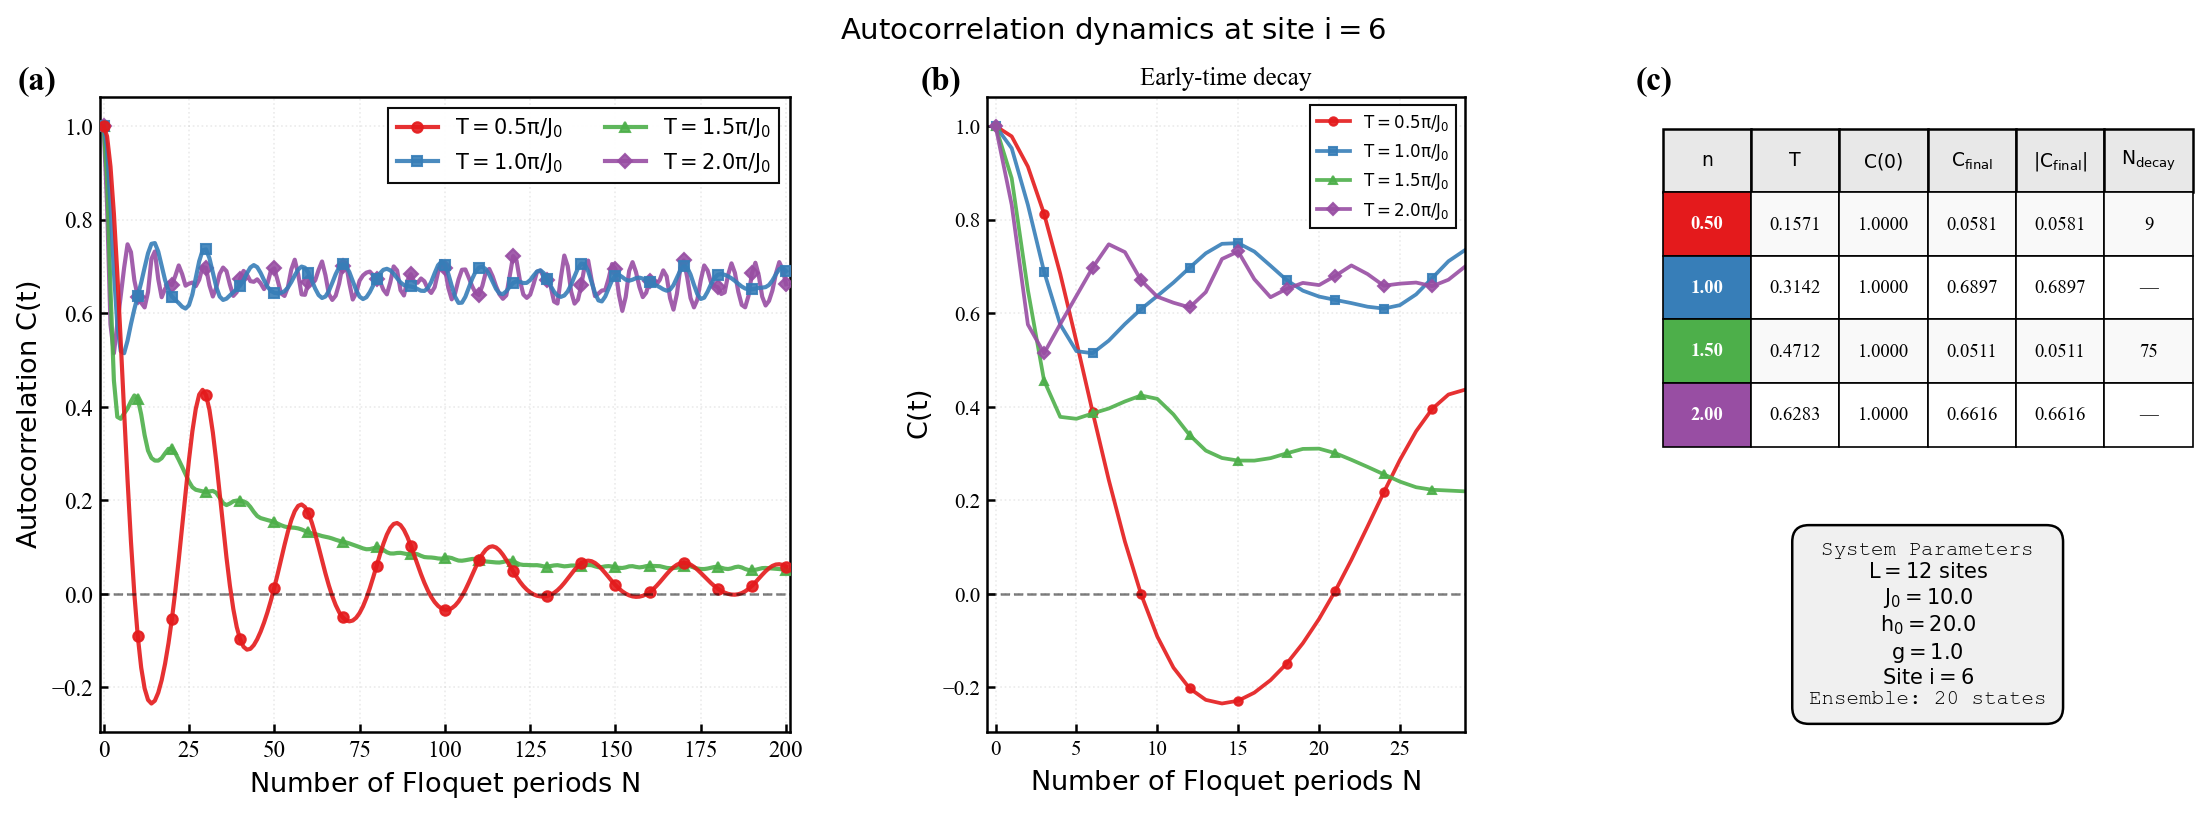


DETAILED STATISTICS

--------------------------------------------------------------------------------
Period factor n = 0.5: T = 0.5π/J₀ = 0.157080
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.058081
  |C(final)| = 0.058081
  Mean |C| = 0.100903
  Decay benchmarks:
    |C| < 0.1: N =   9 periods (t =   9.00)
    |C| < 0.05: N =   9 periods (t =   9.00)

--------------------------------------------------------------------------------
Period factor n = 1.0: T = 1.0π/J₀ = 0.314159
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.689691
  |C(final)| = 0.689691
  Mean |C| = 0.667883
  Decay benchmarks:

--------------------------------------------------------------------------------
Period factor n = 1.5: T = 1.5π/J₀ = 0.471239
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.051089
  |C(final)

C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\4274211156.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_periods_site11.pdf
  - floquet_autocorr_periods_site11.png


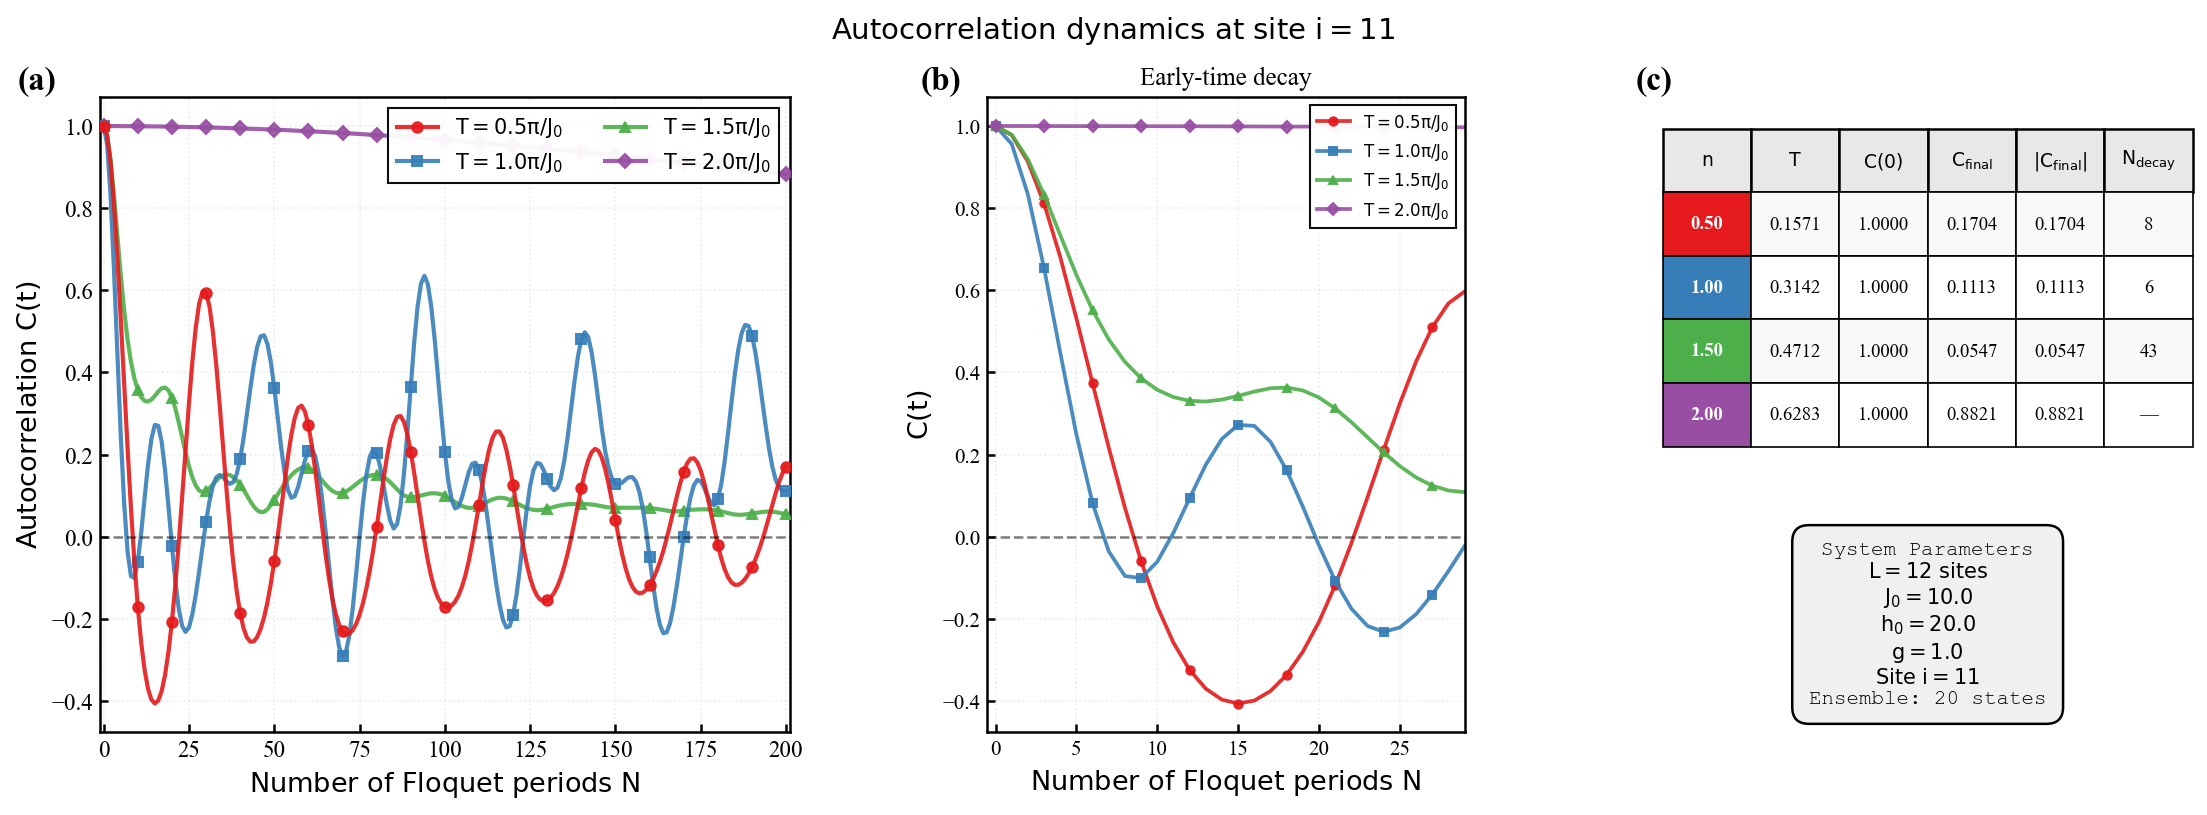


DETAILED STATISTICS

--------------------------------------------------------------------------------
Period factor n = 0.5: T = 0.5π/J₀ = 0.157080
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.170385
  |C(final)| = 0.170385
  Mean |C| = 0.183232
  Decay benchmarks:
    |C| < 0.1: N =   8 periods (t =   8.00)
    |C| < 0.05: N =  22 periods (t =  22.00)

--------------------------------------------------------------------------------
Period factor n = 1.0: T = 1.0π/J₀ = 0.314159
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.111327
  |C(final)| = 0.111327
  Mean |C| = 0.214608
  Decay benchmarks:
    |C| < 0.1: N =   6 periods (t =   6.00)
    |C| < 0.05: N =   7 periods (t =   7.00)

--------------------------------------------------------------------------------
Period factor n = 1.5: T = 1.5π/J₀ = 0.471239
-------------------------------------------

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec

def plot_autocorr_period_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for autocorrelation at different periods.
    Three-panel layout:
      (a) Full autocorrelation C(t) vs Floquet periods N
      (b) Early-time decay (first 30 periods) — standalone panel
      (c) Statistics table + system parameters
    """
    period_factors = sorted(results_dict.keys())
    site_i = base_params['site_i']

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
    })

    # Professional color palette
    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#A65628']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    linestyles = ['-', '-', '-', '-', '-', '-']

    # ============================================
    # FIGURE LAYOUT: 3 panels in a single row
    #   (a) wide  |  (b) medium  |  (c) medium
    # ============================================
    fig = plt.figure(figsize=(18, 5.5), dpi=150)
    gs = gridspec.GridSpec(1, 3, width_ratios=[1.3, 0.9, 1.0], wspace=0.35)

    ax1 = plt.subplot(gs[0])   # Full autocorrelation
    ax2 = plt.subplot(gs[1])   # Early-time decay (was inset)
    ax3 = plt.subplot(gs[2])   # Statistics table

    # ============================================
    # PANEL (a): Autocorrelation vs Number of Periods
    # ============================================

    max_periods = max([len(results_dict[n]['C_avg']) for n in period_factors])

    for i, n in enumerate(period_factors):
        data = results_dict[n]
        times = data['times']
        C_avg = np.real(data['C_avg'])
        T = data['T']
        periods = np.arange(len(C_avg))

        label = f'$T = {n}\\pi/J_0$'
        ax1.plot(periods, C_avg,
                marker=markers[i],
                color=colors[i],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[i],
                zorder=6-i)

    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.2, alpha=0.5, zorder=10)

    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel("Autocorrelation $C(t)$", fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    legend = ax1.legend(loc='upper right', fontsize=10, ncol=2,
                       framealpha=0.95, edgecolor='black', fancybox=False)
    legend.set_zorder(20)

    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # PANEL (b): Early-time decay (standalone)
    # ============================================

    N_early = 30  # Number of early periods to show

    for i, n in enumerate(period_factors):
        data = results_dict[n]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))

        n_pts = min(N_early, len(C_avg))
        label = f'$T = {n}\\pi/J_0$'
        ax2.plot(periods[:n_pts], C_avg[:n_pts],
                marker=markers[i], color=colors[i],
                linewidth=1.8, markersize=4,
                markevery=3, alpha=0.9,
                linestyle=linestyles[i],
                label=label)

    ax2.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax2.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax2.set_ylabel("$C(t)$", fontsize=13, fontweight='normal')
    ax2.set_title("Early-time decay", fontsize=12, pad=6)
    ax2.tick_params(labelsize=10)
    ax2.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)
    ax2.set_xlim(-0.5, N_early - 1)

    legend2 = ax2.legend(loc='upper right', fontsize=8, ncol=1,
                        framealpha=0.95, edgecolor='black', fancybox=False)
    legend2.set_zorder(20)

    ax2.text(-0.14, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # PANEL (c): Statistics Table and Info
    # ============================================

    ax3.axis('off')

    table_data = []
    headers = ['$n$', '$T$', '$C(0)$', '$C_{final}$',
               '$|C_{final}|$', '$N_{decay}$']

    for n in period_factors:
        data = results_dict[n]
        T = data['T']
        C_avg = np.real(data['C_avg'])
        C_0 = C_avg[0]
        C_final = C_avg[-1]

        idx_decay = np.where(np.abs(C_avg) < 0.1)[0]
        N_decay = idx_decay[0] if len(idx_decay) > 0 else -1

        table_data.append([
            f'{n:.2f}',
            f'{T:.4f}',
            f'{C_0:.4f}',
            f'{C_final:.4f}',
            f'{np.abs(C_final):.4f}',
            f'{N_decay}' if N_decay >= 0 else '—'
        ])

    table = ax3.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.45, 1.0, 0.50])

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)

    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=9)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            if j == 0:
                cell.set_facecolor(colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"$J_0 = {base_params['J_0']:.1f}$\n"
    param_text += f"$h_0 = {base_params['h_0']:.1f}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"Site $i = {base_params['site_i']}$\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax3.text(0.5, 0.30, param_text, transform=ax3.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    ax3.text(-0.05, 1.05, '(c)', transform=ax3.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle(f"Autocorrelation dynamics at site $i = {site_i}$",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save figures
    plt.savefig(f'floquet_autocorr_periods_site{site_i}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'floquet_autocorr_periods_site{site_i}.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved publication-quality figures:")
    print(f"  - floquet_autocorr_periods_site{site_i}.pdf")
    print(f"  - floquet_autocorr_periods_site{site_i}.png")

    plt.show()

    # ============================================
    # Detailed Statistics (unchanged)
    # ============================================

    print("\n" + "="*80)
    print("DETAILED STATISTICS")
    print("="*80)

    for n in period_factors:
        data = results_dict[n]
        times = data['times']
        C_avg = np.real(data['C_avg'])
        T = data['T']

        print(f"\n{'-'*80}")
        print(f"Period factor n = {n}: T = {n}π/J₀ = {T:.6f}")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  |C(final)| = {np.abs(C_avg[-1]):.6f}")
        print(f"  Mean |C| = {np.mean(np.abs(C_avg)):.6f}")

        idx_01 = np.where(np.abs(C_avg) < 0.1)[0]
        idx_005 = np.where(np.abs(C_avg) < 0.05)[0]

        print(f"  Decay benchmarks:")
        if len(idx_01) > 0:
            print(f"    |C| < 0.1: N = {idx_01[0]:3d} periods (t = {times[idx_01[0]]:6.2f})")
        if len(idx_005) > 0:
            print(f"    |C| < 0.05: N = {idx_005[0]:3d} periods (t = {times[idx_005[0]]:6.2f})")

    print("\n" + "="*80)

    # Reset matplotlib parameters
    plt.rcParams.update(plt.rcParamsDefault)


# ============================================
# MAIN EXECUTION
# ============================================

print("="*80)
print("FLOQUET AUTOCORRELATION: PERIOD COMPARISON")
print("="*80)


print("\n" + "="*80)
print("CREATING BULK SITE FIGURES")
print("="*80)

plot_autocorr_period_comparison(results_bulk, params_bulk)


print("\n" + "="*80)
print("CREATING EDGE SITE FIGURES")
print("="*80)

plot_autocorr_period_comparison(results_edge, params_edge)

print("\n" + "="*80)
print("ALL FIGURES GENERATED SUCCESSFULLY")
print("="*80)

### Plots for publication

Figure saved to: autocorr_bulk_site3.pdf


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

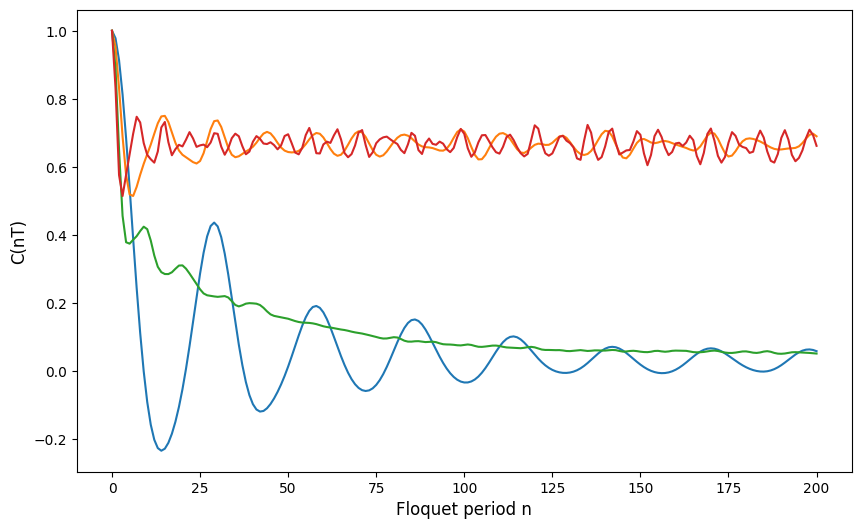

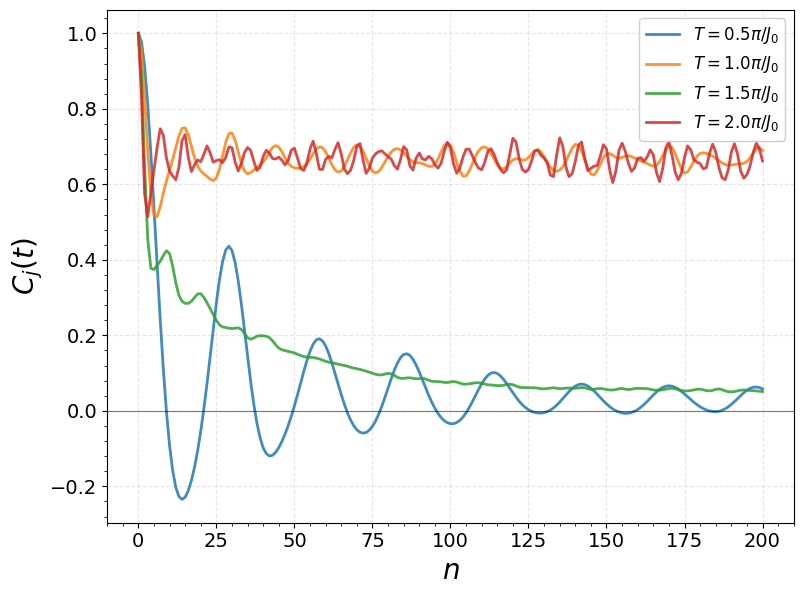

Figure saved to: autocorr_edge_site7.pdf


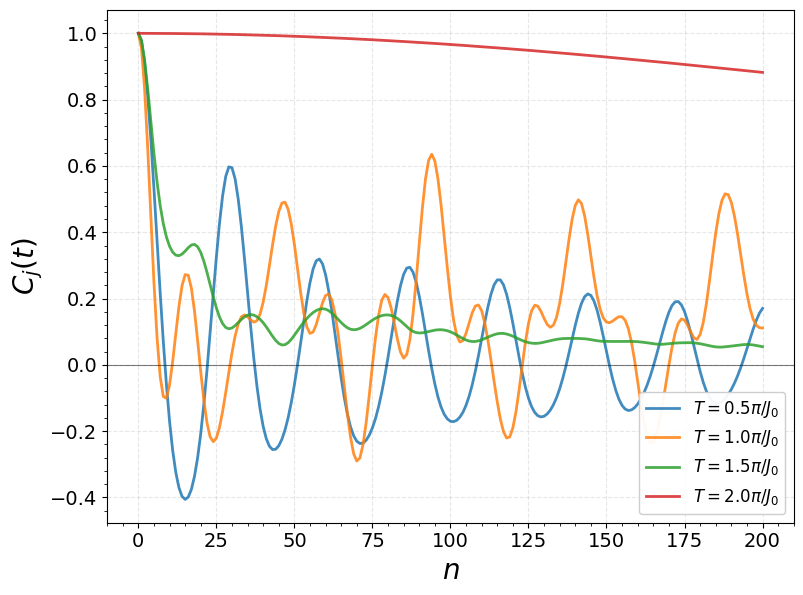

In [42]:
from matplotlib.ticker import StrMethodFormatter
from matplotlib import style
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as tck
from matplotlib import rc, rcParams
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import numpy as np
import pickle
import matplotlib
import glob
import matplotlib.pyplot as plt
import glob
def plot_autocorr_single(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation at a single site.

    Parameters:
    -----------
    results : dict
        Results dictionary containing times, C_avg, and T for each period factor
    params : dict
        Parameter dictionary containing L, J_0, h_0, g, site_i, num_states
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for different periods
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    # Line properties
    linewidth = 2.0
    alpha = 0.85

    # Grid properties
    show_grid = True
    grid_alpha = 0.3
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Period factors in order
    period_factors = sorted(results.keys())

    # Plot each period
    for idx, n in enumerate(period_factors):
        times = results[n]['times']
        C_avg = np.real(results[n]['C_avg'])
        periods = np.arange(len(C_avg))

        # Plot with time normalized by period
        ax.plot(periods, C_avg,
                label=f'$T = {n}\\pi/J_0$',
                color=colors[idx],
                linewidth=linewidth,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate bulk site plot
fig_bulk, ax_bulk = plot_autocorr_single(
    results_bulk,
    params_bulk,
    save_path='autocorr_bulk_site3.pdf'
)

# Generate edge site plot
fig_edge, ax_edge = plot_autocorr_single(
    results_edge,
    params_edge,
    save_path='autocorr_edge_site7.pdf'
)

## $C_i(t)$ w.r.t different sites i

### Results code

In [25]:
import numpy as np
import time

# ============================================================================
# SITE COMPARISON FUNCTION (BATCHED VERSION)
# ============================================================================

def run_autocorr_site_comparison(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1.0,
    edge_sites=None,
    bulk_sites=None,
    n_periods=1000,
    num_states=20,
    batch_size=None,
    seed=42,
    tol=1e-10,
    store_all=True,
    verbose=True
):
    """
    Compute autocorrelation for different sites (edge vs bulk).

    Uses Krylov-based batched two-ket method (no dense matrices).

    Parameters
    ----------
    L : int
        Chain length.
    J_0, h_0, g : float
        Hamiltonian parameters.
    period_factor : float
        Period factor n where T = n*π/J_0.
    edge_sites : list of int or None
        Edge site indices (0-indexed). If None, uses [0, L-1].
    bulk_sites : list of int or None
        Bulk site indices (0-indexed). If None, auto-selects center sites.
    n_periods : int
        Number of Floquet periods to evolve.
    num_states : int
        Number of random initial states for ensemble averaging.
    batch_size : int or None
        Number of states to process in parallel per block.
        If None, auto-selects min(50, num_states).
        Larger batch_size = faster but more memory.
    seed : int
        Random seed for reproducibility.
    tol : float
        Tolerance for Krylov time evolution.
    store_all : bool
        If True, store individual C(t) for each state.
        If False, only store ensemble average (saves memory).
    verbose : bool
        Print progress updates.

    Returns
    -------
    results_dict : dict
        Dictionary with site indices as keys, each containing:
        {'times': array, 'C_avg': array, 'C_all': array (if store_all),
         'site_type': str, 'site_label': str, 'position': str}
    base_params : dict
        System parameters.
    """

    # ========================================
    # Auto-select sites if not provided
    # ========================================
    if edge_sites is None:
        edge_sites = [0, L-1]

    if bulk_sites is None:
        if L >= 6:
            bulk_sites = [L//2 - 1, L//2]
        elif L >= 4:
            bulk_sites = [1, L-2]
        else:
            raise ValueError(f"Chain too short (L={L}) for bulk site analysis")

    # Combine all sites
    all_sites = edge_sites + bulk_sites

    # Validate inputs
    if not all(0 <= site < L for site in all_sites):
        raise ValueError(f"All site indices must be in range [0, {L-1}]")

    # Auto batch size
    if batch_size is None:
        batch_size = min(50, num_states)

    # Calculate period
    TP = period_factor * np.pi / J_0

    if verbose:
        print("=" * 70)
        print("SITE-DEPENDENT AUTOCORRELATION COMPUTATION (BATCHED)")
        print("=" * 70)
        print(f"System Parameters:")
        print(f"  L = {L}, J₀ = {J_0}, h₀ = {h_0}, g = {g}")
        print(f"  Period: T = {period_factor}π/J₀ = {TP:.6f}")
        print(f"  Sites: Edge {edge_sites}, Bulk {bulk_sites}")
        print(f"  n_periods = {n_periods}")
        print(f"  num_states = {num_states}, batch_size = {batch_size}")
        print(f"  store_all = {store_all}")
        print(f"  Method: Krylov two-ket (batched)")
        print("=" * 70)

    total_start = time.time()

    # ========================================
    # Initialize system (shared across sites)
    # ========================================
    if verbose:
        print(f"\nInitializing Floquet system...")
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    # ========================================
    # Create Krylov-based Floquet propagator (shared)
    # ========================================
    if verbose:
        print(f"Creating Krylov-based Floquet propagator...")
    apply_U = make_floquet_propagator(ising, tol=tol)

    # ========================================
    # Generate random states (shared across sites)
    # ========================================
    if verbose:
        print(f"Generating {num_states} random initial states...")
    random_states = generate_random_states(
        ising.Ns,
        num_states=num_states,
        seed=seed,
        verbose=False,
        return_format='matrix'
    )

    # Storage
    results_dict = {}

    # ========================================
    # Compute for each site
    # ========================================
    for idx, site_i in enumerate(all_sites):
        is_edge = site_i in edge_sites
        site_type = 'edge' if is_edge else 'bulk'

        if is_edge:
            position = 'left' if site_i == edge_sites[0] else 'right'
        else:
            bulk_idx = bulk_sites.index(site_i)
            position = 'center-L' if bulk_idx == 0 else 'center-R'

        site_label = f'{site_type.capitalize()} ({position})'

        if verbose:
            print(f"\n{'─'*70}")
            print(f"[{idx+1}/{len(all_sites)}] Computing site i = {site_i} ({site_label})")
            print(f"{'─'*70}")

        step_start = time.time()

        # ----------------------------------------
        # Create σ^z operator for this site
        # ----------------------------------------
        apply_sigma_z = make_sigma_z_matvec(ising, site_i=site_i)

        # ----------------------------------------
        # Compute ensemble average using batched method
        # ----------------------------------------
        result = compute_ensemble_average_batched(
            random_states,
            apply_U,
            apply_sigma_z,
            n_periods=n_periods,
            batch_size=batch_size,
            store_all=store_all,
            return_real=True,
            verbose=verbose
        )

        # Unpack result based on store_all
        if store_all:
            times, C_avg, C_all = result
        else:
            times, C_avg = result
            C_all = None

        step_time = time.time() - step_start

        # ----------------------------------------
        # Store results
        # ----------------------------------------
        results_dict[site_i] = {
            'times': times,
            'C_avg': C_avg,
            'site_type': site_type,
            'site_label': site_label,
            'position': position
        }

        if store_all and C_all is not None:
            results_dict[site_i]['C_all'] = C_all

        if verbose:
            print(f"  ✓ Complete in {step_time:.1f}s: C(0) = {C_avg[0]:.6f}, "
                  f"C(final) = {C_avg[-1]:.6f}")

    total_time = time.time() - total_start

    # ========================================
    # Store base parameters
    # ========================================
    base_params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'num_states': num_states,
        'batch_size': batch_size,
        'edge_sites': edge_sites,
        'bulk_sites': bulk_sites,
        'n_periods': n_periods,
        'store_all': store_all,
        'method': 'krylov_two_ket_batched'
    }

    if verbose:
        print(f"\n{'='*70}")
        print(f"COMPUTATION COMPLETE")
        print(f"  Total time: {total_time:.1f}s")
        print(f"  Average per site: {total_time/len(all_sites):.1f}s")
        print(f"{'='*70}")

    return results_dict, base_params


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 70)
print("SECTION K: SITE COMPARISON (BATCHED)")
print("=" * 70)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║                        TUNABLE PARAMETERS                                  ║
# ╚════════════════════════════════════════════════════════════════════════════╝

L = 12                # Chain length
J_0 = 10.0            # Ising coupling strength
h_0 = 20.0            # Longitudinal field strength
g = 1.0               # Transverse field strength
n_periods = 200       # Number of Floquet periods
num_states = 20       # Ensemble size
batch_size = 10       # States processed in parallel (None=auto)
seed = 42             # Random seed
store_all = True      # Store individual traces

# Custom site selection (optional - set to None for auto)
edge_sites = None     # Default: [0, L-1]
bulk_sites = None     # Default: [L//2-1, L//2]

# ============================================================================

print(f"\n{'='*70}")
print("PARAMETERS")
print(f"{'='*70}")
print(f"  L = {L}, J_0 = {J_0}, h_0 = {h_0}, g = {g}")
print(f"  n_periods = {n_periods}")
print(f"  num_states = {num_states}, batch_size = {batch_size}")
print(f"  store_all = {store_all}")

# Estimate memory
Ns = 2**L
state_mem = 2 * Ns * batch_size * 16 / 1e6
print(f"\nEstimated memory per batch: {state_mem:.1f} MB")

# ========== T = π/J_0 ==========
period_factor1 = 1

print("\n" + "=" * 80)
print(f"COMPUTING FOR T = {period_factor1}π/J₀")
print("=" * 80)

results_sites1, params_sites1 = run_autocorr_site_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    period_factor=period_factor1,
    edge_sites=edge_sites,
    bulk_sites=bulk_sites,
    n_periods=n_periods,
    num_states=num_states,
    batch_size=batch_size,
    seed=seed,
    store_all=store_all,
    verbose=True
)

# ========== T = 2π/J_0 ==========
period_factor2 = 2

print("\n" + "=" * 80)
print(f"COMPUTING FOR T = {period_factor2}π/J₀")
print("=" * 80)

results_sites2, params_sites2 = run_autocorr_site_comparison(
    L=L,
    J_0=J_0,
    h_0=h_0,
    g=g,
    period_factor=period_factor2,
    edge_sites=edge_sites,
    bulk_sites=bulk_sites,
    n_periods=n_periods,
    num_states=num_states,
    batch_size=batch_size,
    seed=seed,
    store_all=store_all,
    verbose=True
)

# ========== VERIFY OUTPUT FORMAT ==========
print(f"\n{'='*70}")
print("OUTPUT VERIFICATION")
print(f"{'='*70}")

print(f"\nResults for T = {period_factor1}π/J₀:")
print(f"  Site indices: {list(results_sites1.keys())}")
for site_i, data in results_sites1.items():
    C0 = data['C_avg'][0]
    Cend = data['C_avg'][-1]
    has_all = 'C_all' in data
    print(f"  Site {site_i} ({data['site_label']}): C(0)={C0:.4f}, C(end)={Cend:.4f}, has_C_all={has_all}")

print(f"\nResults for T = {period_factor2}π/J₀:")
print(f"  Site indices: {list(results_sites2.keys())}")
for site_i, data in results_sites2.items():
    C0 = data['C_avg'][0]
    Cend = data['C_avg'][-1]
    has_all = 'C_all' in data
    print(f"  Site {site_i} ({data['site_label']}): C(0)={C0:.4f}, C(end)={Cend:.4f}, has_C_all={has_all}")

print(f"\nbase_params: {params_sites1}")

print(f"\n{'='*70}")
print("✓ SECTION K COMPLETE - Ready for plotting")
print(f"{'='*70}")

SECTION K: SITE COMPARISON (BATCHED)

PARAMETERS
  L = 12, J_0 = 10.0, h_0 = 20.0, g = 1.0
  n_periods = 200
  num_states = 20, batch_size = 10
  store_all = True

Estimated memory per batch: 1.3 MB

COMPUTING FOR T = 1π/J₀
SITE-DEPENDENT AUTOCORRELATION COMPUTATION (BATCHED)
System Parameters:
  L = 12, J₀ = 10.0, h₀ = 20.0, g = 1.0
  Period: T = 1π/J₀ = 0.314159
  Sites: Edge [0, 11], Bulk [5, 6]
  n_periods = 200
  num_states = 20, batch_size = 10
  store_all = True
  Method: Krylov two-ket (batched)

Initializing Floquet system...
System Parameters:
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully!
  H+ shape: (4096, 4096), nnz = 53248, density = 3.17e-03
  H- shape: (4096, 4096), nnz = 53248
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.84 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 1.68e-11
Creating Krylov-based Floquet propagator...
Generating

### Saving results



In [52]:
# ============================================================================
# ============================================================================
#
#       SECTION 4: SAVE BLOCK FOR SITE COMPARISON RESULTS
#
#       This goes AFTER run_autocorr_site_comparison produces
#       results_sites1, params_sites1, results_sites2, params_sites2.
#
# ============================================================================
# ============================================================================

print("=" * 70)
print("SAVING SITE COMPARISON RESULTS")
print("=" * 70)

save_format = 'pkl'
save_dir = '.'
filename_sites1 = None        # None = auto-generate
filename_sites2 = None

# ---------- Augment base_params ----------
params_sites1['scan_type'] = 'site_comparison'
params_sites2['scan_type'] = 'site_comparison'

# ---------- Generate filenames ----------
if filename_sites1 is None:
    filename_sites1 = make_site_scan_filename(params_sites1, period_factor=period_factor1)
if filename_sites2 is None:
    filename_sites2 = make_site_scan_filename(params_sites2, period_factor=period_factor2)

# assert filename_sites1 != filename_sites2, (
#     f"Filenames are identical: '{filename_sites1}'. "
#     f"This would cause the second save to overwrite the first."
# )

print(f"\nFilenames:")
print(f"  T = {period_factor1}π/J₀: {filename_sites1}.{save_format}")
print(f"  T = {period_factor2}π/J₀: {filename_sites2}.{save_format}")

filepath_sites1 = save_autocorr_results(
    results_dict=results_sites1,
    base_params=params_sites1,
    filename=filename_sites1,
    save_dir=save_dir,
    format=save_format,
    verbose=True
)
filepath_sites2 = save_autocorr_results(
    results_dict=results_sites2,
    base_params=params_sites2,
    filename=filename_sites2,
    save_dir=save_dir,
    format=save_format,
    verbose=True
)

download_file_colab(filepath_sites1)
download_file_colab(filepath_sites2)

print(f"\n{'='*70}")
print("✓ SITE COMPARISON SAVE COMPLETE")
print(f"  T = {period_factor1}π/J₀: {filepath_sites1}")
print(f"  T = {period_factor2}π/J₀: {filepath_sites2}")
print(f"{'='*70}")


SAVING SITE COMPARISON RESULTS

Filenames:
  T = 1π/J₀: site_scan_L12_J10_h20_pf1_n200_Ns20.pkl
  T = 2π/J₀: site_scan_L12_J10_h20_pf2_n200_Ns20.pkl

RESULTS SAVED
  File: .\site_scan_L12_J10_h20_pf1_n200_Ns20.pkl
  Size: 139.3 KB
  Format: pkl
  Keys: [0, 11, 5, 6]

RESULTS SAVED
  File: .\site_scan_L12_J10_h20_pf2_n200_Ns20.pkl
  Size: 139.3 KB
  Format: pkl
  Keys: [0, 11, 5, 6]
Not running in Colab. File saved at: .\site_scan_L12_J10_h20_pf1_n200_Ns20.pkl
Not running in Colab. File saved at: .\site_scan_L12_J10_h20_pf2_n200_Ns20.pkl

✓ SITE COMPARISON SAVE COMPLETE
  T = 1π/J₀: .\site_scan_L12_J10_h20_pf1_n200_Ns20.pkl
  T = 2π/J₀: .\site_scan_L12_J10_h20_pf2_n200_Ns20.pkl


### Plots code for presentation


SITE COMPARISON PLOTTING SCRIPT

This script provides two plotting functions:
  1. plot_autocorr_site_comparison() - Three-panel layout with statistics
  2. plot_autocorr_sites_only() - Standalone autocorrelation plot

Usage example:
  plot_autocorr_site_comparison(resultssites1, paramssites1)
  plot_autocorr_sites_only(resultssites1, paramssites1)

CREATING PUBLICATION PLOT FOR T = π/J₀


C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\1417828412.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_sites_T1.pdf
  - floquet_autocorr_sites_T1.png


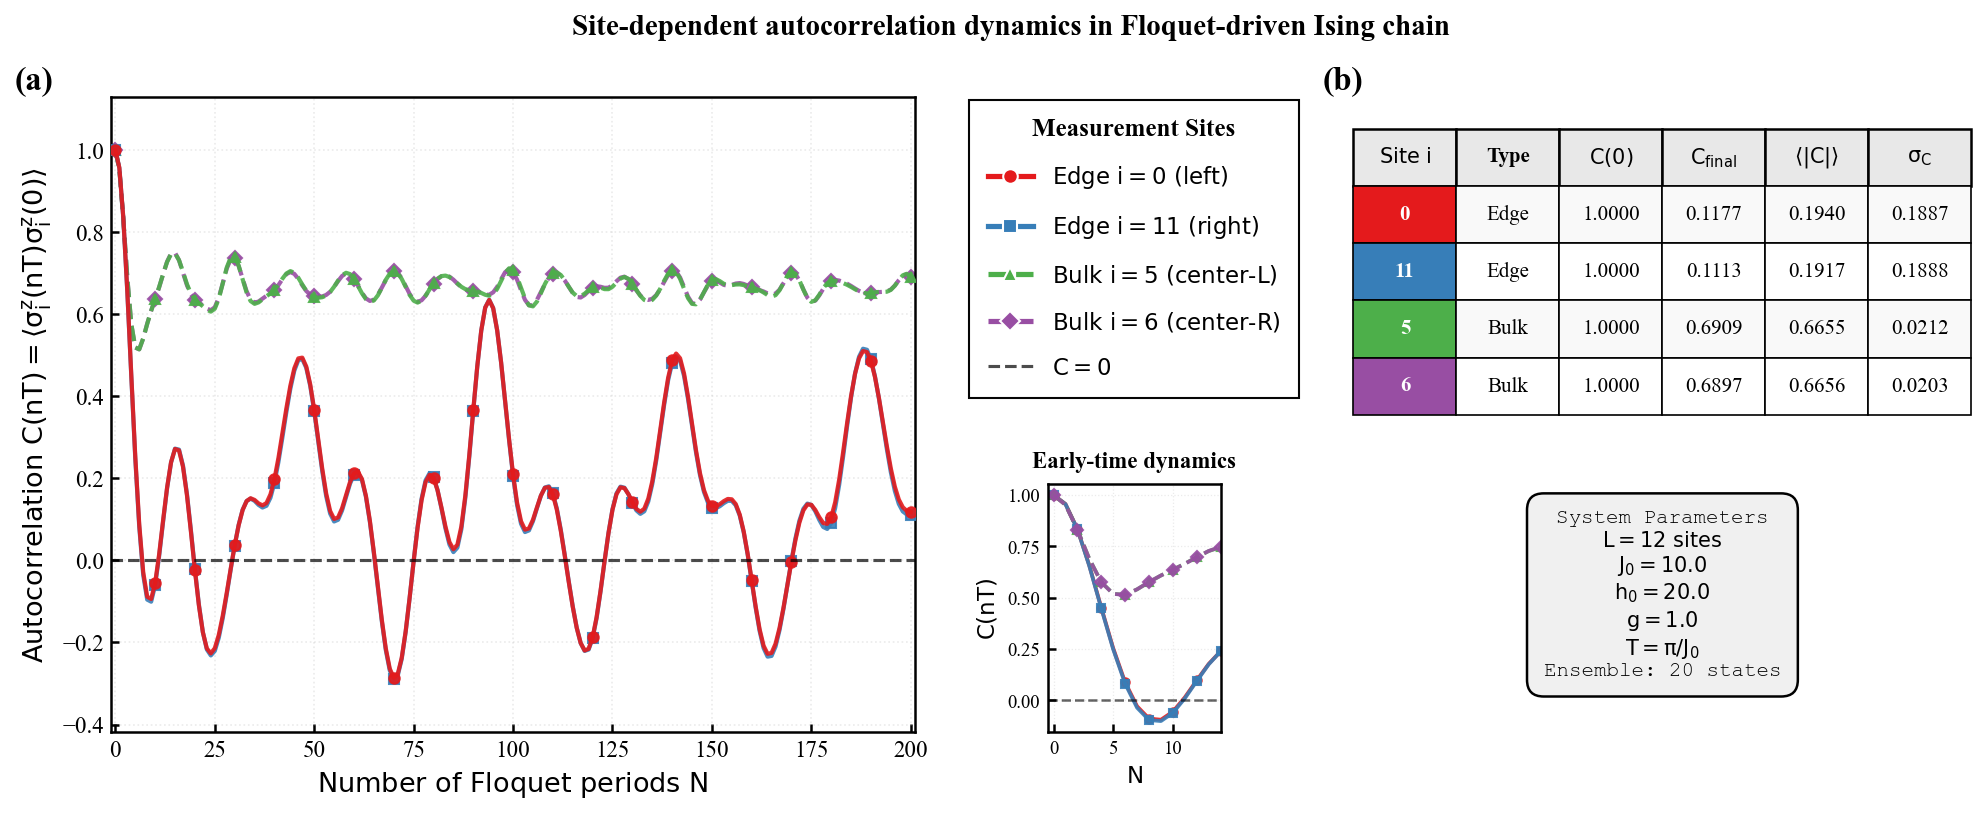


SITE-DEPENDENT AUTOCORRELATION STATISTICS

--------------------------------------------------------------------------------
Site i = 0 (Edge (left))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.117667
  Range: [-0.285920, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.194029
    Std(C) = 0.188723

--------------------------------------------------------------------------------
Site i = 11 (Edge (right))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.111327
  Range: [-0.290060, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.191691
    Std(C) = 0.188789

--------------------------------------------------------------------------------
Site i = 5 (Bulk (center-L))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.690870
  Range: [0.514404, 1.000000]
  Steady-state (n>100):
    Mean |C

C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\1417828412.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])



✓ Saved publication-quality figures:
  - floquet_autocorr_sites_T2.pdf
  - floquet_autocorr_sites_T2.png


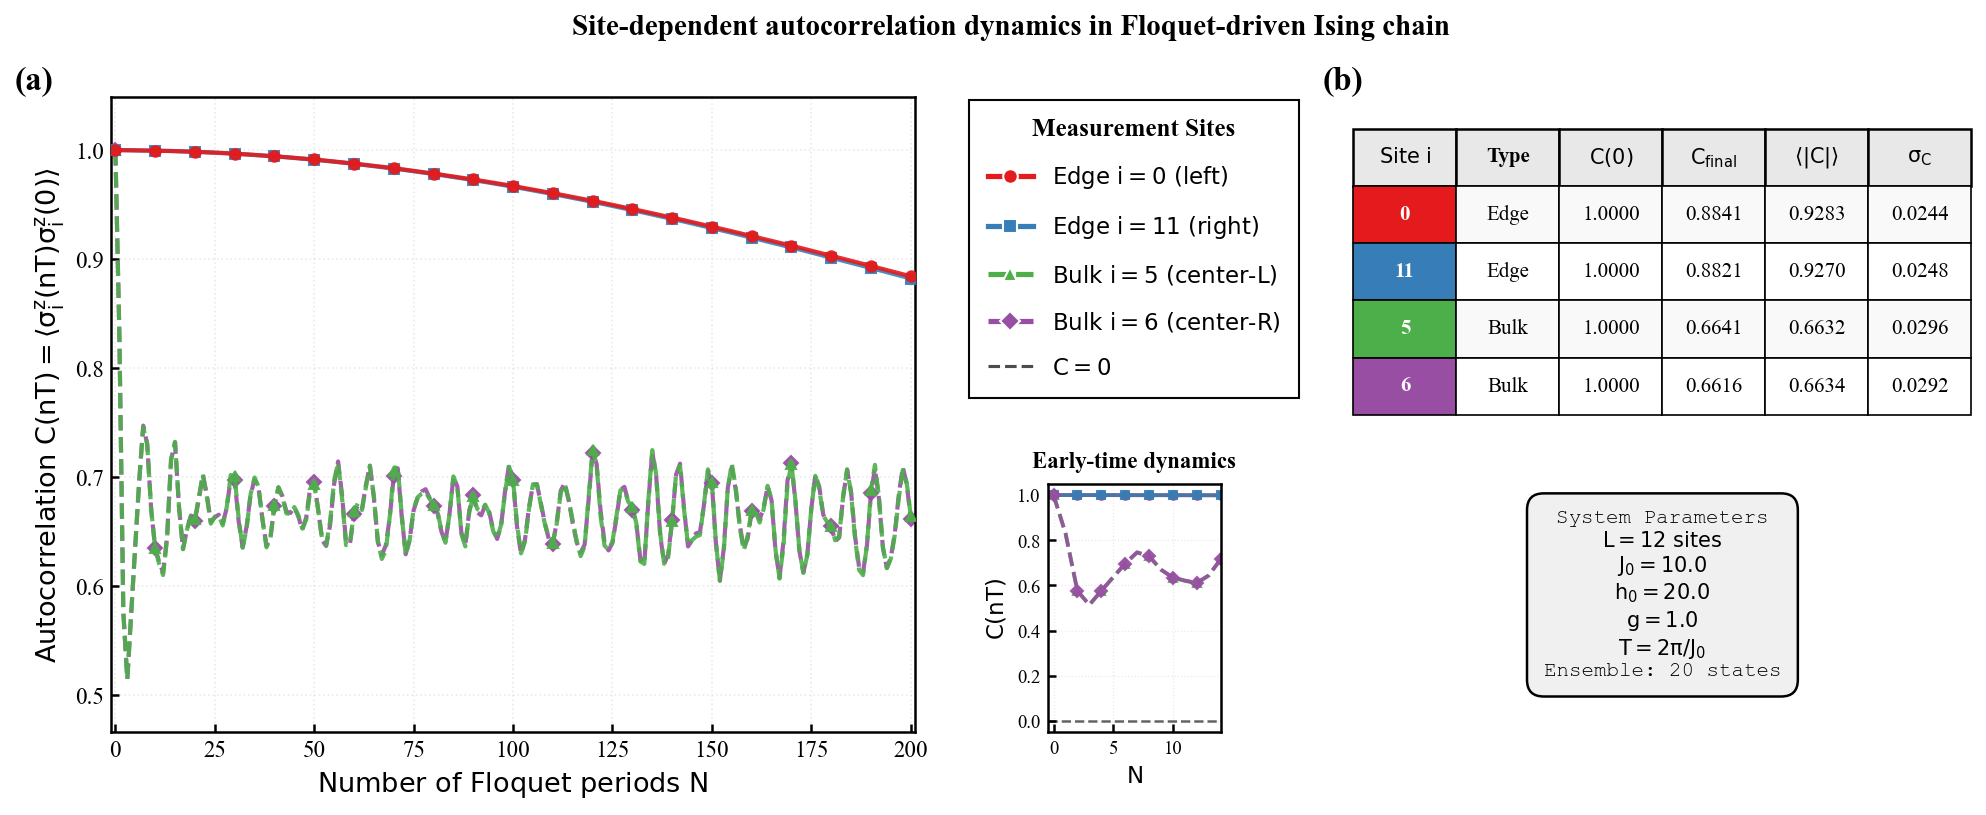


SITE-DEPENDENT AUTOCORRELATION STATISTICS

--------------------------------------------------------------------------------
Site i = 0 (Edge (left))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.884137
  Range: [0.884137, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.928332
    Std(C) = 0.024375

--------------------------------------------------------------------------------
Site i = 11 (Edge (right))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.882106
  Range: [0.882106, 1.000000]
  Steady-state (n>100):
    Mean |C| = 0.926972
    Std(C) = 0.024773

--------------------------------------------------------------------------------
Site i = 5 (Bulk (center-L))
--------------------------------------------------------------------------------
  C(0) = 1.000000
  C(final) = 0.664076
  Range: [0.514327, 1.000000]
  Steady-state (n>100):
    Mean |C| 

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import patches
import matplotlib.gridspec as gridspec

# ============================================
# PLOTTING FUNCTIONS
# ============================================

def plot_autocorr_site_comparison(results_dict, base_params):
    """
    Create publication-quality comparison plots for autocorrelation across sites.
    Format matches the period comparison plots.

    Parameters:
    -----------
    results_dict : dict
        Dictionary with site indices as keys, each containing:
        {'times': array, 'C_avg': array, 'site_type': str, 'site_label': str}
    base_params : dict
        Base system parameters
    """

    # Sort sites: edges first, then bulk
    edge_sites = base_params['edge_sites']
    bulk_sites = base_params['bulk_sites']
    all_sites = edge_sites + bulk_sites

    # Publication-quality settings
    plt.rcParams.update({
        'font.size': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.fancybox': False,
        'legend.edgecolor': 'black',
        'legend.borderpad': 0.5,
        'legend.columnspacing': 1.0,
    })

    # Color scheme: distinct for edge vs bulk
    edge_colors = ['#E41A1C', '#377EB8']  # Red, Blue
    bulk_colors = ['#4DAF4A', '#984EA3']  # Green, Purple
    all_colors = edge_colors + bulk_colors

    markers = ['o', 's', '^', 'D']
    linestyles = ['-', '-', '--', '--']  # Solid for edges, dashed for bulk

    # Create figure with custom layout
    fig = plt.figure(figsize=(16, 5.5), dpi=150)

    # Create nested GridSpec
    gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.3, 0.28, 1], wspace=0.25)

    # Main plot
    ax1 = plt.subplot(gs_main[0])

    # Middle panel subdivided
    gs_middle = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1],
                                                  height_ratios=[0.55, 0.45], hspace=0.3)
    ax_legend = plt.subplot(gs_middle[0])
    ax_legend.axis('off')

    ax_early = plt.subplot(gs_middle[1])

    # Statistics panel
    ax2 = plt.subplot(gs_main[2])

    # ============================================
    # PANEL A: Autocorrelation vs Periods
    # ============================================

    max_periods = max([len(results_dict[site]['C_avg']) for site in all_sites])

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        site_label = data['site_label']

        # Main plot
        label = f'{data["site_type"].capitalize()} $i={site_i}$ ({data["position"]})'

        ax1.plot(periods, C_avg,
                marker=markers[idx],
                color=all_colors[idx],
                linewidth=2.0,
                markersize=5,
                markevery=max(1, len(periods)//20),
                label=label,
                alpha=0.9,
                linestyle=linestyles[idx],
                zorder=5-idx)

    # Add zero line
    ax1.axhline(0, color='black', linestyle='--',
               linewidth=1.5, alpha=0.7, zorder=10)

    # Formatting
    ax1.set_xlabel("Number of Floquet periods $N$", fontsize=13, fontweight='normal')
    ax1.set_ylabel(r"Autocorrelation $C(nT) = \langle \sigma^z_i(nT) \sigma^z_i(0) \rangle$",
                   fontsize=13, fontweight='normal')
    ax1.set_xlim(-1, max_periods)

    # Set y-limits based on data
    all_data = np.concatenate([np.real(results_dict[site]['C_avg']) for site in all_sites])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax1.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

    # Grid
    ax1.grid(True, alpha=0.25, linestyle=':', linewidth=0.8, zorder=0)

    # Panel label
    ax1.text(-0.12, 1.05, '(a)', transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # ============================================
    # LEGEND PANEL
    # ============================================

    from matplotlib.lines import Line2D
    legend_elements = []
    legend_labels = []

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        label = f'{data["site_type"].capitalize()} $i={site_i}$ ({data["position"]})'

        legend_elements.append(Line2D([0], [0], color=all_colors[idx],
                                     linewidth=2.5, marker=markers[idx],
                                     linestyle=linestyles[idx],
                                     markersize=7, markeredgecolor='white', markeredgewidth=1))
        legend_labels.append(label)

    # Add zero line
    legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5,
                                  linestyle='--', alpha=0.7))
    legend_labels.append('$C=0$')

    # Place legend
    legend = ax_legend.legend(legend_elements, legend_labels,
                             loc='center',
                             fontsize=11,
                             frameon=True,
                             framealpha=0.98,
                             edgecolor='black',
                             fancybox=False,
                             title='Measurement Sites',
                             title_fontsize=12,
                             labelspacing=1.0,
                             borderpad=0.8)
    legend.get_title().set_weight('bold')

    # ============================================
    # EARLY DYNAMICS PANEL
    # ============================================

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        periods = np.arange(len(C_avg))
        ax_early.plot(periods[:15], C_avg[:15],
                     marker=markers[idx], color=all_colors[idx],
                     linewidth=1.8, markersize=4,
                     linestyle=linestyles[idx],
                     markevery=2, alpha=0.9)

    ax_early.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax_early.set_xlabel("$N$", fontsize=11, fontweight='normal')
    ax_early.set_ylabel("$C(nT)$", fontsize=11, fontweight='normal')
    ax_early.set_title("Early-time dynamics", fontsize=11, fontweight='bold', pad=8)
    ax_early.tick_params(labelsize=9, direction='in')
    ax_early.grid(True, alpha=0.25, linestyle=':', linewidth=0.6)
    ax_early.set_xlim(-0.5, 14)

    for spine in ax_early.spines.values():
        spine.set_linewidth(1.2)

    # ============================================
    # PANEL B: Statistics Table
    # ============================================

    ax2.axis('off')

    # Create table
    table_data = []
    headers = ['Site $i$', 'Type', '$C(0)$', '$C_{final}$',
               '$\\langle|C|\\rangle$', '$\\sigma_C$']

    n_start = 100

    for idx, site_i in enumerate(all_sites):
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])
        C_initial = C_avg[0]
        C_final = C_avg[-1]

        # Statistics
        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            mean_abs = np.mean(np.abs(C_steady))
            std_C = np.std(C_steady)
        else:
            mean_abs = np.mean(np.abs(C_avg))
            std_C = np.std(C_avg)

        site_type = data['site_type'].capitalize()

        table_data.append([
            f'{site_i}',
            site_type,
            f'{C_initial:.4f}',
            f'{C_final:.4f}',
            f'{mean_abs:.4f}',
            f'{std_C:.4f}'
        ])

    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=headers,
                     cellLoc='center',
                     loc='upper center',
                     bbox=[0.0, 0.5, 1.0, 0.45])

    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.0)

    # Header styling
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(weight='bold', fontsize=10)
        cell.set_edgecolor('black')
        cell.set_linewidth(1.2)

    # Data cells styling
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            cell = table[(i, j)]
            cell.set_facecolor('white' if i % 2 == 0 else '#F9F9F9')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.8)
            # Color code by site
            if j == 0:  # site column
                cell.set_facecolor(all_colors[i-1])
                cell.set_text_props(color='white', weight='bold')

    # System parameters box
    period_factor = base_params['period_factor']
    if period_factor == 1:
        period_str = r'$T = \pi/J_0$'
    elif period_factor == 0.5:
        period_str = r'$T = \pi/(2J_0)$'
    elif period_factor == 2:
        period_str = r'$T = 2\pi/J_0$'
    else:
        period_str = rf'$T = {period_factor}\pi/J_0$'

    param_text = "System Parameters\n"
    param_text += f"$L = {base_params['L']}$ sites\n"
    param_text += f"$J_0 = {base_params['J_0']:.1f}$\n"
    param_text += f"$h_0 = {base_params['h_0']:.1f}$\n"
    param_text += f"$g = {base_params['g']:.1f}$\n"
    param_text += f"{period_str}\n"
    param_text += f"Ensemble: {base_params['num_states']} states"

    ax2.text(0.5, 0.35, param_text, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0F0F0',
                     edgecolor='black', linewidth=1.2),
            family='monospace')

    # Panel label
    ax2.text(-0.05, 1.05, '(b)', transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top')

    # Overall title
    fig.suptitle("Site-dependent autocorrelation dynamics in Floquet-driven Ising chain",
                fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save
    period_label = str(period_factor).replace('.', 'p')
    plt.savefig(f'floquet_autocorr_sites_T{period_label}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'floquet_autocorr_sites_T{period_label}.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved publication-quality figures:")
    print(f"  - floquet_autocorr_sites_T{period_label}.pdf")
    print(f"  - floquet_autocorr_sites_T{period_label}.png")

    plt.show()

    # Detailed statistics
    print("\n" + "="*80)
    print("SITE-DEPENDENT AUTOCORRELATION STATISTICS")
    print("="*80)

    for site_i in all_sites:
        data = results_dict[site_i]
        C_avg = np.real(data['C_avg'])

        print(f"\n{'-'*80}")
        print(f"Site i = {site_i} ({data['site_label']})")
        print(f"{'-'*80}")
        print(f"  C(0) = {C_avg[0]:.6f}")
        print(f"  C(final) = {C_avg[-1]:.6f}")
        print(f"  Range: [{np.min(C_avg):.6f}, {np.max(C_avg):.6f}]")

        if len(C_avg) > n_start:
            C_steady = C_avg[n_start:]
            print(f"  Steady-state (n>{n_start}):")
            print(f"    Mean |C| = {np.mean(np.abs(C_steady)):.6f}")
            print(f"    Std(C) = {np.std(C_steady):.6f}")

    plt.rcParams.update(plt.rcParamsDefault)


# ============================================
# EXAMPLE USAGE
# ============================================

# These would be computed from your simulation
# Example structure for demonstration:
"""
resultssites1 = {
    0: {'times': times, 'C_avg': C_avg_site0, 'site_type': 'edge',
        'site_label': 'Left edge', 'position': 'left'},
    7: {'times': times, 'C_avg': C_avg_site7, 'site_type': 'edge',
        'site_label': 'Right edge', 'position': 'right'},
    3: {'times': times, 'C_avg': C_avg_site3, 'site_type': 'bulk',
        'site_label': 'Bulk center-left', 'position': 'center-left'},
    4: {'times': times, 'C_avg': C_avg_site4, 'site_type': 'bulk',
        'site_label': 'Bulk center-right', 'position': 'center-right'}
}

paramssites1 = {
    'L': 8,
    'J_0': 10.0,
    'h_0': 20.0,
    'g': 1.0,
    'period_factor': 1.0,
    'num_states': 1,
    'edge_sites': [0, 7],
    'bulk_sites': [3, 4]
}
"""

print("\n" + "="*80)
print("SITE COMPARISON PLOTTING SCRIPT")
print("="*80)
print("\nThis script provides two plotting functions:")
print("  1. plot_autocorr_site_comparison() - Three-panel layout with statistics")
print("  2. plot_autocorr_sites_only() - Standalone autocorrelation plot")
print("\nUsage example:")
print("  plot_autocorr_site_comparison(resultssites1, paramssites1)")
print("  plot_autocorr_sites_only(resultssites1, paramssites1)")
print("="*80)

# Uncomment these lines when you have actual data:

print("\n" + "="*80)
print("CREATING PUBLICATION PLOT FOR T = π/J₀")
print("="*80)
plot_autocorr_site_comparison(results_sites1, params_sites1)  # Three-panel

print("\n" + "="*80)
print("CREATING PUBLICATION PLOT FOR T = 2π/J₀")
print("="*80)
plot_autocorr_site_comparison(results_sites2, params_sites2)  # Three-panel

### Plots for publication

Figure saved to: autocorr_sites_T1pi.pdf


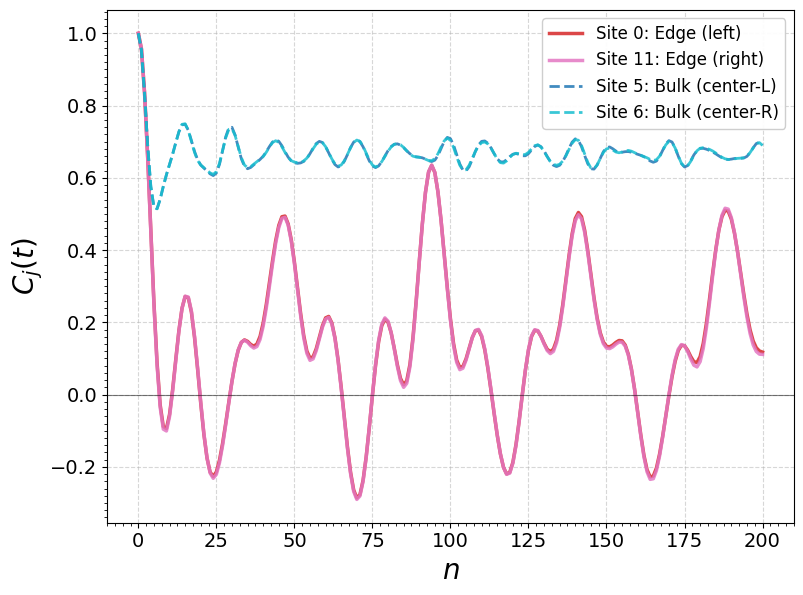

Figure saved to: autocorr_sites_T2pi.pdf


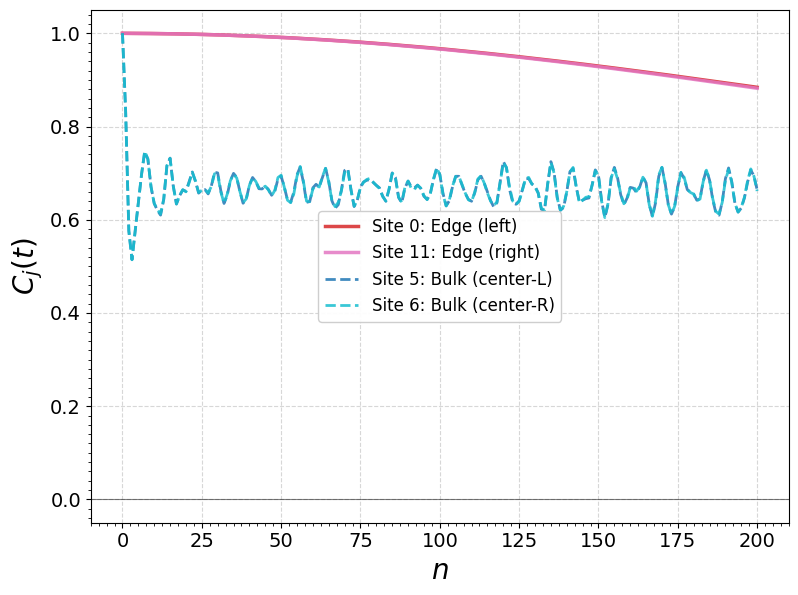

In [54]:
def plot_autocorr_sites(results, params, save_path=None):
    """
    Create publication-quality plot for autocorrelation at different sites.

    Parameters:
    -----------
    results : dict
        Results dictionary with site indices as keys, containing:
        times, C_avg, site_type, site_label, position
    params : dict
        Parameter dictionary containing L, J_0, h_0, g, period_factor, etc.
    save_path : str, optional
        Path to save the figure
    """

    # ========== EASILY MODIFIABLE PARAMETERS ==========
    # Axis labels
    xlabel_text = r'$n$'
    ylabel_text = r'$C_j(t)$'

    # Figure size: optimized for 2 side-by-side on A4 paper
    fig_width = 8.0   # inches
    fig_height = 6.0  # inches

    # Legend position: 'best', 'upper right', 'lower left', etc.
    legend_loc = 'best'
    legend_fontsize = 12

    # Colors for edge and bulk sites
    edge_colors = ['#d62728', '#e377c2']  # Red shades for edges
    bulk_colors = ['#1f77b4', '#17becf']  # Blue shades for bulk

    # Line properties
    linewidth_edge = 2.5
    linewidth_bulk = 2.0
    alpha = 0.85

    # Line styles
    linestyle_edge = '-'
    linestyle_bulk = '--'

    # Grid properties
    show_grid = True
    grid_alpha = 0.5
    grid_linestyle = '--'

    # Show zero line
    show_zero_line = True
    # ==================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Separate sites by type
    edge_sites = []
    bulk_sites = []

    for site_idx in sorted(results.keys()):
        if results[site_idx]['site_type'] == 'edge':
            edge_sites.append(site_idx)
        else:
            bulk_sites.append(site_idx)

    # Plot edge sites
    for idx, site_i in enumerate(edge_sites):
        times = results[site_i]['times']
        C_avg = np.real(results[site_i]['C_avg'])
        site_label = results[site_i]['site_label']
        periods = np.arange(len(C_avg))

        ax.plot(periods, C_avg,
                label=f'Site {site_i}: {site_label}',
                color=edge_colors[idx % len(edge_colors)],
                linewidth=linewidth_edge,
                linestyle=linestyle_edge,
                alpha=alpha)

    # Plot bulk sites
    for idx, site_i in enumerate(bulk_sites):
        times = results[site_i]['times']
        C_avg = np.real(results[site_i]['C_avg'])
        site_label = results[site_i]['site_label']
        periods = np.arange(len(C_avg))

        ax.plot(periods, C_avg,
                label=f'Site {site_i}: {site_label}',
                color=bulk_colors[idx % len(bulk_colors)],
                linewidth=linewidth_bulk,
                linestyle=linestyle_bulk,
                alpha=alpha)

    # Set labels
    ax.set_xlabel(xlabel_text, fontsize=20)
    ax.set_ylabel(ylabel_text, fontsize=20)

    # Legend
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, framealpha=0.95)

    # Grid
    if show_grid:
        ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Zero line
    if show_zero_line:
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

    # Set minor locators
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(10))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

    return fig, ax


# Generate plots for both period factors

# Plot for T = π/J_0
fig_sites1, ax_sites1 = plot_autocorr_sites(
    results_sites1,
    params_sites1,
    save_path='autocorr_sites_T1pi.pdf'
)

# Plot for T = 2π/J_0
fig_sites2, ax_sites2 = plot_autocorr_sites(
    results_sites2,
    params_sites2,
    save_path='autocorr_sites_T2pi.pdf'
)

# $C_L(t)$ with system size





## Parameters and setup schedule

In [61]:
# ============================================
# STEP 1 : PARAMETERS AND STEP SCHEDULE
# ============================================

import numpy as np
from scipy.linalg import expm

# ========== PHYSICAL PARAMETERS ==========
J_0 = 10.0           # Ising coupling strength
h_0 = 20.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
TP = 2 * np.pi / J_0 # Time period T = 2π/J₀
site_i = 0           # Edge site (i=0)

# ========== SIMULATION PARAMETERS ==========
epsilon = 1e-1       # Threshold for "reaching zero"
max_steps = int(1e8) # Maximum Floquet steps
num_states = 1       # Single random state
seed = 42            # Random seed for reproducibility

# ========== SYSTEM SIZES ==========
L_values = [4, 5, 6]

# ========== ADAPTIVE STEP SCHEDULE ==========
step_schedule = [
    (0, 100, 1),
    (100, 600, 100),
    (600, 10000, 1000),
    (10000, 50000, 5000),
    (50000, 1000000, 10000),
    (1000000, max_steps, 50000)
]

print("=" * 60)
print("EDGE AUTOCORRELATION DECAY ANALYSIS (HEISENBERG/DENSE)")
print("=" * 60)
print(f"\nPhysical Parameters:")
print(f"  J_0 = {J_0}, h_0 = {h_0}, g = {g}")
print(f"  T = 2π/J_0 = {TP:.6f}")
print(f"  Edge site i = {site_i}")

print(f"\nSimulation Parameters:")
print(f"  Threshold ε = {epsilon}")
print(f"  Max steps = {max_steps:,}")
print(f"  System sizes L = {L_values}")

print(f"\nAdaptive Step Schedule:")
for start, end, step in step_schedule:
    print(f"  Steps {start:>8,} → {end:>11,}: step size = {step:,}")


EDGE AUTOCORRELATION DECAY ANALYSIS (HEISENBERG/DENSE)

Physical Parameters:
  J_0 = 10.0, h_0 = 20.0, g = 1.0
  T = 2π/J_0 = 0.628319
  Edge site i = 0

Simulation Parameters:
  Threshold ε = 0.1
  Max steps = 100,000,000
  System sizes L = [4, 5, 6]

Adaptive Step Schedule:
  Steps        0 →         100: step size = 1
  Steps      100 →         600: step size = 100
  Steps      600 →      10,000: step size = 1,000
  Steps   10,000 →      50,000: step size = 5,000
  Steps   50,000 →   1,000,000: step size = 10,000
  Steps 1,000,000 → 100,000,000: step size = 50,000


## Adaptive autocorrelation function

In [62]:
import numpy as np
import time
from scipy.linalg import expm



# ============================================
# DENSE FLOQUET OPERATOR BUILDER
# ============================================

def build_floquet_operator(ising_chain):
    """
    Build dense Floquet unitary operator U_F = exp(-iH_- T/2) exp(-iH_+ T/2).

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        System with Hamiltonians built.

    Returns
    -------
    U_floquet : ndarray, shape (Ns, Ns)
        Dense Floquet unitary matrix.
    """
    T = ising_chain.T
    hbar = ising_chain.hbar
    dt_half = T / (2.0 * hbar)

    H_plus_dense = ising_chain.H_plus_sparse.toarray()
    H_minus_dense = ising_chain.H_minus_sparse.toarray()

    U_plus = expm(-1j * H_plus_dense * dt_half)
    U_minus = expm(-1j * H_minus_dense * dt_half)
    U_floquet = U_minus @ U_plus

    return U_floquet


def build_sigma_z_i(ising_chain, site_i):
    """
    Build dense σ^z operator at site i.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        System with basis.
    site_i : int
        Site index.

    Returns
    -------
    sigma_z : ndarray, shape (Ns, Ns)
        Dense diagonal matrix.
    """
    sigma_z_diag = get_sigma_z_diagonal(ising_chain, site_i)
    return np.diag(sigma_z_diag)


# ============================================
# ADAPTIVE AUTOCORRELATION (HEISENBERG/DENSE)
# ============================================

def compute_autocorrelation_adaptive(psi0, U_floquet, sigma_z_i, step_schedule,
                                      epsilon=1e-2, max_steps=int(1e8), verbose=True):
    """
    Compute autocorrelation with adaptive step sizes until Re[C(nT)] < epsilon.

    Uses Heisenberg picture with precomputed U^N matrices for efficiency:
    σ^z((n+N)T) = (U†)^N σ^z(nT) U^N

    This is the FAST method for moderate L (≤12) with large step sizes.

    Parameters
    ----------
    psi0 : ndarray, shape (Ns,)
        Initial random state.
    U_floquet : ndarray, shape (Ns, Ns)
        One-period Floquet evolution operator.
    sigma_z_i : ndarray, shape (Ns, Ns)
        σ^z operator at measurement site.
    step_schedule : list of tuples
        [(start, end, step_size), ...] defining adaptive stepping.
    epsilon : float
        Threshold for considering autocorrelation as decayed.
    max_steps : int
        Maximum number of Floquet steps.
    verbose : bool
        Print progress updates.

    Returns
    -------
    decay_step : int or None
        First Floquet step where Re[C(nT)] < epsilon, or None if not reached.
    steps_record : list
        List of Floquet steps where autocorrelation was computed.
    C_record : list
        List of Re[C(nT)] values at those steps.
    """

    Ns = U_floquet.shape[0]

    # ========================================
    # Precompute U^N and (U†)^N for each unique step size
    # ========================================
    unique_step_sizes = sorted(set([s[2] for s in step_schedule]))
    U_powers = {}
    U_dag_powers = {}

    if verbose:
        print(f"    Precomputing U^N for step sizes: {unique_step_sizes}")

    precompute_start = time.time()
    for N in unique_step_sizes:
        U_powers[N] = np.linalg.matrix_power(U_floquet, N)
        U_dag_powers[N] = U_powers[N].conj().T
    precompute_time = time.time() - precompute_start

    if verbose:
        print(f"    Precomputation time: {precompute_time:.2f}s")
        mem_used = len(unique_step_sizes) * 2 * Ns * Ns * 16 / 1e6
        print(f"    Memory for U^N matrices: ~{mem_used:.1f} MB")

    # ========================================
    # Initialize Heisenberg picture
    # ========================================
    phi = sigma_z_i @ psi0      # σ^z(0)|ψ₀⟩ - stays constant
    sigma_z_t = sigma_z_i.copy()  # Operator at current time

    current_step = 0
    decay_step = None
    steps_record = []
    C_record = []

    # ========================================
    # Compute C(0)
    # ========================================
    C_0 = np.vdot(psi0, sigma_z_t @ phi)
    steps_record.append(0)
    C_record.append(np.real(C_0))

    if verbose:
        print(f"    C(0) = {np.real(C_0):.6f}")

    if np.real(C_0) < epsilon:
        if verbose:
            print(f"    Already below threshold at step 0!")
        return 0, steps_record, C_record

    # ========================================
    # Iterate through step schedule
    # ========================================
    evolution_start = time.time()

    for phase_idx, (start, end, step_size) in enumerate(step_schedule):
        if current_step >= max_steps:
            break
        if decay_step is not None:
            break

        # Skip if we're already past this phase
        if current_step >= end:
            continue

        if verbose:
            print(f"    Phase {phase_idx + 1}: steps {start:,} → {end:,}, step size = {step_size:,}")

        # Get precomputed matrices for this step size
        U_N = U_powers[step_size]
        U_N_dag = U_dag_powers[step_size]

        # Progress tracking
        last_progress_step = current_step
        phase_start = time.time()

        # Evolve within this phase
        while current_step < end and current_step < max_steps:
            # Heisenberg evolution: σ^z((n+N)T) = U_N† σ^z(nT) U_N
            sigma_z_t = U_N_dag @ sigma_z_t @ U_N
            current_step += step_size

            # Compute autocorrelation: C(nT) = ⟨ψ₀|σ^z(nT)|φ⟩
            C_t = np.vdot(psi0, sigma_z_t @ phi)
            C_real = np.real(C_t)

            steps_record.append(current_step)
            C_record.append(C_real)

            # Check threshold
            if C_real < epsilon:
                decay_step = current_step
                if verbose:
                    print(f"    *** Decay reached at step {current_step:,}: Re[C] = {C_real:.6e} ***")
                break

            # Progress update every ~10% of phase or every 1M steps
            progress_interval = max(1000000, (end - start) // 10)
            if verbose and (current_step - last_progress_step >= progress_interval):
                elapsed = time.time() - phase_start
                rate = (current_step - start) / elapsed if elapsed > 0 else 0
                print(f"      Step {current_step:,}: Re[C] = {C_real:.6e} ({rate:.0f} steps/s)")
                last_progress_step = current_step

        # End of phase update
        if verbose and decay_step is None and len(C_record) > 0:
            phase_time = time.time() - phase_start
            print(f"      End of phase: Step {current_step:,}, Re[C] = {C_record[-1]:.6e} ({phase_time:.1f}s)")

    evolution_time = time.time() - evolution_start

    if decay_step is None and verbose:
        print(f"    Did not reach threshold within {max_steps:,} steps")
        print(f"    Final Re[C] at step {current_step:,} = {C_record[-1]:.6e}")

    if verbose:
        print(f"    Total evolution time: {evolution_time:.2f}s")

    return decay_step, steps_record, C_record


# ============================================
# TEST: Verify function with a single L value
# ============================================

print("\n" + "=" * 60)
print("TESTING ADAPTIVE AUTOCORRELATION FUNCTION")
print("=" * 60)

L_test = 6
print(f"\nTest with L = {L_test}")

# Build system
ising_test = FloquetIsingChain(L=L_test, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
ising_test.build_hamiltonians()

# Build dense operators
print(f"\nBuilding dense Floquet operator...")
U_floquet_test = build_floquet_operator(ising_test)
sigma_z_edge_test = build_sigma_z_i(ising_test, site_i=0)

print(f"  U_floquet shape: {U_floquet_test.shape}")
print(f"  σ^z shape: {sigma_z_edge_test.shape}")
print(f"  Memory: ~{U_floquet_test.nbytes / 1e6:.1f} MB")

# Generate random state
np.random.seed(seed)
psi0_test = np.random.randn(ising_test.Ns) + 1j * np.random.randn(ising_test.Ns)
psi0_test = (psi0_test / np.linalg.norm(psi0_test)).astype(np.complex128)
print(f"\nGenerated random initial state (dim = {ising_test.Ns})")

# Run adaptive autocorrelation
print("\nRunning adaptive autocorrelation (Heisenberg/Dense)...")
test_start = time.time()

decay_step_test, steps_test, C_test = compute_autocorrelation_adaptive(
    psi0_test, U_floquet_test, sigma_z_edge_test,
    step_schedule, epsilon=epsilon, max_steps=max_steps
)

test_time = time.time() - test_start

print(f"\nTest Results:")
print(f"  Decay step N = {decay_step_test}")
print(f"  Number of computed points = {len(steps_test)}")
if len(steps_test) > 0:
    print(f"  Final step reached: {steps_test[-1]:,}")
    print(f"  Final Re[C] value: {C_test[-1]:.6e}")
print(f"  Total time: {test_time:.2f}s")

# ========== SCALING ESTIMATE ==========
print(f"\n{'='*60}")
print("SCALING ESTIMATE")
print(f"{'='*60}")

for L_est in [8, 10, 12, 14]:
    Ns_est = 2**L_est
    mem_U = Ns_est * Ns_est * 16 / 1e9  # GB for one U matrix
    mem_total = mem_U * len(set([s[2] for s in step_schedule])) * 2  # U^N and U†^N

    status = "✓ OK" if mem_total < 16 else "⚠ High" if mem_total < 64 else "✗ Too large"
    print(f"  L={L_est}: Ns={Ns_est:,}, Memory ~{mem_total:.1f} GB  [{status}]")

print(f"\n{'='*60}")
print("✓ SECTION L COMPLETE")
print(f"{'='*60}")


TESTING ADAPTIVE AUTOCORRELATION FUNCTION

Test with L = 6
System Parameters:
  Chain length L = 6
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 64

Hamiltonians constructed successfully!
  H+ shape: (64, 64), nnz = 448, density = 1.09e-01
  H- shape: (64, 64), nnz = 448
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.01 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 2.27e-13

Building dense Floquet operator...
  U_floquet shape: (64, 64)
  σ^z shape: (64, 64)
  Memory: ~0.1 MB

Generated random initial state (dim = 64)

Running adaptive autocorrelation (Heisenberg/Dense)...
    Precomputing U^N for step sizes: [1, 100, 1000, 5000, 10000, 50000]
    Precomputation time: 0.01s
    Memory for U^N matrices: ~0.8 MB
    C(0) = 1.000000
    Phase 1: steps 0 → 100, step size = 1
      End of phase: Step 100, Re[C] = 9.622300e-01 (0.1s)
    Phase 2: steps 100 → 600, step size = 100
      End of phase: Step 600, Re[C] = 6.7

## Results code

In [63]:
# ============================================
# STEP 3: MAIN LOOP OVER SYSTEM SIZES L=4 to 6
# ============================================

import time

print("\n" + "=" * 70)
print("COMPUTING EDGE AUTOCORRELATION DECAY FOR L = 4, 5, 6")
print("=" * 70)

# Storage for results
results = {
    'L': [],
    'decay_step': [],
    'final_C': [],
    'dim': [],
    'steps_record': [],
    'C_record': []
}

# Loop over system sizes
for L in L_values:
    print(f"\n{'='*70}")
    print(f"L = {L}")
    print(f"{'='*70}")

    start_time = time.time()

    # Build Floquet system
    print(f"\n  Building Floquet system...")
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()
    U_floquet = build_floquet_operator(ising)

    # Build σᶻ at edge site (i=0)
    sigma_z_edge = build_sigma_z_i(ising, site_i=0)

    # Generate random state (use same seed offset for reproducibility)
    dim = ising.basis.Ns
    np.random.seed(seed + L)  # Different seed for each L, but reproducible
    psi0 = np.random.randn(dim) + 1j * np.random.randn(dim)
    psi0 = psi0 / np.linalg.norm(psi0)
    print(f"\n  Generated random initial state (dim = {dim})")

    # Compute autocorrelation with adaptive stepping
    print(f"\n  Computing autocorrelation...")
    decay_step, steps_record, C_record = compute_autocorrelation_adaptive(
        psi0, U_floquet, sigma_z_edge,
        step_schedule, epsilon=epsilon, max_steps=max_steps
    )

    elapsed_time = time.time() - start_time

    # Store results
    results['L'].append(L)
    results['decay_step'].append(decay_step)
    results['final_C'].append(C_record[-1] if C_record else None)
    results['dim'].append(dim)
    results['steps_record'].append(steps_record)
    results['C_record'].append(C_record)

    # Summary for this L
    print(f"\n  Results for L = {L}:")
    print(f"    Hilbert space dimension: {dim}")
    print(f"    Decay step N: {decay_step if decay_step else 'Not reached'}")
    print(f"    Final Re[C]: {C_record[-1]:.6e}")
    print(f"    Computation time: {elapsed_time:.2f} s")

# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "=" * 70)
print("SUMMARY: EDGE AUTOCORRELATION DECAY")
print("=" * 70)
print(f"\nParameters: J_0={J_0}, h_0={h_0}, g={g}, T=2π/J_0={TP:.4f}")
print(f"Edge site: i = 0")
print(f"Threshold: ε = {epsilon}")
print(f"Max steps: {max_steps:,}")

print(f"\n{'L':<6} {'Dim':<10} {'Decay Step N':<20} {'Final Re[C]':<15}")
print("-" * 55)
for i, L in enumerate(results['L']):
    decay = results['decay_step'][i]
    decay_str = f"{decay:,}" if decay is not None else "Not reached"
    final_C = results['final_C'][i]
    print(f"{L:<6} {results['dim'][i]:<10} {decay_str:<20} {final_C:<15.6e}")

print("-" * 55)


COMPUTING EDGE AUTOCORRELATION DECAY FOR L = 4, 5, 6

L = 4

  Building Floquet system...
System Parameters:
  Chain length L = 4
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.628319
  Hilbert space dimension = 16

Hamiltonians constructed successfully!
  H+ shape: (16, 16), nnz = 80, density = 3.12e-01
  H- shape: (16, 16), nnz = 80
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.00 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 6.36e-14

  Generated random initial state (dim = 16)

  Computing autocorrelation...
    Precomputing U^N for step sizes: [1, 100, 1000, 5000, 10000, 50000]
    Precomputation time: 0.00s
    Memory for U^N matrices: ~0.0 MB
    C(0) = 1.000000
    Phase 1: steps 0 → 100, step size = 1
      End of phase: Step 100, Re[C] = 9.512571e-01 (0.0s)
    Phase 2: steps 100 → 600, step size = 100
      End of phase: Step 600, Re[C] = 6.684688e-01 (0.0s)
    Phase 3: steps 600 → 10,000, step size = 1,000
    *** Decay reached at step

## Plotting code


PLOTTING AUTOCORRELATION DECAY FOR ALL SYSTEM SIZES


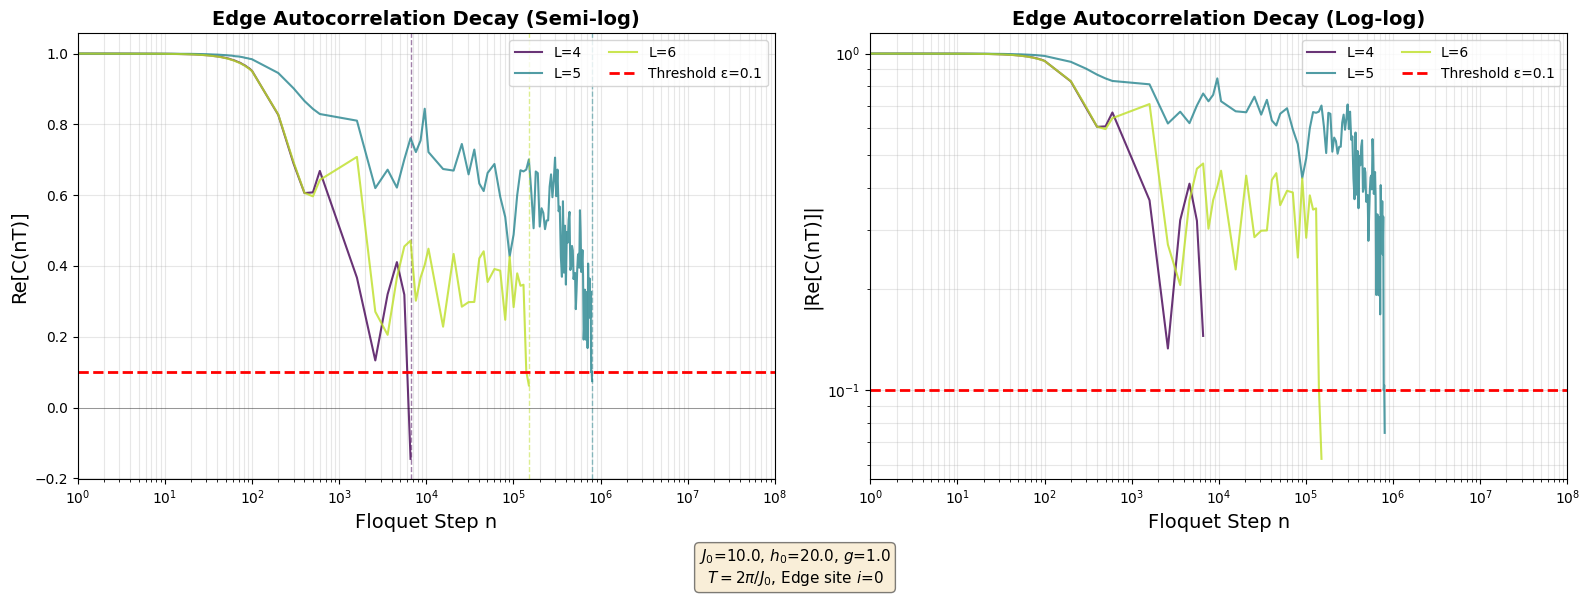


Plot saved as 'autocorrelation_decay_all_L.png'


In [64]:
# ============================================
# STEP 4: PLOT AUTOCORRELATION DECAY FOR ALL L
# ============================================

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

print("\n" + "=" * 70)
print("PLOTTING AUTOCORRELATION DECAY FOR ALL SYSTEM SIZES")
print("=" * 70)

# Create figure with two panels: linear-log and log-log
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palette (colorblind-friendly)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(L_values)))

# ========== Panel 1: Semi-log plot (linear y, log x) ==========
ax1 = axes[0]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Filter out step 0 for log scale (will cause issues)
    mask = steps > 0
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    # Plot
    ax1.plot(steps_plot, C_plot, '-', color=colors[i], linewidth=1.5,
             label=f'L={L}', alpha=0.8)

    # Mark decay point if exists
    decay_step = results['decay_step'][i]
    if decay_step is not None:
        # Find the C value at decay
        idx = np.where(steps == decay_step)[0]
        if len(idx) > 0:
            ax1.axvline(x=decay_step, color=colors[i], linestyle='--',
                       alpha=0.5, linewidth=1)

# Threshold line
ax1.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xscale('log')
ax1.set_xlabel('Floquet Step n', fontsize=14)
ax1.set_ylabel('Re[C(nT)]', fontsize=14)
ax1.set_title('Edge Autocorrelation Decay (Semi-log)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim([1, max_steps])

# ========== Panel 2: Log-log plot of |C(nT)| ==========
ax2 = axes[1]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Filter out step 0 and use absolute value for log scale
    mask = (steps > 0) & (np.abs(C_vals) > 1e-16)
    steps_plot = steps[mask]
    C_abs = np.abs(C_vals[mask])

    # Plot
    ax2.plot(steps_plot, C_abs, '-', color=colors[i], linewidth=1.5,
             label=f'L={L}', alpha=0.8)

# Threshold line
ax2.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Floquet Step n', fontsize=14)
ax2.set_ylabel('|Re[C(nT)]|', fontsize=14)
ax2.set_title('Edge Autocorrelation Decay (Log-log)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim([1, max_steps])

# Add parameter text box
param_text = f'$J_0$={J_0}, $h_0$={h_0}, $g$={g}\n$T=2\\pi/J_0$, Edge site $i$=0'
fig.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('autocorrelation_decay_all_L.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'autocorrelation_decay_all_L.png'")

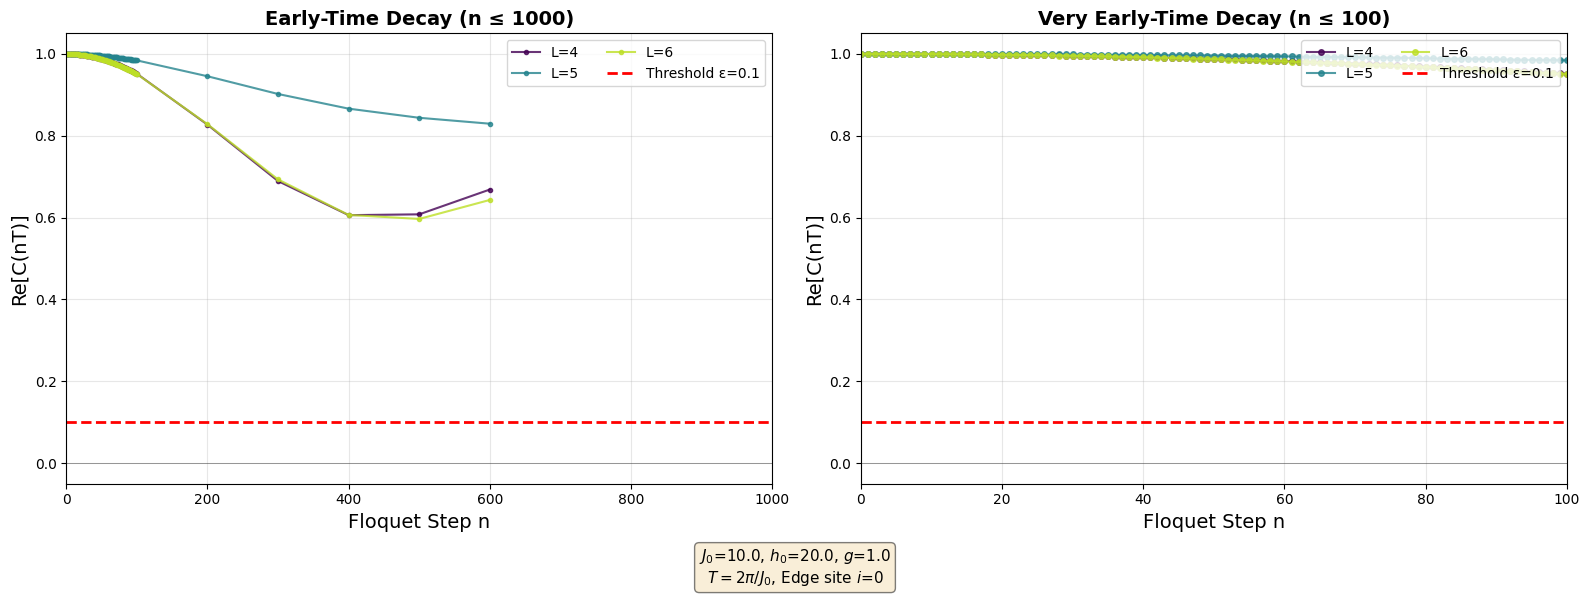


Plot saved as 'autocorrelation_decay_early_time.png'


In [65]:
# ============================================
# ADDITIONAL PLOT: EARLY-TIME BEHAVIOR (Steps 0-1000)
# ============================================

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# ========== Panel 1: Linear scale, early times ==========
ax1 = axes2[0]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Only plot up to step 1000
    mask = steps <= 1000
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    ax1.plot(steps_plot, C_plot, 'o-', color=colors[i], linewidth=1.5,
             markersize=3, label=f'L={L}', alpha=0.8)

ax1.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Floquet Step n', fontsize=14)
ax1.set_ylabel('Re[C(nT)]', fontsize=14)
ax1.set_title('Early-Time Decay (n ≤ 1000)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1000])

# ========== Panel 2: First 100 steps (step size 1) ==========
ax2 = axes2[1]

for i, L in enumerate(results['L']):
    steps = np.array(results['steps_record'][i])
    C_vals = np.array(results['C_record'][i])

    # Only plot up to step 100
    mask = steps <= 100
    steps_plot = steps[mask]
    C_plot = C_vals[mask]

    ax2.plot(steps_plot, C_plot, 'o-', color=colors[i], linewidth=1.5,
             markersize=4, label=f'L={L}', alpha=0.8)

ax2.axhline(y=epsilon, color='red', linestyle='--', linewidth=2,
            label=f'Threshold ε={epsilon}')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Floquet Step n', fontsize=14)
ax2.set_ylabel('Re[C(nT)]', fontsize=14)
ax2.set_title('Very Early-Time Decay (n ≤ 100)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 100])

# Add parameter text box
fig2.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('autocorrelation_decay_early_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'autocorrelation_decay_early_time.png'")


PLOTTING DECAY STEP N vs SYSTEM SIZE L

Data for N vs L plot:
L      Decay Step N         log10(N)       
---------------------------------------------
4      6,600                3.8195         
5      800,600              5.9034         
6      150,600              5.1778         

Valid decay points: 3/3

Exponential fit: N = 3.7259e+01 × exp(1.5638 × L)
  Doubling length scale: L* = ln(2)/1.5638 = 0.44


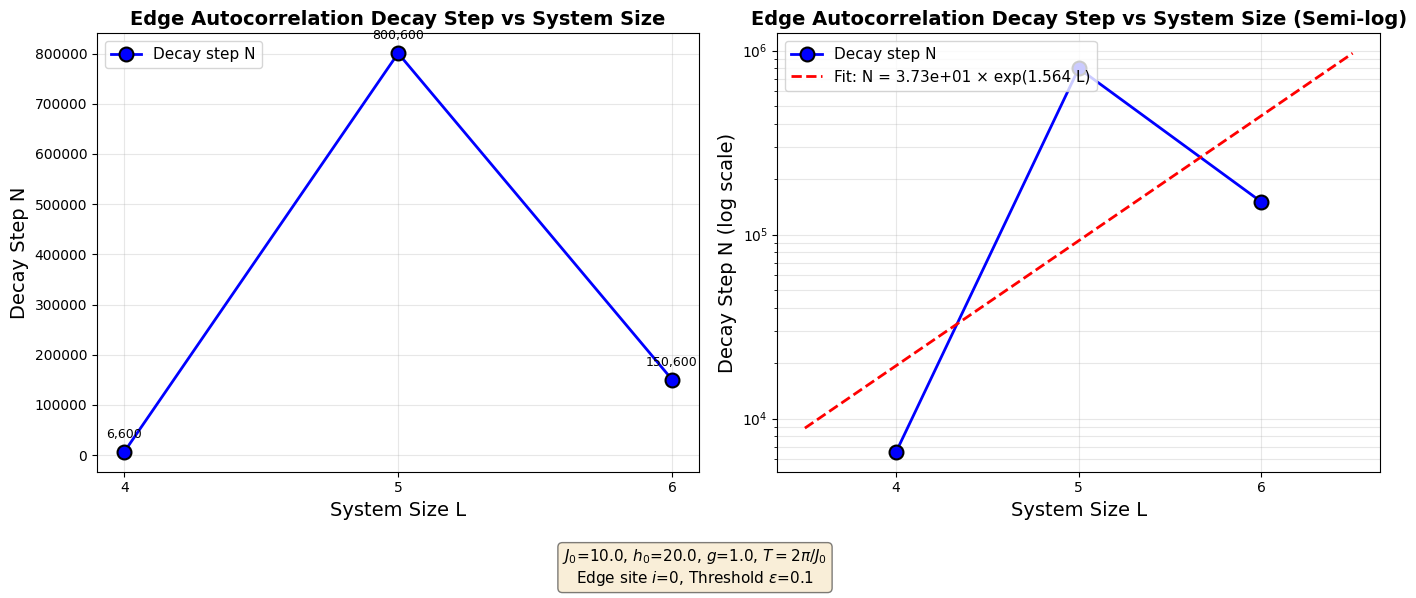


Plot saved as 'decay_step_vs_L.png'


In [66]:
# ============================================
# STEP 4: PLOT DECAY STEP N vs SYSTEM SIZE L
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 70)
print("PLOTTING DECAY STEP N vs SYSTEM SIZE L")
print("=" * 70)

# Extract data for plotting
L_array = np.array(results['L'])
decay_steps = np.array(results['decay_step'])

# Check which L values have valid decay steps
valid_mask = decay_steps != None
L_valid = L_array[valid_mask]
N_valid = decay_steps[valid_mask].astype(float)

# Print the data
print("\nData for N vs L plot:")
print(f"{'L':<6} {'Decay Step N':<20} {'log10(N)':<15}")
print("-" * 45)
for i, L in enumerate(results['L']):
    N = results['decay_step'][i]
    if N is not None:
        print(f"{L:<6} {N:<20,} {np.log10(N):<15.4f}")
    else:
        print(f"{L:<6} {'Not reached':<20} {'N/A':<15}")

# Count valid vs invalid
num_valid = len(L_valid)
num_invalid = len(L_array) - num_valid
print(f"\nValid decay points: {num_valid}/{len(L_array)}")
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    print(f"L values that did not decay: {invalid_L.tolist()}")

# ============================================
# CREATE PLOT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== Panel 1: Linear scale ==========
ax1 = axes[0]

if num_valid > 0:
    ax1.plot(L_valid, N_valid, 'bo-', markersize=10, linewidth=2,
             markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5,
             label='Decay step N')

    # Add data labels
    for i, (L, N) in enumerate(zip(L_valid, N_valid)):
        ax1.annotate(f'{int(N):,}', (L, N), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

# Mark L values that didn't decay
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    # Plot at max_steps with different marker
    ax1.plot(invalid_L, [max_steps] * len(invalid_L), 'r^', markersize=12,
             markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5,
             label=f'Not decayed (>{max_steps:,} steps)')

ax1.set_xlabel('System Size L', fontsize=14)
ax1.set_ylabel('Decay Step N', fontsize=14)
ax1.set_title('Edge Autocorrelation Decay Step vs System Size',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(L_values)

# ========== Panel 2: Semi-log scale (log N vs L) ==========
ax2 = axes[1]

if num_valid > 0:
    ax2.semilogy(L_valid, N_valid, 'bo-', markersize=10, linewidth=2,
                 markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5,
                 label='Decay step N')

    # Attempt exponential fit: N = a * exp(b * L)
    if len(L_valid) >= 3:
        # Linear fit to log(N) vs L
        log_N = np.log(N_valid)
        coeffs = np.polyfit(L_valid, log_N, 1)
        b_fit = coeffs[0]
        a_fit = np.exp(coeffs[1])

        # Plot fit line
        L_fit = np.linspace(min(L_valid) - 0.5, max(L_valid) + 0.5, 100)
        N_fit = a_fit * np.exp(b_fit * L_fit)
        ax2.semilogy(L_fit, N_fit, 'r--', linewidth=2,
                     label=f'Fit: N = {a_fit:.2e} × exp({b_fit:.3f} L)')

        print(f"\nExponential fit: N = {a_fit:.4e} × exp({b_fit:.4f} × L)")
        print(f"  Doubling length scale: L* = ln(2)/{b_fit:.4f} = {np.log(2)/b_fit:.2f}")

# Mark L values that didn't decay
if num_invalid > 0:
    invalid_L = L_array[~valid_mask]
    ax2.semilogy(invalid_L, [max_steps] * len(invalid_L), 'r^', markersize=12,
                 markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5,
                 label=f'Not decayed (>{max_steps:,} steps)')

ax2.set_xlabel('System Size L', fontsize=14)
ax2.set_ylabel('Decay Step N (log scale)', fontsize=14)
ax2.set_title('Edge Autocorrelation Decay Step vs System Size (Semi-log)',
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xticks(L_values)

# Add parameter text box
param_text = (f'$J_0$={J_0}, $h_0$={h_0}, $g$={g}, $T=2\\pi/J_0$\n'
              f'Edge site $i$=0, Threshold $\\varepsilon$={epsilon}')
fig.text(0.5, 0.02, param_text, ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig('decay_step_vs_L.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'decay_step_vs_L.png'")

# Hilbert space fragmentation

**First-order Floquet Hamiltonian:**

We calculated the Floquet Hamiltonian using Floquet perturbation theory (FPT) and the first-order matrix elements of the Floquet Hamiltonian in the eigenbasis of $\mathcal{O}=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z
+h_0\sum_{i=1}^{L}\sigma_i^z,$ where, $\mathcal{O}|m\rangle=P_m|m\rangle$ and $P_{nm}=P_n-P_m,$ are:
$$
(H_F^{(1)})_{nm}
=-\Big\langle n\big|g\sum_{i=1}^{L}\sigma_i^x\big|m\Big\rangle\,\left[
\delta_{P_{nm},0}+(1-\delta_{P_{nm},0})
\operatorname{sinc}\!\Big(\frac{P_{nm}T}{4\hbar}\Big)e^{-\,\tfrac{i}{\hbar}P_{nm}\tfrac{T}{4}}\right].
$$


**Selection rules:**

Driving the chain with different driving periods allow for selection rules as to which spins on the chain are allowed to flip, i.e., ($H_F^{(1)})_{nm} \neq 0$ in first order FPT at $h_0=2J_0$:

| $T$                   | $P = 0$         | $P = 2J_0$ (edge)     | $P = 4J_0$         | $P = 6J_0$ (edge)     | $P = 8J_0$         | Summary                      |
|------------------------|----------------|------------------------|--------------------|------------------------|--------------------|-------------------------------|
| $\frac{\pi}{2J_0}$    | on $(0)$       | on $(\frac{\pi}{4})$   | on $(\frac{\pi}{2})$ | on $(\frac{3\pi}{4})$ | off $(\pi)$        | only $|P| = 8J_0$ killed      |
| $\frac{\pi}{J_0}$     | on $(0)$       | on $(\frac{\pi}{2})$   | off $(\pi)$         | on $(\frac{3\pi}{2})$ | off $(2\pi)$       | kills $|P| = 4, 8$            |
| $\frac{2\pi}{J_0}$    | on $(0)$       | off $(\pi)$            | off $(2\pi)$        | off $(3\pi)$          | off $(4\pi)$       | all nonzero $P$ killed        |

**Footnotes:**  
“on/off” indicates whether $\operatorname{sinc}(PT/4)$ is nonzero/zero.  
Write $P=2kJ_0$ with an integer $k,$ (here $k\in\{0,1,2,3,4\}$ for OBC single flips).  
If $T=\frac{2\pi p}{J_0}$ with $p\in\mathbb{Z}^+$, then $(PT/4)=k\,p\,\pi$, so all channels with $k\neq0$ are at Sinc zeros and switch off.  
For OBC, $P=2J_0$ and $P=6J_0$ arise only from *edge* flips (one neighbor), whereas $P=0,4J_0,8J_0$ are from *middle* flips (two neighbors).
$$
\boxed{\;
(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\delta_{P_{nm},0},
\;}
$$


## Building the $\mathcal{O}$ operator for open boundary conditions:

$$\mathcal{O}:=J_0\sum_{i=1}^{L-1}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$$

In [67]:
# ============================================================
# PART 1: FRAGMENT ANALYSIS — OPERATOR O CONSTRUCTION (OBC)
#         NATIVE IMPLEMENTATION (No QuSpin dependency)
# ============================================================
#
# Drop-in replacement for the QuSpin-based build_O_operator.
# Follows the Hamiltonian bit convention from Prompt 1:
#
#   Site j  →  bit position p(j) = L - 1 - j
#   z_j(s)  = 1 - 2*c_j,   c_j = (s >> (L-1-j)) & 1
#
# THEOREM (Convention Independence for OBC):
#   For O = J0 Σ σ^z_i σ^z_{i+1} + 2J0 Σ σ^z_i on an open chain,
#   O_s is identical whether site j → bit j or bit (L-1-j).
#   Proof: Z part depends only on popcount(s);
#          ZZ part sums XOR of adjacent bit pairs — same set either way.
#   Consequence: Part 2 code works UNCHANGED.
# ============================================================

import numpy as np
from collections import deque


def build_O_operator(L, J0):
    """
    Build the diagonal operator O for Hilbert space fragmentation.

        O = J0 * Σ_{i=0}^{L-2} σ^z_i σ^z_{i+1}  +  2*J0 * Σ_{i=0}^{L-1} σ^z_i

    Open boundary conditions: (L-1) ZZ bonds, no wrap-around.

    Convention (matching build_H_floquet):
        Site j  →  bit position p(j) = L - 1 - j
        c_j(s)  = (s >> (L-1-j)) & 1
        z_j(s)  = 1 - 2*c_j(s)
        z_i * z_{i+1} = 1 - 2*(c_i XOR c_{i+1})

    Parameters
    ----------
    L : int
        Number of sites.  Must be >= 2.
    J0 : float
        Coupling constant.

    Returns
    -------
    O_diag : ndarray, shape (2**L,), dtype float64
        Diagonal elements O_n = <n|O|n> indexed by state integer.

    Complexity
    ----------
    Time  :  O(N * L)   where N = 2^L
    Memory:  O(N)       (single 1D array; no matrix constructed)
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")

    N = 1 << L
    states = np.arange(N, dtype=np.int64)
    diag = np.zeros(N, dtype=np.float64)

    # ---- ZZ contribution: J0 * Σ_{i=0}^{L-2} z_i * z_{i+1} ----
    for i in range(L - 1):
        pi  = L - 1 - i       # bit position for site i
        pi1 = L - 2 - i       # bit position for site i+1
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += J0 * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # ---- Z contribution: 2*J0 * Σ_{i=0}^{L-1} z_i ----
    for i in range(L):
        pi = L - 1 - i        # bit position for site i
        ci = (states >> pi) & 1
        diag += 2.0 * J0 * (1.0 - 2.0 * ci.astype(np.float64))

    return diag


# ============================================
# TEST: Build O operator
# ============================================

print("\n" + "=" * 60)
print("PART 1: Building Operator O for Fragment Identification (OBC)")
print("         NATIVE (no QuSpin) — Hamiltonian bit convention")
print("=" * 60)

# Parameters for fragmentation analysis
L_frag = 10
J0_frag = 10.0

print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}")
print(f"Boundary conditions: OPEN (L-1 = {L_frag - 1} ZZ bonds)")

# Build O diagonal
O_diag = build_O_operator(L_frag, J0_frag)
Ns = 2 ** L_frag

print(f"O_diag shape: {O_diag.shape}")
print(f"Hilbert space dimension: Ns = {Ns}")

# ---- Verify with hand computation ----
# Convention: bit=0 → UP (σ^z = +1), bit=1 → DOWN (σ^z = -1)
#
# For OPEN BC with L sites: (L-1) ZZ bonds, no wrap-around.
#
# State 0 (all bits=0) = all UP:
#   ZZ: (+1)(+1) * (L-1) bonds → (L-1)*J0
#   Z:  2*J0*(+1)*L            → 2*L*J0
#   Total: (3L-1)*J0
#
# State 2^L - 1 (all bits=1) = all DOWN:
#   ZZ: (-1)(-1) * (L-1) bonds → (L-1)*J0
#   Z:  2*J0*(-1)*L            → -2*L*J0
#   Total: -(L+1)*J0

N_all_down = Ns - 1  # = 1023 for L=10

expected_all_up   = (3 * L_frag - 1) * J0_frag     # = 290
expected_all_down = -(L_frag + 1) * J0_frag         # = -110

print(f"\nVerification (OBC, L={L_frag}):")
print(f"  O_diag[0]    = {O_diag[0]:.1f}  "
      f"(all UP,   expected: (3·{L_frag}-1)·{J0_frag:.0f} = {expected_all_up:.0f})")
print(f"  O_diag[{N_all_down}] = {O_diag[N_all_down]:.1f}  "
      f"(all DOWN, expected: -({L_frag}+1)·{J0_frag:.0f} = {expected_all_down:.0f})")

assert np.isclose(O_diag[0], expected_all_up), \
    f"All-up failed: {O_diag[0]} != {expected_all_up}"
assert np.isclose(O_diag[N_all_down], expected_all_down), \
    f"All-down failed: {O_diag[N_all_down]} != {expected_all_down}"
print("  ✓ Verification passed!")

# ---- Value distribution ----
unique_vals = np.unique(O_diag)
print(f"\n  Distinct O values: {len(unique_vals)}")
print(f"  Range: [{O_diag.min():.1f}, {O_diag.max():.1f}]")

print("\n" + "=" * 60)
print("Part 1 complete: O operator built successfully (OBC)")
print("  • No QuSpin dependency")
print("  • Convention: site j → bit (L-1-j)  [matches build_H_floquet]")
print("  • Convention-independent output (identical to QuSpin)")
print("=" * 60)


PART 1: Building Operator O for Fragment Identification (OBC)
         NATIVE (no QuSpin) — Hamiltonian bit convention

Parameters: L = 10, J0 = 10.0
Boundary conditions: OPEN (L-1 = 9 ZZ bonds)
O_diag shape: (1024,)
Hilbert space dimension: Ns = 1024

Verification (OBC, L=10):
  O_diag[0]    = 290.0  (all UP,   expected: (3·10-1)·10 = 290)
  O_diag[1023] = -110.0  (all DOWN, expected: -(10+1)·10 = -110)
  ✓ Verification passed!

  Distinct O values: 19
  Range: [-110.0, 290.0]

Part 1 complete: O operator built successfully (OBC)
  • No QuSpin dependency
  • Convention: site j → bit (L-1-j)  [matches build_H_floquet]
  • Convention-independent output (identical to QuSpin)


## Connectivity graph and largest fragment:

In [68]:
# ============================================================
# PART 2: CONNECTIVITY GRAPH AND FRAGMENT IDENTIFICATION
#         WITH ↑↑ BOND ANALYSIS (OPEN BOUNDARY CONDITIONS)
# ============================================================

from collections import deque

def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition P_nm = 0)

    Parameters:
    -----------
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal elements of O operator
    tol : float
        Tolerance for resonance condition

    Returns:
    --------
    adjacency : list of lists
        adjacency[n] = list of neighbors of state n
    num_edges : int
        Total number of edges
    """
    Ns = 2**L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]

        # Find single-flip neighbors (flip each bit)
        for i in range(L):
            m = n ^ (1 << i)  # Flip bit i

            if m > n:  # Count each edge once
                O_m = O_diag[m]
                P_nm = O_n - O_m

                if abs(P_nm) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters:
    -----------
    adjacency : list of lists
        Adjacency list representation of graph

    Returns:
    --------
    components : list of lists
        Each element is a list of state indices in that fragment
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            # BFS from this node
            component = []
            queue = deque([start])
            visited[start] = True

            while queue:
                node = queue.popleft()
                component.append(node)

                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)

            components.append(sorted(component))

    return components


def get_fragment_statistics(components):
    """
    Compute statistics about the fragments.
    """
    sizes = [len(c) for c in components]

    stats = {
        'num_fragments': len(components),
        'sizes': sorted(sizes),
        'max_size': max(sizes),
        'min_size': min(sizes),
        'num_singletons': sum(1 for s in sizes if s == 1)
    }

    # Size distribution
    size_counts = {}
    for s in sizes:
        size_counts[s] = size_counts.get(s, 0) + 1
    stats['size_counts'] = size_counts

    return stats


def find_largest_fragment(components):
    """
    Return the largest fragment (list of state indices).
    """
    return max(components, key=len)


def get_spin_config(state_idx, L):
    """
    Get spin configuration string for a state.
    QuSpin convention: bit=0 → UP (↑), bit=1 → DOWN (↓)
    """
    spins = []
    for i in range(L):
        bit = (state_idx >> i) & 1
        spins.append('↓' if bit else '↑')
    return ''.join(spins)


# ============================================================
# STEP 1: Helper functions for ↑↑ bonds and N_defect (OBC)
# ============================================================

def get_spin_array(state_idx, L):
    """
    Convert state index n into an array S[i] = ±1 with the same convention
    as get_spin_config: bit=0 -> up (+1), bit=1 -> down (-1).
    """
    S = np.empty(L, dtype=int)
    for i in range(L):
        bit = (state_idx >> i) & 1
        S[i] = +1 if bit == 0 else -1
    return S


def get_upup_bond_pattern(state_idx, L):
    """
    Return a length-(L-1) integer array p where
        p[i] = 1 if bond (i, i+1) is ↑↑
             = 0 otherwise,
    using OPEN boundary conditions (no wrap-around).

    Bonds: 0-1, 1-2, 2-3, ..., (L-2)-(L-1)
    Total: L-1 bonds
    """
    S = get_spin_array(state_idx, L)
    p = np.zeros(L - 1, dtype=int)  # L-1 bonds for OBC
    for i in range(L - 1):
        # ↑↑ means S[i] = +1 and S[i+1] = +1
        if S[i] == +1 and S[i + 1] == +1:
            p[i] = 1
    return p


def get_N_defect(state_idx, L):
    """
    Number of ↑↑ bonds in the configuration (OBC: L-1 bonds total).
    """
    p = get_upup_bond_pattern(state_idx, L)
    return int(p.sum())


def bond_pattern_to_string(p):
    """
    Convert an integer array p[i] in {0,1} to a string '0101...'.
    """
    return ''.join(str(x) for x in p)


# ============================================================
# STEP 3: Extended display functions with N_defect and bond pattern
# ============================================================

def display_fragment_states(fragment_states, L, O_diag, adjacency,
                            N_defect_all=None, bond_patterns_all=None):
    """
    Display detailed information about states in a fragment.

    Parameters:
    -----------
    fragment_states : list
        List of state indices in the fragment
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states
    """
    # Adjust column width for L-1 bonds
    bond_width = L + 1
    print(f"  {'#':<4} {'Index':<8} {'Binary':<{L+2}} {'Spins':<{L+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)':<{bond_width}} {'Neighbors'}")
    print("  " + "-"*(55 + 3*L))

    for i, state_idx in enumerate(fragment_states):
        binary_str = format(state_idx, f'0{L}b')
        spin_str = get_spin_config(state_idx, L)
        O_val = O_diag[state_idx]

        N_def = N_defect_all[state_idx] if N_defect_all is not None else 0
        if bond_patterns_all is not None:
            p = bond_patterns_all[state_idx]
            if isinstance(p, np.ndarray):
                bond_str = bond_pattern_to_string(p)
            else:
                bond_str = str(p)
        else:
            bond_str = ""

        # Get neighbors within fragment
        neighbors_in_frag = [m for m in adjacency[state_idx] if m in fragment_states]
        neighbors_str = str(neighbors_in_frag) if neighbors_in_frag else "[]"

        print(f"  {i+1:<4} {state_idx:<8} {binary_str:<{L+2}} {spin_str:<{L+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str:<{bond_width}} {neighbors_str}")


def display_all_fragments(components, L, O_diag, adjacency,
                          N_defect_all=None, bond_patterns_all=None,
                          sort_by_size=True, show_singletons=True, max_display=None):
    """
    Display detailed information about ALL fragments.

    Parameters:
    -----------
    components : list of lists
        List of fragments (each fragment is a list of state indices)
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states
    sort_by_size : bool
        If True, sort fragments by size (largest first)
    show_singletons : bool
        If True, show singleton fragments (size=1)
    max_display : int or None
        Maximum number of fragments to display (None = all)
    """
    # Sort fragments by size if requested
    if sort_by_size:
        sorted_components = sorted(components, key=len, reverse=True)
    else:
        sorted_components = components

    # Filter singletons if requested
    if not show_singletons:
        sorted_components = [c for c in sorted_components if len(c) > 1]

    # Limit display if requested
    if max_display is not None:
        sorted_components = sorted_components[:max_display]

    total_fragments = len(components)
    displayed_fragments = len(sorted_components)

    print(f"\n{'='*90}")
    print(f"DETAILED FRAGMENT DATA (Showing {displayed_fragments} of {total_fragments} fragments)")
    print(f"{'='*90}")

    for frag_idx, fragment in enumerate(sorted_components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]

        # Count internal edges
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        # Get N_defect info for this fragment
        if N_defect_all is not None:
            N_vals = set(N_defect_all[s] for s in fragment)
            N_def_str = f", N_defect = {N_vals}"
        else:
            N_def_str = ""

        print(f"\n{'─'*90}")
        print(f"FRAGMENT {frag_idx + 1}: D = {D} states, O = {O_val:.2f}, "
              f"Internal edges = {internal_edges}{N_def_str}")
        print(f"{'─'*90}")

        display_fragment_states(fragment, L, O_diag, adjacency,
                                N_defect_all, bond_patterns_all)

    print(f"\n{'='*90}")
    print(f"End of fragment data")
    print(f"{'='*90}")


# ============================================================
# STEP 4: Fragment-level analysis with N_defect and bond patterns
# ============================================================

def create_fragment_summary_table(components, L, O_diag, adjacency,
                                  N_defect_all=None, bond_patterns_all=None):
    """
    Create a summary table of all fragments with N_defect and bond pattern analysis.

    Parameters:
    -----------
    components : list of lists
        List of fragments
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal of O operator
    adjacency : list of lists
        Adjacency list for connectivity
    N_defect_all : ndarray, optional
        Array of N_defect values for all states
    bond_patterns_all : list, optional
        List of bond pattern arrays for all states

    Returns:
    --------
    summary : list of dict
        List of dictionaries with fragment summary info
    """
    summary = []

    for frag_idx, fragment in enumerate(components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]

        # Count internal edges
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        # N_defect consistency check
        if N_defect_all is not None:
            N_vals = [N_defect_all[s] for s in fragment]
            N_def_unique = sorted(set(N_vals))
        else:
            N_def_unique = []

        # Bond pattern consistency check
        if bond_patterns_all is not None:
            # Convert to strings for easy comparison
            patterns = [bond_pattern_to_string(bond_patterns_all[s])
                        for s in fragment]
            patterns_unique = sorted(set(patterns))
        else:
            patterns_unique = []

        summary.append({
            'fragment_id': frag_idx + 1,
            'size': D,
            'O_value': O_val,
            'internal_edges': internal_edges,
            'states': fragment,
            'N_defect_values': N_def_unique,
            'bond_patterns': patterns_unique,
        })

    # Sort by size (descending)
    summary.sort(key=lambda x: x['size'], reverse=True)

    return summary


def print_fragment_summary_table(summary, L):
    """
    Print a compact summary table of all fragments with N_defect and bond pattern info.
    """
    # Adjust column width for L-1 bonds
    pattern_width = L + 1
    print(f"\n{'='*110}")
    print("FRAGMENT SUMMARY TABLE (with ↑↑ bond analysis, OBC)")
    print(f"{'='*110}")
    print(f"{'ID':<6} {'Size':<8} {'O value':<12} {'Edges':<8} "
          f"{'#N_def':<8} {'#patterns':<12} {'N_def':<8} {'Example pattern':<{pattern_width}}")
    print(f"{'-'*110}")

    for frag in summary:
        N_list = frag.get('N_defect_values', [])
        pat_list = frag.get('bond_patterns', [])
        num_N = len(N_list)
        num_pat = len(pat_list)
        example_pat = pat_list[0] if pat_list else ''
        example_N = str(N_list[0]) if N_list else ''

        print(f"{frag['fragment_id']:<6} {frag['size']:<8} {frag['O_value']:<12.2f} "
              f"{frag['internal_edges']:<8} {num_N:<8} {num_pat:<12} "
              f"{example_N:<8} {example_pat:<{pattern_width}}")

    print(f"{'='*110}")


# ============================================================
# STEP 6: Fibonacci check helper
# ============================================================

def fib(n):
    """
    Compute the n-th Fibonacci number (F_0 = 0, F_1 = 1, F_2 = 1, ...).
    """
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ============================================
# TEST: Build connectivity graph and find fragments
# ============================================

print("\n" + "="*60)
print("PART 2: Building Connectivity Graph and Finding Fragments")
print("        (with ↑↑ bond analysis, OPEN BOUNDARY CONDITIONS)")
print("="*60)

tol = 1e-10
print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}, tol = {tol}")
print(f"Boundary conditions: OPEN (L-1 = {L_frag-1} bonds)")

# ============================================
# STEP 2: Precompute N_defect and bond patterns for all states
# ============================================

print("\nPrecomputing N_defect and ↑↑ bond patterns for all states (OBC)...")
N_defect_all = np.zeros(Ns, dtype=int)
bond_patterns_all = [None] * Ns

for n in range(Ns):
    p = get_upup_bond_pattern(n, L_frag)
    bond_patterns_all[n] = p
    N_defect_all[n] = int(p.sum())

print(f"  N_defect range: {N_defect_all.min()} to {N_defect_all.max()}")
print(f"  N_defect distribution:")
for n_val in range(N_defect_all.max() + 1):
    count = np.sum(N_defect_all == n_val)
    if count > 0:
        print(f"    N_defect = {n_val}: {count} states")

# Build connectivity graph
print("\nBuilding connectivity graph...")
adjacency, num_edges = build_connectivity_graph(L_frag, O_diag, tol)

total_possible_edges = Ns * L_frag // 2
print(f"  Number of edges: {num_edges}")
print(f"  Total possible edges (all single-flips): {total_possible_edges}")
print(f"  Fraction kept: {num_edges / total_possible_edges:.4f}")

# Find connected components
print("\nFinding connected components...")
components = find_connected_components(adjacency)
stats = get_fragment_statistics(components)

print(f"\n  Number of fragments: {stats['num_fragments']}")
print(f"  Largest fragment size: {stats['max_size']}")
print(f"  Number of singletons: {stats['num_singletons']}")

# Size distribution
print("\n  Size distribution:")
print(f"    {'Size':<8} {'Count':<8} {'Total':<8}")
print("    " + "-"*24)
for size in sorted(stats['size_counts'].keys()):
    count = stats['size_counts'][size]
    print(f"    {size:<8} {count:<8} {size*count:<8}")

# Get largest fragment
largest_fragment = find_largest_fragment(components)
D_largest = len(largest_fragment)

print(f"\n  Largest fragment has D = {D_largest} states")
print(f"  O value in largest fragment: {O_diag[largest_fragment[0]]:.1f}")

# Verify total
total_states = sum(len(c) for c in components)
assert total_states == Ns, f"Total states mismatch: {total_states} != {Ns}"
print(f"\n  Total states across all fragments: {total_states} = Ns ✓")

# ============================================
# Display summary table for all fragments (with ↑↑ bond analysis)
# ============================================
fragment_summary = create_fragment_summary_table(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all
)
print_fragment_summary_table(fragment_summary, L_frag)

# ============================================
# STEP 5: Sanity checks and diagnostics
# ============================================

print("\n" + "="*70)
print("↑↑ BOND PATTERN ANALYSIS (OBC)")
print("="*70)

# Count fragments with exactly one frozen bond pattern
num_single_pattern = sum(1 for frag in fragment_summary
                         if len(frag['bond_patterns']) == 1)
print(f"\nFragments with a single frozen ↑↑-bond pattern: "
      f"{num_single_pattern}/{len(fragment_summary)}")

# Count fragments with exactly one N_defect value
num_single_N = sum(1 for frag in fragment_summary
                   if len(frag['N_defect_values']) == 1)
print(f"Fragments with a single N_defect value: "
      f"{num_single_N}/{len(fragment_summary)}")

# Largest fragment details
largest = fragment_summary[0]
print("\nLargest fragment details:")
print(f"  ID: {largest['fragment_id']}")
print(f"  Size: {largest['size']}")
print(f"  O value: {largest['O_value']:.2f}")
print(f"  N_defect values: {largest['N_defect_values']}")
print(f"  Bond patterns: {largest['bond_patterns']}")
print(f"  Number of distinct patterns: {len(largest['bond_patterns'])}")

# Verify largest fragment has no ↑↑ bonds
if largest['N_defect_values'] == [0]:
    print("  ✓ Largest fragment has N_defect = 0 (no ↑↑ bonds)")
else:
    print(f"  ⚠ Largest fragment has N_defect = {largest['N_defect_values']}")

if largest['bond_patterns'] == ['0' * (L_frag - 1)]:
    print(f"  ✓ Bond pattern is all zeros: {'0' * (L_frag - 1)}")

# ============================================
# STEP 6: Fibonacci check for largest fragment (OBC) - CORRECTED
# ============================================

print("\n" + "-"*70)
print("Fibonacci consistency check (no adjacent ↑ on LINEAR CHAIN):")
print("-"*70)

# CORRECTED: For OBC with L sites, the largest fragment dimension is F_L
# This corresponds to configurations with no ↑↑ bonds on a linear chain.
dim_no_adj_chain = fib(L_frag)
print(f"  L = {L_frag}")
print(f"  F_{L_frag} = {dim_no_adj_chain}")
print(f"  Predicted dimension (no adjacent ↑ on chain): F_{L_frag} = {dim_no_adj_chain}")
print(f"  Largest fragment size: {D_largest}")

if D_largest == dim_no_adj_chain:
    print(f"  ✓ Matches! Largest fragment = configurations with no ↑↑ bonds (OBC)")
else:
    print(f"  ⚠ Mismatch: {D_largest} ≠ {dim_no_adj_chain}")
    print(f"  Note: Empirical result shows D_largest = {D_largest}")

# ============================================
# Display detailed data for ALL non-singleton fragments
# ============================================
display_all_fragments(
    components,
    L_frag,
    O_diag,
    adjacency,
    N_defect_all,
    bond_patterns_all,
    sort_by_size=True,      # Show largest fragments first
    show_singletons=False,  # Skip singletons (size=1) for cleaner output
    max_display=None        # Show all non-singleton fragments
)

# ============================================
# OPTIONAL: Display singletons separately (with N_defect info)
# ============================================
singleton_count = stats['num_singletons']
if singleton_count > 0:
    bond_width = L_frag + 1
    print(f"\n{'='*80}")
    print(f"SINGLETON FRAGMENTS (Size = 1): {singleton_count} total")
    print(f"{'='*80}")
    print(f"  {'Index':<8} {'Binary':<{L_frag+2}} {'Spins':<{L_frag+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)'}")
    print("  " + "-"*(50 + 3*L_frag))

    singletons = [c[0] for c in components if len(c) == 1]
    singletons.sort()  # Sort by state index

    for state_idx in singletons:
        binary_str = format(state_idx, f'0{L_frag}b')
        spin_str = get_spin_config(state_idx, L_frag)
        O_val = O_diag[state_idx]
        N_def = N_defect_all[state_idx]
        bond_str = bond_pattern_to_string(bond_patterns_all[state_idx])
        print(f"  {state_idx:<8} {binary_str:<{L_frag+2}} {spin_str:<{L_frag+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str}")

print("\n" + "="*60)
print("Part 2 complete: Fragments identified successfully")
print("              (with ↑↑ bond conservation analysis, OBC)")
print("="*60)


PART 2: Building Connectivity Graph and Finding Fragments
        (with ↑↑ bond analysis, OPEN BOUNDARY CONDITIONS)

Parameters: L = 10, J0 = 10.0, tol = 1e-10
Boundary conditions: OPEN (L-1 = 9 bonds)

Precomputing N_defect and ↑↑ bond patterns for all states (OBC)...
  N_defect range: 0 to 9
  N_defect distribution:
    N_defect = 0: 144 states
    N_defect = 1: 235 states
    N_defect = 2: 241 states
    N_defect = 3: 187 states
    N_defect = 4: 116 states
    N_defect = 5: 62 states
    N_defect = 6: 25 states
    N_defect = 7: 11 states
    N_defect = 8: 2 states
    N_defect = 9: 1 states

Building connectivity graph...
  Number of edges: 1024
  Total possible edges (all single-flips): 5120
  Fraction kept: 0.2000

Finding connected components...

  Number of fragments: 351
  Largest fragment size: 55
  Number of singletons: 169

  Size distribution:
    Size     Count    Total   
    ------------------------
    1        169      169     
    2        76       152     
    3  

## Hilbert space fragmentation analysis



### Functions from fragmentation analysis

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ============================================================
# CORE FUNCTIONS FROM FRAGMENTATION CODE
# ============================================================

def build_O_operator(L, J0):
    """
    Build the diagonal operator O = J0 * Σ σ^z_i σ^z_{i+1} + 2*J0 * Σ σ^z_i

    This is for OPEN boundary conditions (L-1 ZZ bonds, NO wrap-around).

    Parameters:
    -----------
    L : int
        Number of sites
    J0 : float
        Coupling constant

    Returns:
    --------
    O_diag : ndarray, shape (2**L,)
        Diagonal elements O_n = <n|O|n> indexed by state integer
    """
    # Build basis
    basis = spin_basis_1d(L, pauli=1)

    # ZZ interaction (open BC: L-1 bonds, NO wrap-around)
    zz_list = [[J0, i, i + 1] for i in range(L - 1)]

    # Z field: 2*J0 * σ^z_i
    z_list = [[2.0 * J0, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list]]

    O = hamiltonian(static, [], basis=basis, dtype=np.float64,
                   check_symm=False, check_herm=False)

    O_diag = np.array(O.diagonal())

    return O_diag


def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition)

    Parameters:
    -----------
    L : int
        Number of sites
    O_diag : ndarray
        Diagonal elements of O operator
    tol : float
        Tolerance for resonance condition

    Returns:
    --------
    adjacency : list of lists
        adjacency[n] = list of neighbors of state n
    num_edges : int
        Total number of edges
    """
    Ns = 2**L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]

        # Find single-flip neighbors (flip each bit)
        for i in range(L):
            m = n ^ (1 << i)  # Flip bit i

            if m > n:  # Count each edge once
                O_m = O_diag[m]
                P_nm = O_n - O_m

                if abs(P_nm) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters:
    -----------
    adjacency : list of lists
        Adjacency list representation of graph

    Returns:
    --------
    components : list of lists
        Each element is a list of state indices in that fragment
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            # BFS from this node
            component = []
            queue = deque([start])
            visited[start] = True

            while queue:
                node = queue.popleft()
                component.append(node)

                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)

            components.append(sorted(component))

    return components


def fib(n):
    """
    Compute the n-th Fibonacci number (F_0 = 0, F_1 = 1, F_2 = 1, ...).
    """
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


print("="*70)
print("Step 1: All helper functions loaded successfully")
print("="*70)

Step 1: All helper functions loaded successfully


### Scan across all L values

In [70]:
# ============================================================
# STEP 2: Wrapper function and scan across L values
# ============================================================

def analyze_fragmentation_for_L(L, J0=10.0, tol=1e-10, verbose=False):
    """
    Run complete fragmentation analysis for a given system size L.

    Parameters:
    -----------
    L : int
        Number of sites
    J0 : float
        Coupling strength for O operator
    tol : float
        Tolerance for resonance condition
    verbose : bool
        Print detailed information

    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'L': system size
        - 'Ns': Hilbert space dimension (2^L)
        - 'num_fragments': total number of fragments
        - 'fragment_sizes': sorted list of fragment sizes
        - 'largest_size': dimension of largest fragment
        - 'smallest_size': dimension of smallest fragment
        - 'ratio': largest_size / smallest_size
        - 'num_singletons': number of singleton fragments
        - 'components': list of fragments (for detailed analysis)
        - 'O_diag': diagonal of O operator
    """
    if verbose:
        print(f"\nAnalyzing L = {L}...")

    # Build O operator
    O_diag = build_O_operator(L, J0)
    Ns = 2**L

    if verbose:
        print(f"  Built O operator: Ns = {Ns}")

    # Build connectivity graph
    adjacency, num_edges = build_connectivity_graph(L, O_diag, tol)

    if verbose:
        print(f"  Built connectivity graph: {num_edges} edges")

    # Find connected components
    components = find_connected_components(adjacency)

    # Extract statistics
    sizes = sorted([len(c) for c in components], reverse=True)
    largest_size = sizes[0]
    smallest_size = sizes[-1]
    ratio = largest_size / smallest_size if smallest_size > 0 else np.inf
    num_singletons = sum(1 for s in sizes if s == 1)

    results = {
        'L': L,
        'Ns': Ns,
        'num_fragments': len(components),
        'fragment_sizes': sizes,
        'largest_size': largest_size,
        'smallest_size': smallest_size,
        'ratio': ratio,
        'num_singletons': num_singletons,
        'components': components,
        'O_diag': O_diag,
        'adjacency': adjacency
    }

    if verbose:
        fib_L = fib(L)
        print(f"  Fragments = {len(components)}, Largest = {largest_size} (F_{L} = {fib_L})")
        print(f"  Smallest = {smallest_size}, Ratio = {ratio:.2f}")

    return results


def scan_fragmentation_vs_L(L_min, L_max, J0=10.0, tol=1e-10, verbose=True):
    """
    Run fragmentation analysis for a range of L values.

    Parameters:
    -----------
    L_min, L_max : int
        Range of system sizes to analyze
    J0 : float
        Coupling strength for O operator
    tol : float
        Tolerance for resonance condition
    verbose : bool
        Print progress information

    Returns:
    --------
    all_results : list of dict
        List of result dictionaries, one for each L
    """
    all_results = []
    L_values = range(L_min, L_max + 1)

    if verbose:
        print(f"\n{'='*70}")
        print(f"SCANNING FRAGMENTATION: L = {L_min} to {L_max}")
        print(f"Parameters: J0 = {J0}, tol = {tol}")
        print(f"{'='*70}")

    for L in L_values:
        results = analyze_fragmentation_for_L(L, J0=J0, tol=tol, verbose=verbose)
        all_results.append(results)

    if verbose:
        print(f"\n{'='*70}")
        print("Scan complete!")
        print(f"{'='*70}")

    return all_results


# Run the scan
L_min = 4
L_max = 12  # Can increase to 14-16 if computation time is acceptable

print("\n" + "="*70)
print("Running fragmentation analysis for multiple L values")
print("="*70)
print(f"Range: L = {L_min} to {L_max}")
print(f"Note: Hilbert space size grows as 2^L")
print(f"  L = {L_max}: Ns = {2**L_max} states")
print("="*70)

# Run the scan
scan_results = scan_fragmentation_vs_L(L_min, L_max, J0=10.0, tol=1e-10, verbose=True)

# Display summary table
print(f"\n{'='*85}")
print("SUMMARY TABLE: Fragment Dimensions vs L")
print(f"{'='*85}")
print(f"{'L':<4} {'Ns':<8} {'#Frag':<8} {'Largest':<10} {'F_L':<8} {'Smallest':<10} {'Ratio':<12} {'#Single':<10}")
print("-"*85)

for res in scan_results:
    fib_L = fib(res['L'])
    match = "✓" if res['largest_size'] == fib_L else "✗"
    print(f"{res['L']:<4} {res['Ns']:<8} {res['num_fragments']:<8} "
          f"{res['largest_size']:<10} {fib_L:<8}{match} {res['smallest_size']:<10} "
          f"{res['ratio']:<12.2f} {res['num_singletons']:<10}")

print("="*85)
print("\n✓ Step 2 complete: Data collected for all L values")


Running fragmentation analysis for multiple L values
Range: L = 4 to 12
Note: Hilbert space size grows as 2^L
  L = 12: Ns = 4096 states

SCANNING FRAGMENTATION: L = 4 to 12
Parameters: J0 = 10.0, tol = 1e-10

Analyzing L = 4...
  Built O operator: Ns = 16
  Built connectivity graph: 4 edges
  Fragments = 12, Largest = 3 (F_4 = 3)
  Smallest = 1, Ratio = 3.00

Analyzing L = 5...
  Built O operator: Ns = 32
  Built connectivity graph: 12 edges
  Fragments = 21, Largest = 5 (F_5 = 5)
  Smallest = 1, Ratio = 5.00

Analyzing L = 6...
  Built O operator: Ns = 64
  Built connectivity graph: 32 edges
  Fragments = 37, Largest = 8 (F_6 = 8)
  Smallest = 1, Ratio = 8.00

Analyzing L = 7...
  Built O operator: Ns = 128
  Built connectivity graph: 80 edges
  Fragments = 65, Largest = 13 (F_7 = 13)
  Smallest = 1, Ratio = 13.00

Analyzing L = 8...
  Built O operator: Ns = 256
  Built connectivity graph: 192 edges
  Fragments = 114, Largest = 21 (F_8 = 21)
  Smallest = 1, Ratio = 21.00

Analyzing 

### Plotting to show HSF


Creating enhanced plot with 4 panels


C:\Users\Rishi Paresh Joshi\AppData\Local\Temp\ipykernel_20612\2641081400.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ Figure saved to: fragment_analysis_vs_L.png


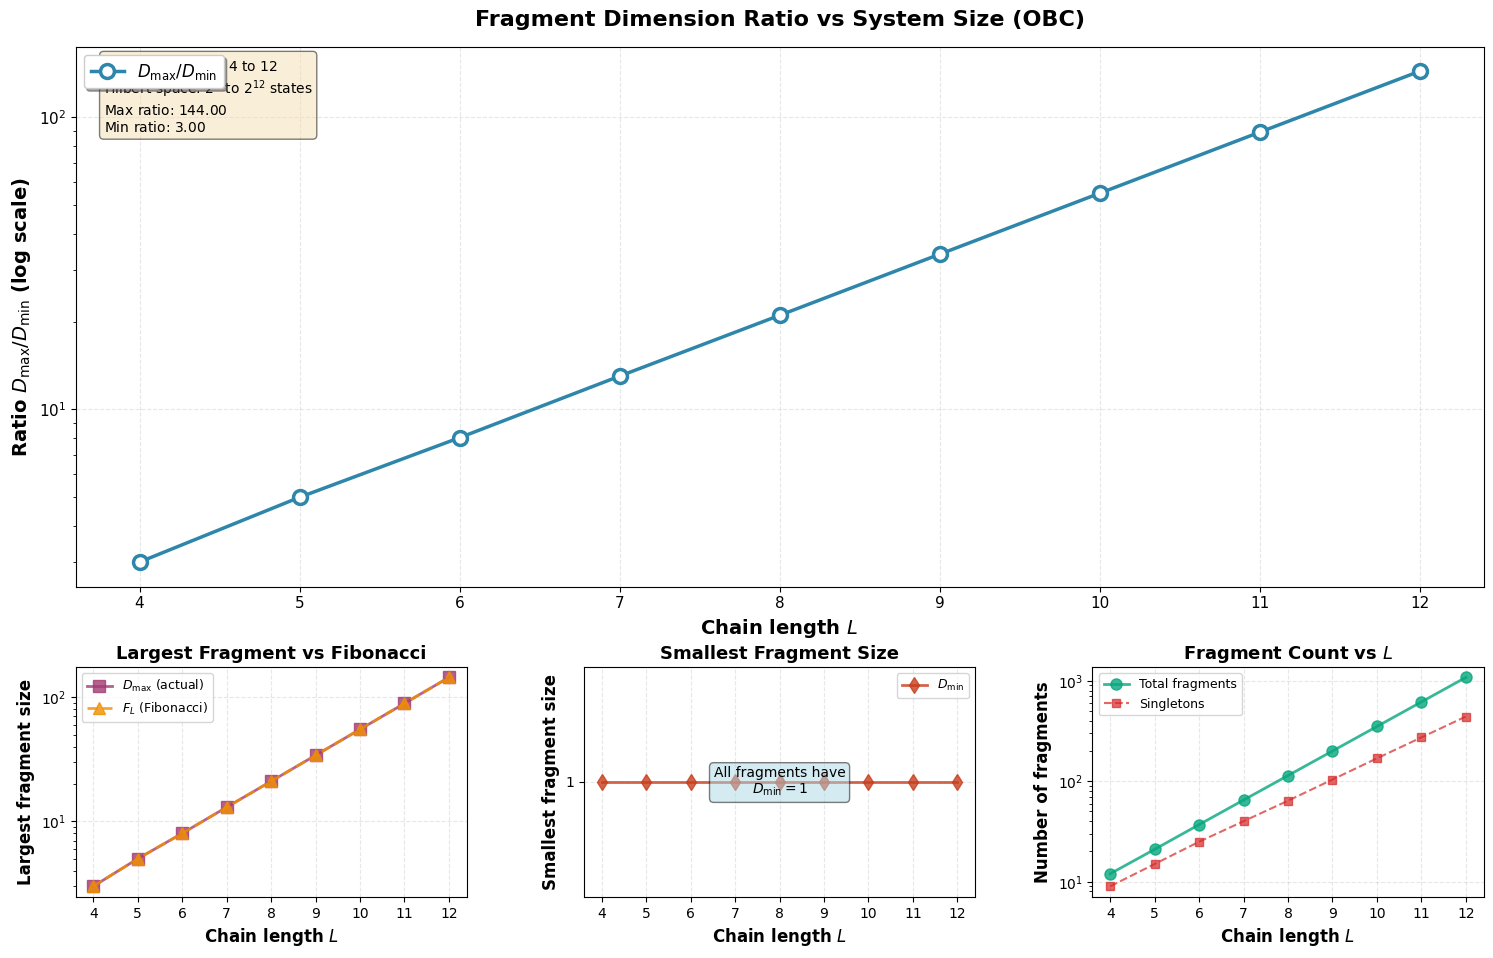


✓ Step 4 complete: Enhanced plot created successfully

ADDITIONAL STATISTICS
L =  4:   12 fragments,    9 singletons (75.0%), fragment density = 0.7500
L =  5:   21 fragments,   15 singletons (71.4%), fragment density = 0.6562
L =  6:   37 fragments,   25 singletons (67.6%), fragment density = 0.5781
L =  7:   65 fragments,   40 singletons (61.5%), fragment density = 0.5078
L =  8:  114 fragments,   64 singletons (56.1%), fragment density = 0.4453
L =  9:  200 fragments,  104 singletons (52.0%), fragment density = 0.3906
L = 10:  351 fragments,  169 singletons (48.1%), fragment density = 0.3428
L = 11:  616 fragments,  273 singletons (44.3%), fragment density = 0.3008
L = 12: 1081 fragments,  441 singletons (40.8%), fragment density = 0.2639


In [71]:
# ============================================================
# STEP 4: Enhanced plot including number of fragments vs L
# ============================================================

def plot_fragment_analysis_vs_L(scan_results, save_path=None):
    """
    Create comprehensive publication-quality plot with 4 panels:
    1. Ratio D_max/D_min vs L (main plot)
    2. Largest fragment size vs Fibonacci
    3. Smallest fragment size
    4. Number of fragments vs L (NEW)

    Parameters:
    -----------
    scan_results : list of dict
        Results from scan_fragmentation_vs_L
    save_path : str, optional
        Path to save the figure
    """
    # Extract data
    L_values = [res['L'] for res in scan_results]
    ratios = [res['ratio'] for res in scan_results]
    largest_sizes = [res['largest_size'] for res in scan_results]
    smallest_sizes = [res['smallest_size'] for res in scan_results]
    num_fragments = [res['num_fragments'] for res in scan_results]
    num_singletons = [res['num_singletons'] for res in scan_results]

    # Compute Fibonacci numbers for reference
    fib_values = [fib(L) for L in L_values]

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3,
                          left=0.08, right=0.96, top=0.93, bottom=0.08)

    # ============================================================
    # Main plot: Ratio vs L (spans top 2 rows)
    # ============================================================
    ax1 = fig.add_subplot(gs[0:2, :])
    ax1.plot(L_values, ratios, 'o-', color='#2E86AB', linewidth=2.5,
             markersize=10, markerfacecolor='white', markeredgewidth=2.5,
             markeredgecolor='#2E86AB', label='$D_{\\mathrm{max}}/D_{\\mathrm{min}}$')

    ax1.set_xlabel('Chain length $L$', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Ratio $D_{\\mathrm{max}}/D_{\\mathrm{min}}$', fontsize=14, fontweight='bold')
    ax1.set_title('Fragment Dimension Ratio vs System Size (OBC)',
                  fontsize=16, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=12, frameon=True, shadow=True, loc='upper left')
    ax1.tick_params(labelsize=11)

    # Use log scale for y-axis if ratios span multiple orders of magnitude
    if max(ratios) / min(ratios) > 10:
        ax1.set_yscale('log')
        ax1.set_ylabel('Ratio $D_{\\mathrm{max}}/D_{\\mathrm{min}}$ (log scale)',
                       fontsize=14, fontweight='bold')

    # Add text box with statistics
    stats_text = (f"System sizes: $L = {min(L_values)}$ to ${max(L_values)}$\n"
                  f"Hilbert space: $2^{{{min(L_values)}}}$ to $2^{{{max(L_values)}}}$ states\n"
                  f"Max ratio: ${max(ratios):.2f}$\n"
                  f"Min ratio: ${min(ratios):.2f}$")

    ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ============================================================
    # Subplot 1: Largest fragment size vs Fibonacci
    # ============================================================
    ax2 = fig.add_subplot(gs[2, 0])
    ax2.plot(L_values, largest_sizes, 's-', color='#A23B72', linewidth=2,
             markersize=8, label='$D_{\\mathrm{max}}$ (actual)', alpha=0.8)
    ax2.plot(L_values, fib_values, '^--', color='#F18F01', linewidth=2,
             markersize=8, label='$F_L$ (Fibonacci)', alpha=0.8)

    ax2.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Largest fragment size', fontsize=12, fontweight='bold')
    ax2.set_title('Largest Fragment vs Fibonacci', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=9, frameon=True, loc='upper left')
    ax2.tick_params(labelsize=10)
    ax2.set_yscale('log')

    # ============================================================
    # Subplot 2: Smallest fragment size
    # ============================================================
    ax3 = fig.add_subplot(gs[2, 1])
    ax3.plot(L_values, smallest_sizes, 'd-', color='#C73E1D', linewidth=2,
             markersize=8, label='$D_{\\mathrm{min}}$', alpha=0.8)

    ax3.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Smallest fragment size', fontsize=12, fontweight='bold')
    ax3.set_title('Smallest Fragment Size', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.legend(fontsize=9, frameon=True)
    ax3.tick_params(labelsize=10)

    # Check if all smallest fragments are singletons
    if all(s == 1 for s in smallest_sizes):
        ax3.set_ylim([0.5, 1.5])
        ax3.set_yticks([1])
        ax3.text(0.5, 0.5, 'All fragments have\n$D_{\\mathrm{min}} = 1$',
                transform=ax3.transAxes, fontsize=10,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # ============================================================
    # Subplot 3: Number of fragments vs L (NEW)
    # ============================================================
    ax4 = fig.add_subplot(gs[2, 2])
    ax4.plot(L_values, num_fragments, 'o-', color='#06A77D', linewidth=2,
             markersize=8, label='Total fragments', alpha=0.8)
    ax4.plot(L_values, num_singletons, 's--', color='#D62828', linewidth=1.5,
             markersize=6, label='Singletons', alpha=0.7)

    ax4.set_xlabel('Chain length $L$', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Number of fragments', fontsize=12, fontweight='bold')
    ax4.set_title('Fragment Count vs $L$', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.legend(fontsize=9, frameon=True, loc='upper left')
    ax4.tick_params(labelsize=10)
    ax4.set_yscale('log')

    plt.tight_layout()

    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Figure saved to: {save_path}")

    plt.show()

    return fig


# Create the enhanced plot
print("\n" + "="*70)
print("Creating enhanced plot with 4 panels")
print("="*70)

fig = plot_fragment_analysis_vs_L(scan_results, save_path='fragment_analysis_vs_L.png')

print("\n✓ Step 4 complete: Enhanced plot created successfully")
print("="*70)

# Print additional statistics
print("\n" + "="*70)
print("ADDITIONAL STATISTICS")
print("="*70)
for res in scan_results:
    frag_density = res['num_fragments'] / res['Ns']
    singleton_fraction = res['num_singletons'] / res['num_fragments']
    print(f"L = {res['L']:2d}: {res['num_fragments']:4d} fragments, "
          f"{res['num_singletons']:4d} singletons ({singleton_fraction:.1%}), "
          f"fragment density = {frag_density:.4f}")
print("="*70)

# Exploring the edge effect by further computing magnetization

We will explore:


1.   Magnetization of a random state
2.   Magnetization of a state in the largest fragment



## Magnetization $\sigma_z$ for random states
Contour plot of
$$ \langle \psi (nT)|\sigma^z_i|\psi (nT) \rangle$$
 $site~i$ vs $n$ the number of Floquet periods.





### Results code for random states

In [58]:
import numpy as np
import time
from scipy.sparse.linalg import expm_multiply

# ============================================
# PART 1: COMPUTATION FUNCTIONS (KRYLOV VERSION)
# ============================================

def build_sigma_z_all_sites(ising_chain):
    """
    Build σ^z diagonal arrays for all sites.

    Returns diagonal arrays (not full matrices) for memory efficiency.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet Ising chain object.

    Returns
    -------
    sigma_z_diags : list of ndarray
        List of σ^z diagonal arrays for sites 0, 1, ..., L-1.
        Each array has shape (Ns,).
    """
    L = ising_chain.L
    sigma_z_diags = []

    for site_j in range(L):
        diag = get_sigma_z_diagonal(ising_chain, site_j)
        sigma_z_diags.append(diag)

    print(f"Built σ^z diagonals for all {L} sites")
    print(f"  Memory: {L * ising_chain.Ns * 8 / 1e6:.2f} MB (vs {L * ising_chain.Ns**2 * 8 / 1e6:.1f} MB for dense)")

    return sigma_z_diags


def compute_magnetization_single_state(psi0, apply_U, sigma_z_diags, n_steps):
    """
    Compute local magnetization M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ for a single initial state.

    Uses Krylov-based time evolution.

    Parameters
    ----------
    psi0 : ndarray, shape (Ns,)
        Initial state vector.
    apply_U : callable
        Floquet propagator: psi -> U_F @ psi.
    sigma_z_diags : list of ndarray
        List of σ^z diagonal arrays for each site.
    n_steps : int
        Number of Floquet steps.

    Returns
    -------
    M_matrix : ndarray, shape (L, n_steps+1)
        Magnetization matrix where M_matrix[j, n] = M_j(nT).
    """
    L = len(sigma_z_diags)
    M_matrix = np.zeros((L, n_steps + 1), dtype=np.float64)

    # Initial state
    psi_t = psi0.copy()

    for n in range(n_steps + 1):
        # Compute magnetization at each site for current time step
        # M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ = Σ_k |ψ_k|² σ^z_j[k]
        psi_abs2 = np.abs(psi_t)**2

        for j in range(L):
            M_matrix[j, n] = np.dot(sigma_z_diags[j], psi_abs2)

        # Evolve state for next step (except at the last step)
        if n < n_steps:
            psi_t = apply_U(psi_t)

    return M_matrix


def compute_magnetization_ensemble(random_states, apply_U, sigma_z_diags, n_steps,
                                    verbose=True):
    """
    Compute ensemble-averaged local magnetization over random initial states.

    Uses Krylov-based time evolution.

    Parameters
    ----------
    random_states : list of ndarray
        List of random initial state vectors.
    apply_U : callable
        Floquet propagator: psi -> U_F @ psi.
    sigma_z_diags : list of ndarray
        List of σ^z diagonal arrays for each site.
    n_steps : int
        Number of Floquet steps.
    verbose : bool
        Print progress information.

    Returns
    -------
    M_avg : ndarray, shape (L, n_steps+1)
        Ensemble-averaged magnetization matrix.
    M_all : ndarray, shape (num_states, L, n_steps+1)
        Individual magnetization matrices.
    """
    num_states = len(random_states)
    L = len(sigma_z_diags)

    M_all = np.zeros((num_states, L, n_steps + 1), dtype=np.float64)

    if verbose:
        print(f"\nComputing magnetization for {num_states} states over {n_steps} Floquet steps...")
        print(f"  Method: Krylov time evolution")
        start_time = time.time()

    for i, psi0 in enumerate(random_states):
        M_all[i] = compute_magnetization_single_state(psi0, apply_U, sigma_z_diags, n_steps)

        if verbose and ((i + 1) % 5 == 0 or (i + 1) == num_states):
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            eta = (num_states - i - 1) / rate if rate > 0 else 0
            print(f"  Completed {i+1}/{num_states} states ({elapsed:.1f}s, ~{eta:.1f}s remaining)")

    # Ensemble average
    M_avg = np.mean(M_all, axis=0)

    if verbose:
        total_time = time.time() - start_time
        print(f"\nEnsemble averaging complete in {total_time:.1f}s:")
        print(f"  M_avg shape: {M_avg.shape} (L × n_steps+1)")
        print(f"  M_avg range: [{np.min(M_avg):.4f}, {np.max(M_avg):.4f}]")

    return M_avg, M_all


def run_magnetization_computation(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1,
    n_steps=40,
    num_states=20,
    seed=42,
    tol=1e-10
):
    """
    Main computation function for magnetization contour data.

    Uses Krylov-based time evolution (no dense matrices).

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling strength.
    h_0 : float
        Longitudinal field strength.
    g : float
        Transverse field strength.
    period_factor : int
        n in T = n*π/J_0 (1 or 2).
    n_steps : int
        Number of Floquet steps.
    num_states : int
        Number of random states for ensemble average.
    seed : int
        Random seed for reproducibility.
    tol : float
        Tolerance for Krylov time evolution.

    Returns
    -------
    results : dict
        Dictionary containing:
        - 'M_avg': Ensemble-averaged magnetization (L, n_steps+1)
        - 'M_all': All individual magnetizations (num_states, L, n_steps+1)
        - 'sites': Array of site indices [0, 1, ..., L-1]
        - 'floquet_steps': Array of Floquet step numbers [0, 1, ..., n_steps]
    params : dict
        Dictionary of all parameters used.
    """
    # Compute period
    TP = period_factor * np.pi / J_0

    print("=" * 70)
    print(f"MAGNETIZATION COMPUTATION: T = {period_factor}π/J₀ (KRYLOV)")
    print("=" * 70)
    print(f"Parameters: L={L}, J_0={J_0}, h_0={h_0}, g={g}")
    print(f"Period: T = {period_factor}π/{J_0} = {TP:.6f}")
    print(f"Floquet steps: {n_steps}, Ensemble size: {num_states}")
    print(f"Method: Krylov time evolution (no dense matrices)")
    print("=" * 70)

    computation_start = time.time()

    # Initialize system
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    # Create Krylov-based Floquet propagator
    print(f"\nCreating Krylov-based Floquet propagator...")
    apply_U = make_floquet_propagator(ising, tol=tol)

    # Build σ^z diagonals for all sites (memory efficient)
    print(f"\nBuilding σ^z operators...")
    sigma_z_diags = build_sigma_z_all_sites(ising)

    # Generate random states
    print(f"\nGenerating random states...")
    random_states = generate_random_states(ising.Ns, num_states=num_states,
                                            seed=seed, verbose=False)
    print(f"  Generated {num_states} random normalized states")

    # Compute ensemble-averaged magnetization
    M_avg, M_all = compute_magnetization_ensemble(
        random_states, apply_U, sigma_z_diags, n_steps, verbose=True
    )

    total_time = time.time() - computation_start

    # Package results
    results = {
        'M_avg': M_avg,
        'M_all': M_all,
        'sites': np.arange(L),
        'floquet_steps': np.arange(n_steps + 1)
    }

    params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'n_steps': n_steps,
        'num_states': num_states,
        'seed': seed,
        'method': 'krylov'
    }

    print(f"\n✓ Computation complete in {total_time:.1f}s!")

    return results, params


# ============================================
# PART 2: MAIN EXECUTION
# ============================================

print("=" * 80)
print("SECTION M: MAGNETIZATION COMPUTATION")
print("=" * 80)

# ========== TUNABLE PARAMETERS ==========
# Modify these values as needed

L = 8                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 40.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
n_steps = 200        # Number of Floquet steps
num_states = 1      # Number of random states for ensemble average
seed = 45            # Random seed for reproducibility

# =========================================

print(f"\nParameters:")
print(f"  L = {L}")
print(f"  J_0 = {J_0}, h_0 = {h_0}, g = {g}")
print(f"  n_steps = {n_steps}")
print(f"  num_states = {num_states}")

# --- COMPUTATION ---
print("\n" + "=" * 80)
print("MAGNETIZATION CONTOUR PLOT COMPUTATION")
print("=" * 80)

# Compute for T = π/J_0 (period_factor=1)
print("\n>>> Computing for T = π/J₀ (period_factor = 1)")
results_n1, params_n1 = run_magnetization_computation(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=1,
    n_steps=n_steps,
    num_states=num_states,
    seed=seed
)

# Compute for T = 2π/J_0 (period_factor=2)
print("\n>>> Computing for T = 2π/J₀ (period_factor = 2)")
results_n2, params_n2 = run_magnetization_computation(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=2,
    n_steps=n_steps,
    num_states=num_states,
    seed=seed
)

# ========== VERIFY OUTPUT FORMAT ==========
print(f"\n{'='*70}")
print("OUTPUT VERIFICATION")
print(f"{'='*70}")

print(f"\nResults for T = π/J₀:")
print(f"  M_avg shape: {results_n1['M_avg'].shape}")
print(f"  M_all shape: {results_n1['M_all'].shape}")
print(f"  sites: {results_n1['sites']}")
print(f"  floquet_steps: [0, ..., {results_n1['floquet_steps'][-1]}]")

print(f"\nResults for T = 2π/J₀:")
print(f"  M_avg shape: {results_n2['M_avg'].shape}")
print(f"  M_all shape: {results_n2['M_all'].shape}")

# ========== MEMORY COMPARISON ==========
print(f"\n{'='*70}")
print("MEMORY COMPARISON")
print(f"{'='*70}")

Ns = 2**L
dense_memory = Ns * Ns * 16 / 1e6  # Dense U_floquet
krylov_memory = Ns * 16 / 1e6      # One state vector
sigma_dense = L * Ns * Ns * 8 / 1e6  # Dense σ^z matrices
sigma_diag = L * Ns * 8 / 1e6       # Diagonal σ^z arrays

print(f"\nFor L={L} (Ns={Ns}):")
print(f"  Dense U_floquet: {dense_memory:.1f} MB")
print(f"  Krylov (state only): {krylov_memory:.3f} MB")
print(f"  Dense σ^z (all sites): {sigma_dense:.1f} MB")
print(f"  Diagonal σ^z (all sites): {sigma_diag:.3f} MB")
print(f"  Total savings: {(dense_memory + sigma_dense)/(krylov_memory + sigma_diag):.0f}×")

print(f"\n{'='*70}")
print("✓ SECTION M COMPLETE - Ready for plotting")
print(f"{'='*70}")

SECTION M: MAGNETIZATION COMPUTATION

Parameters:
  L = 8
  J_0 = 10.0, h_0 = 40.0, g = 1.0
  n_steps = 200
  num_states = 1

MAGNETIZATION CONTOUR PLOT COMPUTATION

>>> Computing for T = π/J₀ (period_factor = 1)
MAGNETIZATION COMPUTATION: T = 1π/J₀ (KRYLOV)
Parameters: L=8, J_0=10.0, h_0=40.0, g=1.0
Period: T = 1π/10.0 = 0.314159
Floquet steps: 200, Ensemble size: 1
Method: Krylov time evolution (no dense matrices)
System Parameters:
  Chain length L = 8
  J_0 = 10.0
  h_0 = 40.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully!
  H+ shape: (256, 256), nnz = 2304, density = 3.52e-02
  H- shape: (256, 256), nnz = 2304
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.04 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 2.42e-12

Creating Krylov-based Floquet propagator...

Building σ^z operators...
Built σ^z diagonals for all 8 sites
  Memory: 0.02 MB (vs 4.2 MB for dense)

Generating random states...
  Gene

### Plotting code for random ensemble


GENERATING PLOTS

>>> Plotting T = π/J₀


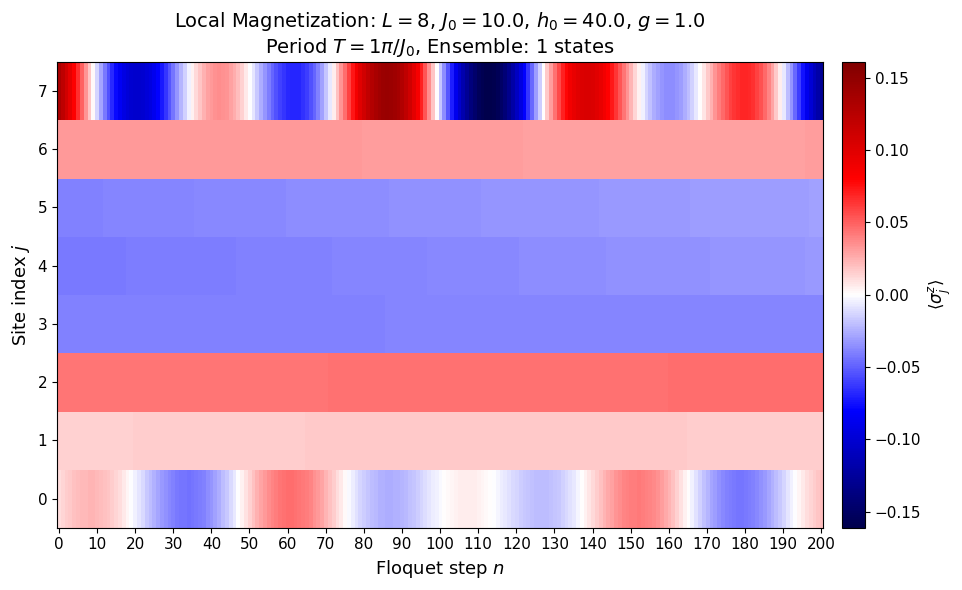


>>> Plotting T = 2π/J₀


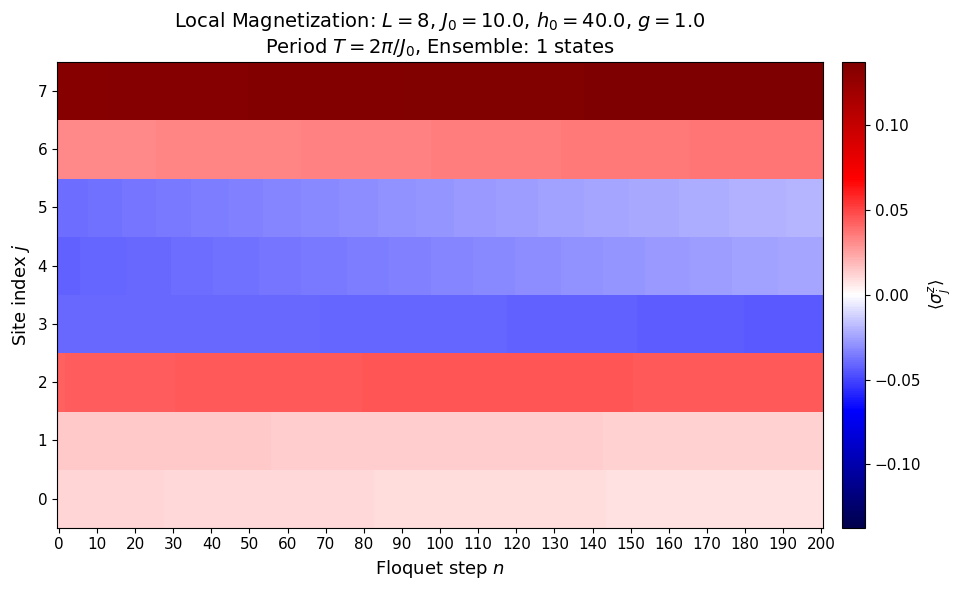


>>> Creating comparison plot


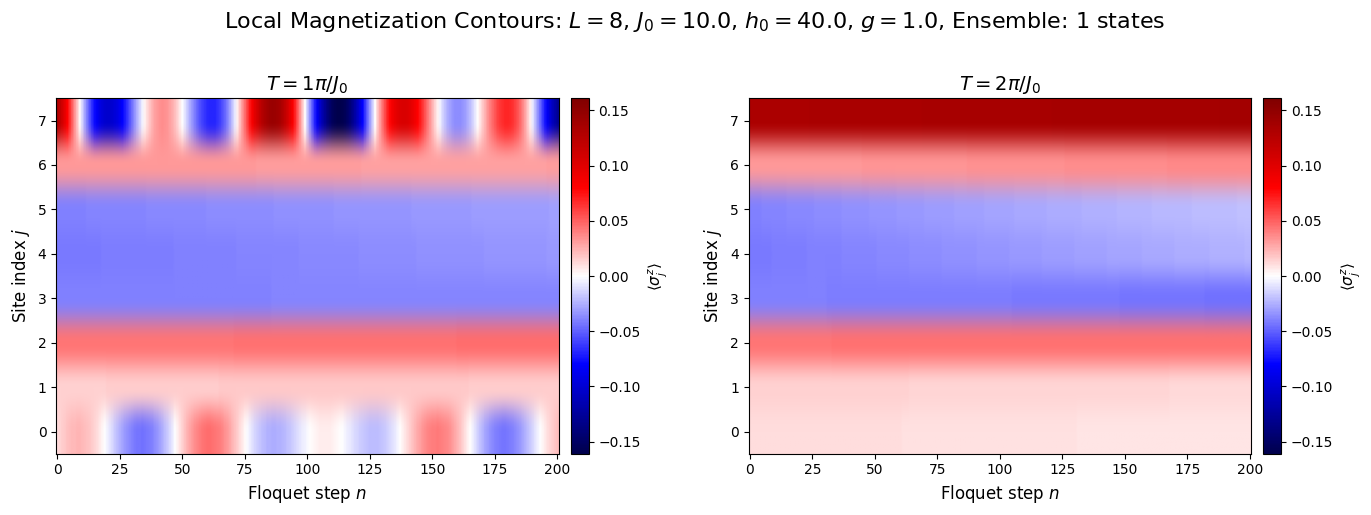


ALL COMPUTATIONS AND PLOTS COMPLETE!


In [59]:
# ============================================
# PART 2: PLOTTING FUNCTIONS
# ============================================
import matplotlib.pyplot as plt

def plot_magnetization_contour(results, params, save_path=None, show_plot=True):
    """
    Create a contour plot of magnetization using imshow.

    Parameters:
    -----------
    results : dict
        Results dictionary from run_magnetization_computation
    params : dict
        Parameters dictionary from run_magnetization_computation
    save_path : str, optional
        Path to save the figure (without extension, saves both .pdf and .png)
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    M_avg = results['M_avg']
    sites = results['sites']
    floquet_steps = results['floquet_steps']

    L = params['L']
    J_0 = params['J_0']
    h_0 = params['h_0']
    g = params['g']
    period_factor = params['period_factor']
    n_steps = params['n_steps']
    num_states = params['num_states']

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 10
    fig_height = 6
    cmap = 'seismic'

    # Colorbar limits (symmetric around 0 for diverging colormap)
    vmax = np.max(np.abs(M_avg))
    vmin = -vmax

    # Font sizes
    title_fontsize = 14
    label_fontsize = 13
    tick_fontsize = 11
    cbar_label_fontsize = 12
    # =======================================================

    # Create figure
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Create the imshow plot
    # Note: imshow expects (rows, cols) = (sites, floquet_steps)
    # origin='lower' puts site 0 at bottom
    im = ax.imshow(
        M_avg,
        aspect='auto',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin='lower',
        extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                sites[0] - 0.5, sites[-1] + 0.5]
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=cbar_label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    # Labels and title
    ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
    ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)

    title = (f'Local Magnetization: $L={L}$, $J_0={J_0}$, $h_0={h_0}$, $g={g}$\n'
             f'Period $T = {period_factor}\\pi/J_0$, Ensemble: {num_states} states')
    ax.set_title(title, fontsize=title_fontsize)

    # Set y-ticks to show all sites
    ax.set_yticks(sites)
    ax.set_yticklabels([f'{j}' for j in sites])

    # Set x-ticks (every 5 or 10 steps depending on range)
    if n_steps <= 50:
        xtick_spacing = 5
    else:
        xtick_spacing = 10
    ax.set_xticks(np.arange(0, n_steps + 1, xtick_spacing))

    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    plt.tight_layout()
    plt.show()

    return fig, ax


def plot_magnetization_comparison(results_list, params_list, save_path=None, show_plot=True):
    """
    Create side-by-side comparison of magnetization contours for different periods.

    Parameters:
    -----------
    results_list : list of dict
        List of results dictionaries (one per period)
    params_list : list of dict
        List of parameter dictionaries (one per period)
    save_path : str, optional
        Path to save the figure
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_plots = len(results_list)

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 7 * n_plots
    fig_height = 5
    cmap = 'seismic'
    title_fontsize = 14
    label_fontsize = 12
    tick_fontsize = 10
    suptitle_fontsize = 16
    # =======================================================

    fig, axes = plt.subplots(1, n_plots, figsize=(fig_width, fig_height))
    if n_plots == 1:
        axes = [axes]

    # Find global color limits for consistency
    all_M = np.concatenate([r['M_avg'].flatten() for r in results_list])
    vmax = np.max(np.abs(all_M))
    vmin = -vmax

    for idx, (results, params, ax) in enumerate(zip(results_list, params_list, axes)):
        M_avg = results['M_avg']
        sites = results['sites']
        floquet_steps = results['floquet_steps']

        period_factor = params['period_factor']
        n_steps = params['n_steps']

        im = ax.imshow(
            M_avg,
            aspect='auto',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin='lower',
            extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                    sites[0] - 0.5, sites[-1] + 0.5]
        )

        ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
        ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)
        ax.set_title(f'$T = {period_factor}\\pi/J_0$', fontsize=title_fontsize)

        ax.set_yticks(sites)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

        # Add colorbar to each subplot
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=label_fontsize - 1)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    # Common parameters for suptitle
    p = params_list[0]
    fig.suptitle(
        f'Local Magnetization Contours: $L={p["L"]}$, $J_0={p["J_0"]}$, '
        f'$h_0={p["h_0"]}$, $g={p["g"]}$, Ensemble: {p["num_states"]} states',
        fontsize=suptitle_fontsize, y=1.02
    )

    plt.tight_layout()
    plt.show()

    return fig, axes



# --- PLOTTING ---
print("\n" + "=" * 80)
print("GENERATING PLOTS")
print("=" * 80)

    # Individual plots
print("\n>>> Plotting T = π/J₀")
fig1, ax1 = plot_magnetization_contour(
        results_n1, params_n1,
        save_path='magnetization_contour_T1pi',
        show_plot=True)

print("\n>>> Plotting T = 2π/J₀")
fig2, ax2 = plot_magnetization_contour(
        results_n2, params_n2,
        save_path='magnetization_contour_T2pi',
        show_plot=True)

    # Side-by-side comparison plot
print("\n>>> Creating comparison plot")
fig_comp, axes_comp = plot_magnetization_comparison(
        [results_n1, results_n2],
        [params_n1, params_n2],
        save_path='magnetization_contour_comparison',
        show_plot=True
    )

print("\n" + "=" * 80)
print("ALL COMPUTATIONS AND PLOTS COMPLETE!")
print("=" * 80)

## Magnetization of a state in the largest fragment




### Results code for a single state evolution of any state




In [73]:
import numpy as np
import time
from scipy.sparse.linalg import expm_multiply

# ============================================
# PART 1: COMPUTATION FUNCTIONS (KRYLOV VERSION)
# ============================================

def create_product_state_from_string(state_string, ising_chain):
    """
    Create a product state from a binary string.

    Parameters
    ----------
    state_string : str
        Binary string of length L where:
        '0' = spin down (σ^z eigenvalue -1, ↓)
        '1' = spin up   (σ^z eigenvalue +1, ↑)

        Examples for L=8:
        "00000000" = all spins down    |↓↓↓↓↓↓↓↓⟩
        "11111111" = all spins up      |↑↑↑↑↑↑↑↑⟩
        "01010101" = Néel state        |↓↑↓↑↓↑↓↑⟩
        "10101010" = Anti-Néel state   |↑↓↑↓↑↓↑↓⟩
        "00001111" = Domain wall       |↓↓↓↓↑↑↑↑⟩

    ising_chain : FloquetIsingChain
        The Floquet Ising chain object.

    Returns
    -------
    psi : ndarray, shape (Ns,), dtype complex128
        Normalized state vector in the computational basis.
    """
    L = ising_chain.L
    basis = ising_chain.basis

    # Validate input
    if len(state_string) != L:
        raise ValueError(f"State string length ({len(state_string)}) must match chain length L={L}")

    if not all(c in '01' for c in state_string):
        raise ValueError("State string must contain only '0' (down) and '1' (up)")

    # Convert binary string to integer representation
    state_int = int(state_string, 2)

    # Full computational basis: states = [0, 1, ..., 2^L - 1]
    # The integer IS the index — no QuSpin .index() needed
    idx = state_int
    assert 0 <= idx < basis.Ns, (
        f"State integer {state_int} out of range [0, {basis.Ns}). "
        f"This should never happen for a valid L={L} binary string."
    )

    # Create state vector
    psi = np.zeros(basis.Ns, dtype=np.complex128)
    psi[idx] = 1.0

    # Print state information
    spin_visual = state_string.replace('0', '↓').replace('1', '↑')
    print(f"\nInitial state created:")
    print(f"  Binary string: {state_string}")
    print(f"  Spin config:   |{spin_visual}⟩")
    print(f"  Basis index:   {idx}")
    print(f"  Norm check:    {np.linalg.norm(psi):.6f}")

    return psi


def build_sigma_z_all_sites(ising_chain):
    """
    Build σ^z diagonal arrays for all sites.

    Returns diagonal arrays (not full matrices) for memory efficiency.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        The Floquet Ising chain object.

    Returns
    -------
    sigma_z_diags : list of ndarray
        List of σ^z diagonal arrays for sites 0, 1, ..., L-1.
        Each array has shape (Ns,).
    """
    L = ising_chain.L
    sigma_z_diags = []

    for site_j in range(L):
        diag = get_sigma_z_diagonal(ising_chain, site_j)
        sigma_z_diags.append(diag)

    print(f"Built σ^z diagonals for all {L} sites")
    print(f"  Memory: {L * ising_chain.Ns * 8 / 1e6:.3f} MB")

    return sigma_z_diags


def compute_magnetization_single_state(psi0, apply_U, sigma_z_diags, n_steps, verbose=True):
    """
    Compute local magnetization M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ for a single initial state.

    Uses Krylov-based time evolution.

    Parameters
    ----------
    psi0 : ndarray, shape (Ns,)
        Initial state vector.
    apply_U : callable
        Floquet propagator: psi -> U_F @ psi.
    sigma_z_diags : list of ndarray
        List of σ^z diagonal arrays for each site.
    n_steps : int
        Number of Floquet steps.
    verbose : bool
        Print progress information.

    Returns
    -------
    M_matrix : ndarray, shape (L, n_steps+1)
        Magnetization matrix where M_matrix[j, n] = M_j(nT).
    """
    L = len(sigma_z_diags)
    M_matrix = np.zeros((L, n_steps + 1), dtype=np.float64)

    # Initial state
    psi_t = psi0.copy()

    if verbose:
        start_time = time.time()
        print(f"\nComputing magnetization over {n_steps} Floquet steps...")
        print(f"  Method: Krylov time evolution")

    for n in range(n_steps + 1):
        # Compute magnetization at each site for current time step
        # M_j(nT) = ⟨ψ(nT)|σ^z_j|ψ(nT)⟩ = Σ_k |ψ_k|² σ^z_j[k]
        psi_abs2 = np.abs(psi_t)**2

        for j in range(L):
            M_matrix[j, n] = np.dot(sigma_z_diags[j], psi_abs2)

        # Evolve state for next step (except at the last step)
        if n < n_steps:
            psi_t = apply_U(psi_t)

        # Progress update
        if verbose and n > 0 and n % 100 == 0:
            elapsed = time.time() - start_time
            rate = n / elapsed
            eta = (n_steps - n) / rate if rate > 0 else 0
            print(f"    Step {n}/{n_steps} ({elapsed:.1f}s, ~{eta:.1f}s remaining)")

    if verbose:
        total_time = time.time() - start_time
        print(f"  Completed in {total_time:.1f}s")

    return M_matrix


def run_magnetization_computation(
    L=8,
    J_0=10.0,
    h_0=20.0,
    g=1.0,
    period_factor=1,
    n_steps=40,
    initial_state_string=None,
    seed=42,
    tol=1e-10
):
    """
    Main computation function for magnetization contour data with specific initial state.

    Uses Krylov-based time evolution (no dense matrices).

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling strength.
    h_0 : float
        Longitudinal field strength.
    g : float
        Transverse field strength.
    period_factor : int
        n in T = n*π/J_0 (1 or 2).
    n_steps : int
        Number of Floquet steps.
    initial_state_string : str
        Binary string of length L specifying the initial product state.
        '0' = spin down (↓), '1' = spin up (↑).
        Example: "01010101" for Néel state |↓↑↓↑↓↑↓↑⟩
    seed : int
        Random seed (unused when initial_state_string is provided).
    tol : float
        Tolerance for Krylov time evolution.

    Returns
    -------
    results : dict
        Dictionary containing:
        - 'M_avg': Magnetization matrix (L, n_steps+1)
        - 'sites': Array of site indices [0, 1, ..., L-1]
        - 'floquet_steps': Array of Floquet step numbers [0, 1, ..., n_steps]
    params : dict
        Dictionary of all parameters used.
    """
    # Compute period
    TP = period_factor * np.pi / J_0

    print("=" * 70)
    print(f"MAGNETIZATION COMPUTATION: T = {period_factor}π/J₀ (KRYLOV)")
    print("=" * 70)
    print(f"Parameters: L={L}, J_0={J_0}, h_0={h_0}, g={g}")
    print(f"Period: T = {period_factor}π/{J_0} = {TP:.6f}")
    print(f"Floquet steps: {n_steps}")
    print(f"Initial state: {initial_state_string}")
    print(f"Method: Krylov time evolution (no dense matrices)")
    print("=" * 70)

    computation_start = time.time()

    # Initialize system
    ising = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=TP, hbar=1.0)
    ising.build_hamiltonians()

    # Create Krylov-based Floquet propagator
    print(f"\nCreating Krylov-based Floquet propagator...")
    apply_U = make_floquet_propagator(ising, tol=tol)

    # Build σ^z diagonals for all sites
    print(f"\nBuilding σ^z operators...")
    sigma_z_diags = build_sigma_z_all_sites(ising)

    # Create initial state from user-defined string
    psi0 = create_product_state_from_string(initial_state_string, ising)

    # Compute magnetization
    M_matrix = compute_magnetization_single_state(
        psi0, apply_U, sigma_z_diags, n_steps, verbose=True
    )

    total_time = time.time() - computation_start

    print(f"\nComputation complete:")
    print(f"  M shape: {M_matrix.shape} (L × n_steps+1)")
    print(f"  M range: [{np.min(M_matrix):.4f}, {np.max(M_matrix):.4f}]")

    # Package results
    results = {
        'M_avg': M_matrix,  # Named M_avg for compatibility with plotting functions
        'sites': np.arange(L),
        'floquet_steps': np.arange(n_steps + 1)
    }

    params = {
        'L': L,
        'J_0': J_0,
        'h_0': h_0,
        'g': g,
        'period_factor': period_factor,
        'TP': TP,
        'n_steps': n_steps,
        'initial_state_string': initial_state_string,
        'seed': seed,
        'method': 'krylov'
    }

    print(f"\n✓ Computation complete in {total_time:.1f}s!")

    return results, params


# ============================================
# PART 2: MAIN EXECUTION
# ============================================

print("=" * 80)
print("SECTION N: MAGNETIZATION FOR PRODUCT STATES")
print("=" * 80)

# ========== TUNABLE PARAMETERS ==========
# Modify these values as needed

L = 12                # Chain length
J_0 = 10.0           # Ising coupling strength
h_0 = 40.0           # Longitudinal field strength (h_0 = 2*J_0)
g = 1.0              # Transverse field strength
n_steps = 500        # Number of Floquet steps

# USER-DEFINED INITIAL STATE
# Binary string of length L where:
#   '0' = spin down (↓)
#   '1' = spin up   (↑)
#
# Examples for L=8:
#   "00000000" = all down      |↓↓↓↓↓↓↓↓⟩
#   "11111111" = all up        |↑↑↑↑↑↑↑↑⟩
#   "01010101" = Néel state    |↓↑↓↑↓↑↓↑⟩
#   "10101010" = Anti-Néel     |↑↓↑↓↑↓↑↓⟩
#   "00001111" = Domain wall   |↓↓↓↓↑↑↑↑⟩
#   "00110011" = Paired        |↓↓↑↑↓↓↑↑⟩

initial_state = "010011010101"  # <-- MODIFY THIS STRING

# =========================================

print(f"\nParameters:")
print(f"  L = {L}")
print(f"  J_0 = {J_0}, h_0 = {h_0}, g = {g}")
print(f"  n_steps = {n_steps}")
print(f"  initial_state = {initial_state}")

# --- COMPUTATION ---
print("\n" + "=" * 80)
print("MAGNETIZATION CONTOUR PLOT COMPUTATION (CUSTOM INITIAL STATE)")
print("=" * 80)

# Compute for T = π/J_0 (period_factor=1)
print("\n>>> Computing for T = π/J₀ (period_factor = 1)")
results_n1, params_n1 = run_magnetization_computation(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=1,
    n_steps=n_steps,
    initial_state_string=initial_state
)

# Compute for T = 2π/J_0 (period_factor=2)
print("\n>>> Computing for T = 2π/J₀ (period_factor = 2)")
results_n2, params_n2 = run_magnetization_computation(
    L=L, J_0=J_0, h_0=h_0, g=g,
    period_factor=2,
    n_steps=n_steps,
    initial_state_string=initial_state
)

# ========== VERIFY OUTPUT FORMAT ==========
print(f"\n{'='*70}")
print("OUTPUT VERIFICATION")
print(f"{'='*70}")

print(f"\nResults for T = π/J₀:")
print(f"  M_avg shape: {results_n1['M_avg'].shape}")
print(f"  Initial state: {params_n1['initial_state_string']}")

print(f"\nResults for T = 2π/J₀:")
print(f"  M_avg shape: {results_n2['M_avg'].shape}")
print(f"  Initial state: {params_n2['initial_state_string']}")

# ========== MEMORY COMPARISON ==========
print(f"\n{'='*70}")
print("MEMORY COMPARISON")
print(f"{'='*70}")

Ns = 2**L
dense_memory = Ns * Ns * 16 / 1e6  # Dense U_floquet
krylov_memory = Ns * 16 / 1e6      # One state vector
sigma_dense = L * Ns * Ns * 8 / 1e6  # Dense σ^z matrices
sigma_diag = L * Ns * 8 / 1e6       # Diagonal σ^z arrays

print(f"\nFor L={L} (Ns={Ns}):")
print(f"  Dense U_floquet: {dense_memory:.1f} MB")
print(f"  Krylov (state only): {krylov_memory:.3f} MB")
print(f"  Dense σ^z (all sites): {sigma_dense:.1f} MB")
print(f"  Diagonal σ^z (all sites): {sigma_diag:.3f} MB")
print(f"  Total savings: {(dense_memory + sigma_dense)/(krylov_memory + sigma_diag):.0f}×")

print(f"\n{'='*70}")
print("✓ SECTION N COMPLETE - Ready for plotting")
print(f"{'='*70}")

SECTION N: MAGNETIZATION FOR PRODUCT STATES

Parameters:
  L = 12
  J_0 = 10.0, h_0 = 40.0, g = 1.0
  n_steps = 500
  initial_state = 010011010101

MAGNETIZATION CONTOUR PLOT COMPUTATION (CUSTOM INITIAL STATE)

>>> Computing for T = π/J₀ (period_factor = 1)
MAGNETIZATION COMPUTATION: T = 1π/J₀ (KRYLOV)
Parameters: L=12, J_0=10.0, h_0=40.0, g=1.0
Period: T = 1π/10.0 = 0.314159
Floquet steps: 500
Initial state: 010011010101
Method: Krylov time evolution (no dense matrices)
System Parameters:
  Chain length L = 12
  J_0 = 10.0
  h_0 = 40.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully!
  H+ shape: (4096, 4096), nnz = 53248, density = 3.17e-03
  H- shape: (4096, 4096), nnz = 53248
  Format: CSR (optimal for matrix-vector products)
  Memory per matrix: ~0.84 MB
  Hermiticity check: max|<v|H|w> - <w|H|v>*| = 2.55e-11

Creating Krylov-based Floquet propagator...

Building σ^z operators...
Built σ^z diagonals for all 12 sites
  Memory: 

### Plotting code for a single evolution of any state


GENERATING PLOTS

>>> Creating comparison plot

✓ Comparison figure saved:
  - magnetization_contour_comparison_state010011010101.pdf
  - magnetization_contour_comparison_state010011010101.png


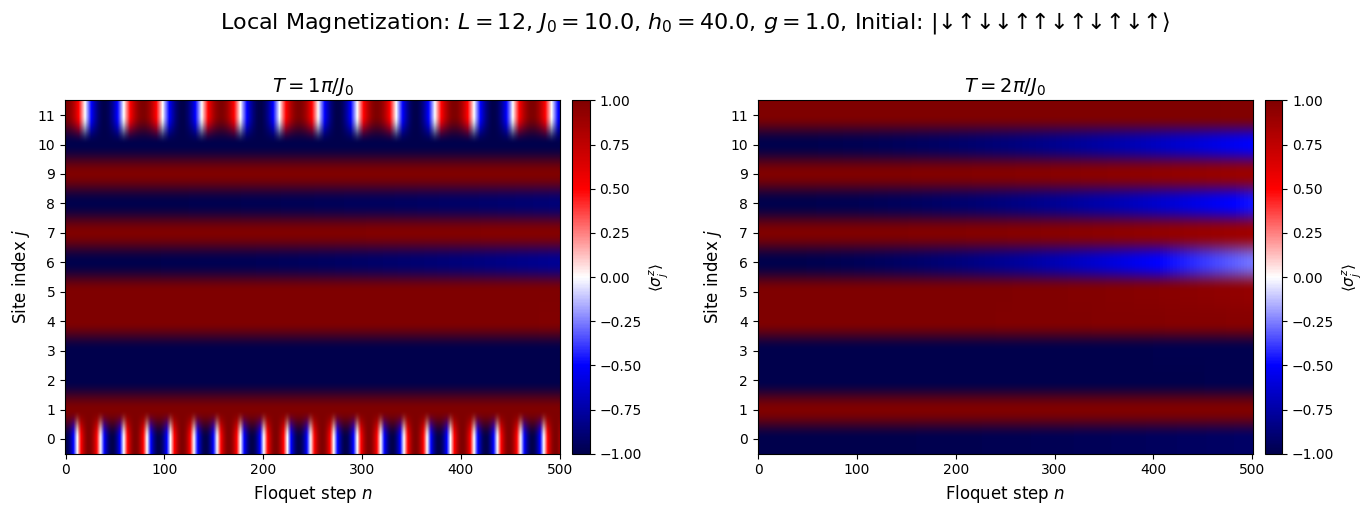


ALL COMPUTATIONS AND PLOTS COMPLETE!


In [74]:
# ============================================
# PART 2: PLOTTING FUNCTIONS
# ============================================


def plot_magnetization_comparison(results_list, params_list, save_path=None, show_plot=True):
    """
    Create side-by-side comparison of magnetization contours for different periods.

    Parameters:
    -----------
    results_list : list of dict
        List of results dictionaries (one per period)
    params_list : list of dict
        List of parameter dictionaries (one per period)
    save_path : str, optional
        Path to save the figure
    show_plot : bool
        Whether to display the plot

    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_plots = len(results_list)

    # ========== EASILY MODIFIABLE PLOT PARAMETERS ==========
    fig_width = 7 * n_plots
    fig_height = 5
    cmap = 'seismic'
    title_fontsize = 14
    label_fontsize = 12
    tick_fontsize = 10
    suptitle_fontsize = 16
    # =======================================================

    fig, axes = plt.subplots(1, n_plots, figsize=(fig_width, fig_height))
    if n_plots == 1:
        axes = [axes]

    # Find global color limits for consistency
    all_M = np.concatenate([r['M_avg'].flatten() for r in results_list])
    vmax = max(np.max(np.abs(all_M)), 0.1)
    vmin = -vmax

    for idx, (results, params, ax) in enumerate(zip(results_list, params_list, axes)):
        M_avg = results['M_avg']
        sites = results['sites']
        floquet_steps = results['floquet_steps']

        period_factor = params['period_factor']
        n_steps = params['n_steps']

        im = ax.imshow(
            M_avg,
            aspect='auto',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin='lower',
            extent=[floquet_steps[0] - 0.5, floquet_steps[-1] + 0.5,
                    sites[0] - 0.5, sites[-1] + 0.5]
        )

        ax.set_xlabel(r'Floquet step $n$', fontsize=label_fontsize)
        ax.set_ylabel(r'Site index $j$', fontsize=label_fontsize)
        ax.set_title(f'$T = {period_factor}\\pi/J_0$', fontsize=title_fontsize)

        ax.set_yticks(sites)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle \sigma^z_j \rangle$', fontsize=label_fontsize - 1)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    # Common parameters for suptitle
    p = params_list[0]
    initial_state = p.get('initial_state_string', 'N/A')
    spin_visual = initial_state.replace('0', '↓').replace('1', '↑')

    fig.suptitle(
        f'Local Magnetization: $L={p["L"]}$, $J_0={p["J_0"]}$, '
        f'$h_0={p["h_0"]}$, $g={p["g"]}$, Initial: $|{spin_visual}\\rangle$',
        fontsize=suptitle_fontsize, y=1.02
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Comparison figure saved:")
        print(f"  - {save_path}.pdf")
        print(f"  - {save_path}.png")

    if show_plot:
        plt.show()

    return fig, axes

# --- PLOTTING ---
print("\n" + "=" * 80)
print("GENERATING PLOTS")
print("=" * 80)

# Create filename suffix from initial state
state_label = initial_state

# Side-by-side comparison plot
print("\n>>> Creating comparison plot")
fig_comp, axes_comp = plot_magnetization_comparison(
[results_n1, results_n2],
[params_n1, params_n2],
save_path=f'magnetization_contour_comparison_state{state_label}',
show_plot=True
)

print("\n" + "=" * 80)
print("ALL COMPUTATIONS AND PLOTS COMPLETE!")
print("=" * 80)